## Hypothesis Tests Part → Third of the Pipeline (**Report + Decision Layer**)

In **Leg 3**, we stop building signals and stop calculating metrics.  
This notebook exists for one purpose:

> **Turn the already-computed results into a clear, human-readable report and decision.**

So Leg 3 is the “presentation + judgment” layer of the project.


### **Main Goal**

Leg 3 reads only the **exported JSON outputs** from **Leg 2 (`eval_metrics.ipynb`)**, then:

- **visualizes** the results (tables + plots)
- **summarizes** what the numbers mean
- **writes a clear decision** for each hypothesis (H1–H5)

This is where we answer, in plain language:

- “Did we find evidence of an edge?”
- “How strong is it, and how reliable is it?”
- “Do we reject the null hypothesis, or not?”


### **Strict Rules of this notebook (no mixing responsibilities)**

To keep the pipeline clean and reproducible, Leg 3 follows strict boundaries:

#### **1) We do NOT rebuild events or predictions**
That is the job of **Leg 1 (Event Factory)**.  
So in Leg 3:
- no new `is_Hx` logic
- no new `pred_Hx_*` logic
- no feature engineering


#### **2) We do NOT recompute metrics**
That is the job of **Leg 2 (Metrics Engine)**.  
So in Leg 3:
- no recalculating hit-rate
- no recalculating p-values
- no re-running evaluation loops

Leg 3 assumes the metrics are already correct and final.


### **What we DO in Leg 3 (the only responsibilities)**

Leg 3 does exactly four actions:

#### **(a) Load saved JSON metric files**
We load the exported outputs such as:

- `H1_metrics.json`
- `H2_metrics.json`
- ...
- `H5_metrics.json`

These JSON files are the “single source of truth” for performance results.


#### **(b) Standardize outputs into plot-ready tables**
Different hypotheses may return slightly different metric keys.  
So we convert JSON dictionaries into clean, consistent structures like:

- one table per hypothesis
- same column naming style
- ready for plotting and comparison


#### **(c) Plot and visualize**
We produce viewer-friendly figures such as:

- hit-rate comparisons (15 vs 30 minutes)
- p-values and confidence intervals
- effect size (returns) distributions
- subgroup comparisons (if present)
- order-group tables (for H5)

The goal is: **make the results readable in 10 seconds.**


#### **(d) Write decisions**
For each hypothesis (H1–H5), we produce a clear decision statement:

- **Reject H0** or **Fail to reject H0**
- plus a short justification using the key metrics:
  - sample size
  - hit-rate
  - p-value
  - effect size
  - robustness checks (if included)

So the output is not just numbers — it is a final conclusion.

---


## The 3-Leg Pipeline (How the whole system is organized)

### **Leg 1 — prediction.ipynb (Event Factory)** 
**Goal:** Create new columns that mark **where** each hypothesis applies and **what the rule predicts** (if applicable).

- We do **NOT** prove anything here.
- We do **NOT** compute p-values or draw conclusions here.
- We only build:
  - **event masks** (which rows are “in the hypothesis world”)
  - **baseline rule predictions** (optional for some hypotheses)

**Output pattern (typical):**
- `is_Hx` → 0/1 mask for “this row is a valid event for Hx”
- `pred_Hx_*` → rule-based prediction (if the hypothesis is directional)
- additional tags (if the hypothesis is grouping / moderator)

Some hypotheses are already fully defined by existing features and labels → they may pass through this leg with minimal work.

### **Leg 2 — eval_metrics.ipynb (Metrics Engine)** 
**Goal:** Given an event definition and predictions, compute all **evaluation metrics** consistently.

Think of this as a reusable “calculator”:

- Input: **(mask, y_true, y_pred)**  
- Output: metrics such as:
  - **hit-rate**
  - **precision / recall / F1** (for rule predictions)
  - **p-value** (example: test `hit-rate > 0.5`)
  - **effect size** (example: signed returns, distance reduction)
  - reusable slice logic (IB width, gap alignment, etc.)

### **Leg 3 — hypothesis_tests.ipynb (Report + Decision Layer)** --> WE ARE IN HERE !!!
**Goal:** Present results in a clean, viewer-friendly form and state decisions clearly.

This is where we:
- show tables/figures
- explain measurement choices (especially for “reversion” type ideas)
- decide:
  - **Reject null hypothesis** or
  - **Fail to reject null hypothesis**
based on the metrics and p-values from Leg 2.

---

### **What Leg 3 expects as inputs**

Leg 3 does **not** read the full dataframe and does **not** recompute any metrics.  
It only reads the **saved JSON metric outputs** created by **Leg 2 (`eval_metrics.ipynb`)**.

So before running Leg 3, we expect the following files to already exist:

- **`H1_metrics.json`**
- **`H2_metrics.json`**
- **`H3_metrics.json`**
- **`H4_metrics.json`**
- **`H5_metrics.json`**

Each JSON file is the “final scorecard” for that hypothesis.


### **What information we expect inside each JSON**

Different hypotheses may produce slightly different metric fields, but we assume each JSON contains as many of the following as applicable:

#### **1) Sample size / coverage (how much data was evaluated)**
Leg 3 needs to know whether the result is based on a strong sample or just a few rows.

Typical fields include:

- **`N`** (number of evaluated rows)
- and/or **`base_rows`** (size of the base universe before filtering)
- and/or **`coverage`** (how often the rule produces a prediction vs abstains)

These values answer:
> “How many valid events did we actually test, and how much did the rule speak?”


#### **2) Classification metrics (directional performance)**
For hypotheses that produce direction predictions (like H2, H4, and sometimes H1/H3), we expect metrics such as:

- **hit-rate / accuracy**
- **precision**
- **recall**
- **F1 score**

These answer:
> “When the hypothesis predicts up/down, how often is it correct, and how balanced are its errors?”


#### **3) Statistical significance outputs (p-values, hypothesis tests)**
Leg 3 needs the “is this better than chance?” evidence.

So we expect values like:

- **p-value** (often from a binomial test style: testing whether hit-rate > 0.5)

These answer:
> “Is the observed performance likely to be real, or could it be random noise?”


#### **4) Return / effect-size summaries (economic meaning)**
Even if something is statistically significant, it may be economically meaningless.

So when available, we expect return-based summaries such as:

- mean / median **signed returns**
- possibly return distributions or summary percentiles

These answer:
> “If the signal is correct, does it deliver meaningful move size (edge), not just a tiny statistical win?”


#### **5) Day-wise uncertainty (bootstrap-by-day confidence intervals)**
Minute bars inside a day are not fully independent, so we prefer uncertainty estimates that work **by day**.

When available, we expect:

- **bootstrap-by-day confidence intervals**  
  (for hit-rate, p_up(order), effect size, etc.)

These answer:
> “Is this effect stable across days, or is it driven by a few lucky days?”

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import json 
import matplotlib

## **H1**

Leg 3 is the place where we stop “building” and start “judging”.  
For H1, that means we take the results already computed in Leg 2 and answer:

> **Does the evidence actually support H1’s claim, in the exact situations H1 describes?**


### **Context: What H1 is claiming (in plain language)**

H1 is **not** a vague statement like “markets revert sometimes.”

H1 is a specific, testable claim:

> When price is **between two AVWAPs**, those AVWAPs are **very close**,  
> and their slopes **disagree** (one drifting up, the other drifting down),  
> then the next **15–30 minutes** are **more likely than random (>50%)**  
> to drift in the direction H1 predicts.

So in Leg 3 we do **not** try to recreate the setup.  
We only check:

- **What was measured in Leg 2**
- **Whether it supports the claim**
- **Where (which regime, which horizon) the effect appears**

And the first step is always: **visualize**.


### **(a) Input (What does Leg 3 need to start H1?)**

Leg 3 does **not** read the full CSV and does **not** recompute the H1 event logic.

For H1, Leg 3 expects exactly one file to already exist:

- **`H1_metrics.json`**

This file is produced by **Leg 2 (`eval_metrics.ipynb`)** after evaluating:

- the H1 event universe (**mask**)
- `y_true = dir15 / dir30`
- `y_pred = pred_H1_dir15 / pred_H1_dir30`
- plus all derived metrics (hit-rate, p-values, returns, etc.)

In Leg 3, we treat this JSON as H1’s frozen scoreboard:

> **“Given the exact H1 definition and evaluation method, what did we measure?”**


### **(b) Structure of H1 results (How we organize what we read)**

Because H1 is a **regime-dependent** idea (“close + disagreeing AVWAPs”), we do not want one single number.

We want to see whether the effect changes by:

#### **1) Horizon (H1 claims 15–30 minutes)**
- **15 minutes**
- **30 minutes**

#### **2) Regime segment (market can behave differently)**
- **overall**
- **narrow** (tight first-hour range regime)
- **wide** (expanded first-hour range regime)

So in Leg 3, the core reading structure is always:

> **overall vs narrow vs wide**, separately for **15** and **30** minutes.


### **(c) What we visualize first (H1 plots + why they matter)**

In Leg 3, we do not “read a JSON and instantly conclude.”  
We do this sequence:

> **Table → plot → interpretation → decision**

Below are the main plots and what each one answers.


#### **1) Drift vs coin flip (the core H1 claim)**
For each **segment × horizon**, plot:

- **hit-rate (accuracy)**  
with a reference line at **0.50**

This answers:
> “In the exact H1 setup, does the prediction beat randomness?”

If hit-rate is not above 0.50, H1’s “more likely than not” claim is not supported.


#### **2) Drift vs naive baseline (is this real, or just class imbalance?)**
Sometimes the data slice itself has more “up” than “down”.

So we plot side-by-side:

- **hit-rate**
- **majority_baseline_acc** (always predict the majority class)

This answers:
> “Is H1 better than the dumb baseline, or does it only look good because the slice is biased?”

A real edge should ideally beat **both**:
- 0.50
- majority baseline


#### **3) Error shape (what kind of ‘wrong’ is H1?)**
A hypothesis can have the same accuracy but very different failure patterns.

So we visualize:

- **precision**
- **recall**
- **F1**

by **segment × horizon**

This answers:
> “Is H1 balanced, or does it behave like a one-sided caller (good at one class, bad at the other)?”


#### **4) Economic meaning (is the ‘drift’ tradable, or tiny?)**
H1 is about movement, not just being “right” by 0.1%.

So we visualize:

- **mean_signed_return**
- **median_signed_return**

by **segment × horizon**

This answers:
> “Even if accuracy improves, do returns show meaningful edge?”

If returns are near zero (or inconsistent), the signal may not be useful even if hit-rate is slightly above chance.


#### **5) Day-wise stability (is it consistent across days?)**
Intraday minutes inside the same day are dependent, so we prefer day-aware uncertainty.

If the JSON provides bootstrap-by-day results, we visualize confidence intervals for:

- hit-rate
- F1
- mean_signed_return

using (2.5 / 50 / 97.5) percentiles.

This answers:
> “Is H1 stable across many days, or driven by a few lucky days?”

**Practical stability rule-of-thumb in Leg 3:**
- If the hit-rate CI lower bound is **≤ 0.50**, chance-beating is not stable.
- If the return CI crosses **0**, economic edge is not stable.


### **(d) Only after plots: the H1 decision checklist (how we conclude)**

Once we’ve seen the visuals, we summarize in H1 language:

1. **Does any slice beat 0.50?** (15 and/or 30)
2. **Does it also beat the majority baseline?**
3. **Where is the effect strongest?**
   - concentrated in **narrow**? → “tight-regime phenomenon”
   - concentrated in **wide**? → “needs expansion regime”
4. **Do returns agree with direction success?**
   - hit-rate up but returns flat → suspicious / not tradable
5. **Do bootstrap intervals support day-stability?**
   - CI crosses 0.50 or 0 return → not stable enough


### **Important H1 diagnostic (flagging a common failure mode)**

Leg 3 will explicitly watch for this pattern:

- If hit-rate is **consistently below 0.50** across slices,  
  it often means the direction mapping is inverted (prediction sign mismatch).

Example:
- the rule says “predict up”, but your `dir15/dir30` encoding might interpret direction the opposite way, or the “toward mid” mapping may be flipped.

Leg 3 will **not fix** this (fixing belongs to Leg 1/2),  
but it will **flag it clearly** once the plots confirm it.



In [12]:
# Inputting our .json file into the system

PROJECT_ROOT = Path("..").resolve()
JSONFILE = PROJECT_ROOT / "reports"

METRICS_FILE = JSONFILE / "H1_metrics.json"

# Load JSON into a Python dict
with open(METRICS_FILE, "r", encoding="utf-8") as f:
    h1 = json.load(f)

# Quick sanity peek
print("Loaded keys:", list(h1.keys()))
print("Example block (overall_15):", h1.get("overall_15", None))

Loaded keys: ['overall_15', 'overall_30', 'narrow_15', 'narrow_30', 'wide_15', 'wide_30', 'bootstrap_overall_15', 'bootstrap_overall_30']
Example block (overall_15): {'N': 326, 'k_correct': 135, 'hit_rate': 0.41411042944785276, 'tp': 68, 'fp': 111, 'fn': 80, 'tn': 67, 'precision': 0.37988826815642457, 'recall': 0.4594594594594595, 'f1': 0.41590214067278286, 'pval_greater(>p0)': 0.9992225940463264, 'pval_less(<p0)': 0.0011340343275836327, 'pval_two_sided': 0.0022680686551672653, 'mean_signed_return': -0.0002096181345698247, 'median_signed_return': -0.00010388184773285, 'y_true_up_rate': 0.4539877300613497, 'majority_baseline_acc': 0.5460122699386503}


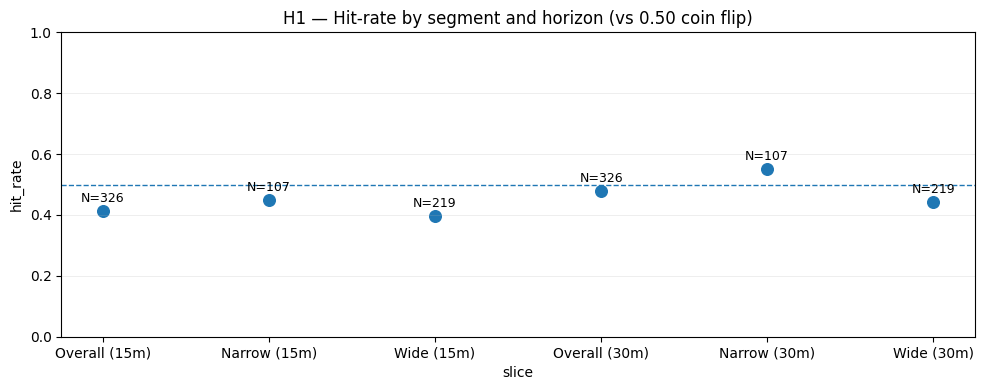

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #1
# Drift vs coin flip (0.50 line) — disconnected dot plot
# ==========================
# Assumes: h1 is already loaded (dict)

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

# Build a small plot-ready table
rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    rows.append({
        "slice": k,
        "hit_rate": float(h1[k].get("hit_rate", float("nan"))),
        "N": int(h1[k].get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# Nice ordering + labels
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

# explicit order so sort is deterministic
seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# Plot (single figure) — disconnected points
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
y = df_plot["hit_rate"].values

ax.scatter(x, y, s=70)  # disconnected dot plot
ax.axhline(0.50, linewidth=1, linestyle="--")  # coin flip reference

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Hit-rate by segment and horizon (vs 0.50 coin flip)")
ax.set_ylabel("hit_rate")
ax.set_xlabel("slice")

# annotate N above points (clamped so it won't go off the chart top)
for i, (hr, n) in enumerate(zip(df_plot["hit_rate"], df_plot["N"])):
    y_text = min(hr + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

# optional: light grid for readability
ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

fig.tight_layout()
plt.show()


In [14]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown


# 1) Pull the exact values used in Plot #1
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "k_correct": int(b["k_correct"]),
        "hit_rate": float(b["hit_rate"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"])
df["delta_vs_50"] = df["hit_rate"] - 0.50

best = df.sort_values("hit_rate", ascending=False).iloc[0]
worst = df.sort_values("hit_rate", ascending=True).iloc[0]

count_above = int((df["hit_rate"] > 0.50).sum())
count_below = int((df["hit_rate"] < 0.50).sum())

def pct(x): 
    return f"{100*x:.1f}%"

def fmt_delta(d):
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

md = f"""
## H1 — Plot #1 (Hit-rate vs 0.50 coin flip)

### What this plot is checking
H1 claims the direction should be **more likely than not** in the H1 setup.  
So this plot asks a single question per slice:

> **Is hit-rate above 0.50, or is it at/below coin flip?**

### What we see in the dots
- **{count_above}/6** slices are **above 0.50**, and **{count_below}/6** are **below 0.50**.
- Best dot: **{best['slice']}** → hit-rate **{best['hit_rate']:.3f} ({pct(best['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(best['delta_vs_50'])}**, N={int(best['N'])}.
- Worst dot: **{worst['slice']}** → hit-rate **{worst['hit_rate']:.3f} ({pct(worst['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(worst['delta_vs_50'])}**, N={int(worst['N'])}.

### What this means for H1 (based on Plot #1 only)
Because most dots sit **below** the 0.50 line, this plot alone does **not** show the “more-than-50%” behavior consistently across slices.  
This plot is descriptive only; statistical certainty and economic meaning are handled in the later plots.
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","k_correct","hit_rate","delta_vs_50"]])


## H1 — Plot #1 (Hit-rate vs 0.50 coin flip)

### What this plot is checking
H1 claims the direction should be **more likely than not** in the H1 setup.  
So this plot asks a single question per slice:

> **Is hit-rate above 0.50, or is it at/below coin flip?**

### What we see in the dots
- **1/6** slices are **above 0.50**, and **5/6** are **below 0.50**.
- Best dot: **Narrow (30m)** → hit-rate **0.551 (55.1%)**, Δ vs 0.50 = **+0.051 (+5.1pp)**, N=107.
- Worst dot: **Wide (15m)** → hit-rate **0.397 (39.7%)**, Δ vs 0.50 = **-0.103 (-10.3pp)**, N=219.

### What this means for H1 (based on Plot #1 only)
Because most dots sit **below** the 0.50 line, this plot alone does **not** show the “more-than-50%” behavior consistently across slices.  
This plot is descriptive only; statistical certainty and economic meaning are handled in the later plots.

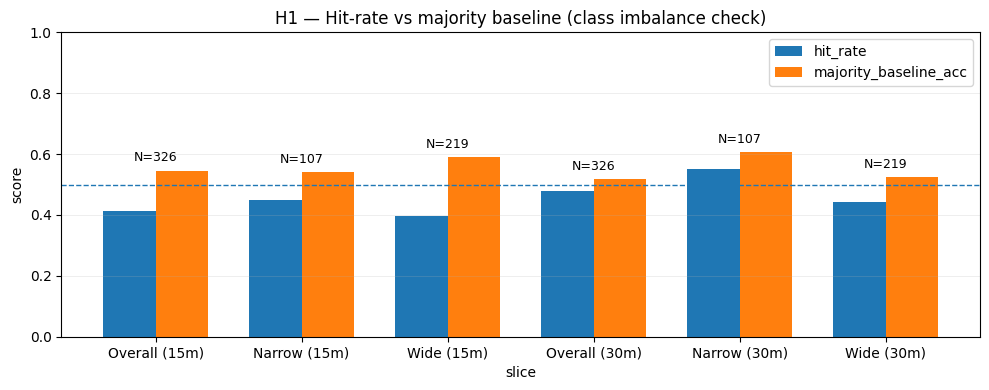

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #2
# Drift vs naive baseline (class imbalance check)
# hit_rate vs majority_baseline_acc (side-by-side)
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "hit_rate": float(block.get("hit_rate", float("nan"))),
        "majority_baseline_acc": float(block.get("majority_baseline_acc", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.36  # bar width

ax.bar([i - w/2 for i in x], df_plot["hit_rate"].values, width=w, label="hit_rate")
ax.bar([i + w/2 for i in x], df_plot["majority_baseline_acc"].values, width=w, label="majority_baseline_acc")

# optional coin flip reference
ax.axhline(0.50, linewidth=1, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Hit-rate vs majority baseline (class imbalance check)")
ax.set_ylabel("score")
ax.set_xlabel("slice")
ax.legend()

# annotate N above the taller bar in each pair
for i, (hr, mb, n) in enumerate(zip(df_plot["hit_rate"], df_plot["majority_baseline_acc"], df_plot["N"])):
    y_top = max(hr, mb)
    y_text = min(y_top + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


In [16]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H1 — Plot #2 interpretation text (EN, beginner-friendly)
# ONLY: hit_rate vs majority_baseline_acc across 6 slices
# Uses only: N, hit_rate, majority_baseline_acc (and 0.50 reference line)
# ==========================

# 1) Pull exact values used in Plot #2
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "hit_rate": float(b["hit_rate"]),
        "majority_baseline_acc": float(b["majority_baseline_acc"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

# 2) Comparisons
df["gap_vs_majority"] = df["hit_rate"] - df["majority_baseline_acc"]
wins = int((df["gap_vs_majority"] > 0).sum())
losses = int((df["gap_vs_majority"] < 0).sum())
ties = int((df["gap_vs_majority"] == 0).sum())

best_gap = df.sort_values("gap_vs_majority", ascending=False).iloc[0]
worst_gap = df.sort_values("gap_vs_majority", ascending=True).iloc[0]

# 3) Build a tight, plot-only interpretation (with a clear baseline definition)
def pct(x): 
    return f"{100*x:.1f}%"

def fmt_pp(x):
    sign = "+" if x >= 0 else ""
    return f"{sign}{100*x:.1f}pp"

md = f"""
## H1 — Plot #2 (Hit-rate vs Majority Baseline)

### Why this plot exists
H1 claims it predicts direction better than randomness **in the H1 setup**.  
But even if a rule has *some* accuracy, it may still be useless if the data slice itself is biased.

So this plot asks a sharper question than “is hit-rate above 0.50?”:

> **Does H1 beat a very simple baseline that ignores H1 entirely?**

### What “majority baseline” means
For each slice (e.g., *Overall (15m)*), we look at the true labels in that slice:
- If the slice contains **more UP than DOWN**, the majority class is **UP**.
- A “majority baseline” strategy is: **always predict the majority class** (always UP in that example).

That baseline accuracy is what you would get by being “lazy but consistent”:
- You do **not** use AVWAPs,
- You do **not** use the H1 rule,
- You just guess the most common outcome in that slice.

So in this chart:
- **Blue bar** = H1 hit-rate (how often H1 was correct)
- **Orange bar** = majority-baseline accuracy (how often the “always majority” guess would be correct)

### What we are comparing (the core of this chart)
> **Blue vs Orange**: does H1 add value beyond class imbalance?

- If **blue > orange** → H1 adds information beyond “just guess the dominant direction”.
- If **blue < orange** → H1 is worse than a naive guess for that slice.

### What we see
- Across the 6 slices, H1 beats the majority baseline in **{wins}/6** slices (ties: {ties}, loses: {losses}).

Best relative case:
- **{best_gap['slice']}** → hit-rate **{best_gap['hit_rate']:.3f} ({pct(best_gap['hit_rate'])})** vs baseline **{best_gap['majority_baseline_acc']:.3f} ({pct(best_gap['majority_baseline_acc'])})**  
- Gap (blue − orange) = **{fmt_pp(best_gap['gap_vs_majority'])}**, N={int(best_gap['N'])}

Worst relative case:
- **{worst_gap['slice']}** → hit-rate **{worst_gap['hit_rate']:.3f} ({pct(worst_gap['hit_rate'])})** vs baseline **{worst_gap['majority_baseline_acc']:.3f} ({pct(worst_gap['majority_baseline_acc'])})**  
- Gap (blue − orange) = **{fmt_pp(worst_gap['gap_vs_majority'])}**, N={int(worst_gap['N'])}

### What this means for H1 (based on Plot #2 only)
In most slices, the orange bar is above the blue bar. That means:
- The slice is directionally imbalanced, and
- A naive “always guess the majority direction” approach would outperform H1 in that slice.

So, **as shown by this chart**, H1 generally does **not** outperform the simplest imbalance-aware baseline.
""".strip()

display(Markdown(md))


## H1 — Plot #2 (Hit-rate vs Majority Baseline)

### Why this plot exists
H1 claims it predicts direction better than randomness **in the H1 setup**.  
But even if a rule has *some* accuracy, it may still be useless if the data slice itself is biased.

So this plot asks a sharper question than “is hit-rate above 0.50?”:

> **Does H1 beat a very simple baseline that ignores H1 entirely?**

### What “majority baseline” means
For each slice (e.g., *Overall (15m)*), we look at the true labels in that slice:
- If the slice contains **more UP than DOWN**, the majority class is **UP**.
- A “majority baseline” strategy is: **always predict the majority class** (always UP in that example).

That baseline accuracy is what you would get by being “lazy but consistent”:
- You do **not** use AVWAPs,
- You do **not** use the H1 rule,
- You just guess the most common outcome in that slice.

So in this chart:
- **Blue bar** = H1 hit-rate (how often H1 was correct)
- **Orange bar** = majority-baseline accuracy (how often the “always majority” guess would be correct)

### What we are comparing (the core of this chart)
> **Blue vs Orange**: does H1 add value beyond class imbalance?

- If **blue > orange** → H1 adds information beyond “just guess the dominant direction”.
- If **blue < orange** → H1 is worse than a naive guess for that slice.

### What we see
- Across the 6 slices, H1 beats the majority baseline in **0/6** slices (ties: 0, loses: 6).

Best relative case:
- **Overall (30m)** → hit-rate **0.479 (47.9%)** vs baseline **0.518 (51.8%)**  
- Gap (blue − orange) = **-4.0pp**, N=326

Worst relative case:
- **Wide (15m)** → hit-rate **0.397 (39.7%)** vs baseline **0.589 (58.9%)**  
- Gap (blue − orange) = **-19.2pp**, N=219

### What this means for H1 (based on Plot #2 only)
In most slices, the orange bar is above the blue bar. That means:
- The slice is directionally imbalanced, and
- A naive “always guess the majority direction” approach would outperform H1 in that slice.

So, **as shown by this chart**, H1 generally does **not** outperform the simplest imbalance-aware baseline.

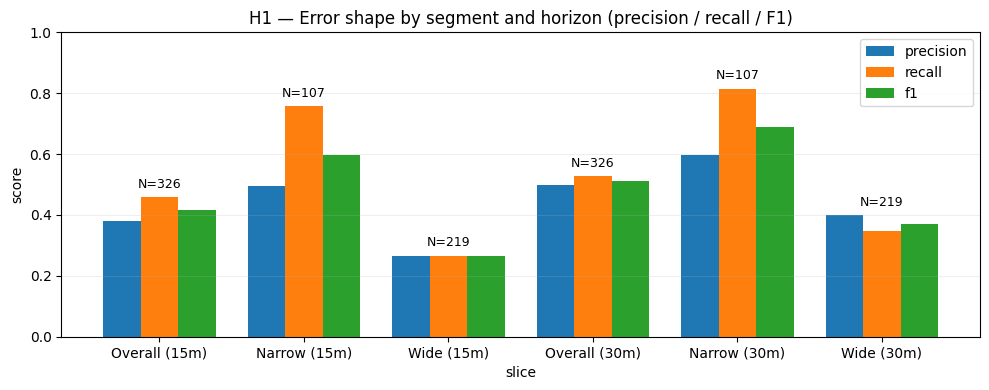

In [17]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #3
# Error shape: precision / recall / F1 (3 series)
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "precision": float(block.get("precision", float("nan"))),
        "recall": float(block.get("recall", float("nan"))),
        "f1": float(block.get("f1", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.26

ax.bar([i - w for i in x], df_plot["precision"].values, width=w, label="precision")
ax.bar(x,                  df_plot["recall"].values,    width=w, label="recall")
ax.bar([i + w for i in x], df_plot["f1"].values,        width=w, label="f1")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_ylim(0, 1)
ax.set_title("H1 — Error shape by segment and horizon (precision / recall / F1)")
ax.set_ylabel("score")
ax.set_xlabel("slice")
ax.legend()

# annotate N above the tallest of the 3 bars per slice
for i, (p, r, f, n) in enumerate(zip(df_plot["precision"], df_plot["recall"], df_plot["f1"], df_plot["N"])):
    y_top = max(p, r, f)
    y_text = min(y_top + 0.02, 0.98)
    ax.text(i, y_text, f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


In [18]:

import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H1 — Plot #3 interpretation text (EN, beginner-friendly)
# ONLY: precision / recall / F1 across 6 slices
# Uses only: N, precision, recall, f1
# ==========================

# 1) Pull the exact values used in Plot #3
slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]
label_map = {
    "overall_15": "Overall (15m)",
    "narrow_15":  "Narrow (15m)",
    "wide_15":    "Wide (15m)",
    "overall_30": "Overall (30m)",
    "narrow_30":  "Narrow (30m)",
    "wide_30":    "Wide (30m)",
}

rows = []
for k in slices:
    b = h1[k]
    rows.append({
        "slice": label_map[k],
        "N": int(b["N"]),
        "precision": float(b["precision"]),
        "recall": float(b["recall"]),
        "f1": float(b["f1"]),
        "segment": k.split("_")[0],
        "horizon": int(k.split("_")[1]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

# 2) Simple “shape” summaries (still plot-only)
def pct(x): 
    return f"{100*x:.1f}%"

# Identify the most "imbalanced" slice: big gap between precision and recall
df["pr_gap"] = (df["precision"] - df["recall"]).abs()
most_imbal = df.sort_values("pr_gap", ascending=False).iloc[0]

# Best and worst F1 (overall balance)
best_f1 = df.sort_values("f1", ascending=False).iloc[0]
worst_f1 = df.sort_values("f1", ascending=True).iloc[0]

# 3) Build a tight, plot-only interpretation
md = f"""
## H1 — Plot #3 (Precision / Recall / F1)

### Why this plot exists
Hit-rate alone does not tell us *how* H1 is wrong.
This plot describes the **error shape** of H1’s predictions (usually treating **UP = 1** as the “positive” class).

### What the three metrics mean (beginner-friendly)
Think of “UP” as the event we care about detecting.

- **Precision**: *When H1 says “UP”, how often is it actually UP?*  
  (High precision = fewer false “UP” calls.)

- **Recall**: *Out of all true UP cases, how many did H1 successfully call “UP”?*  
  (High recall = H1 catches more of the real UP moves.)

- **F1**: A single balance score that combines precision + recall.  
  (High F1 usually means “not only calling UP often, but calling it correctly”.)

### What we see in this chart
- Best balanced slice (highest F1):
  - **{best_f1['slice']}** → F1 **{best_f1['f1']:.3f} ({pct(best_f1['f1'])})**, precision **{best_f1['precision']:.3f} ({pct(best_f1['precision'])})**, recall **{best_f1['recall']:.3f} ({pct(best_f1['recall'])})**, N={int(best_f1['N'])}
- Weakest balanced slice (lowest F1):
  - **{worst_f1['slice']}** → F1 **{worst_f1['f1']:.3f} ({pct(worst_f1['f1'])})**, precision **{worst_f1['precision']:.3f} ({pct(worst_f1['precision'])})**, recall **{worst_f1['recall']:.3f} ({pct(worst_f1['recall'])})**, N={int(worst_f1['N'])}

### The key “shape” diagnostic (precision vs recall)
The slice with the biggest precision–recall mismatch is:
- **{most_imbal['slice']}** → precision **{most_imbal['precision']:.3f}**, recall **{most_imbal['recall']:.3f}** (gap ≈ {pct(most_imbal['pr_gap'])}), N={int(most_imbal['N'])}

How to read that mismatch (only for this plot):
- If **recall ≫ precision**: H1 calls “UP” a lot and catches many true UPs, but also produces many false UPs.
- If **precision ≫ recall**: H1 is picky—when it says “UP” it’s often right, but it misses many true UPs.

### What this means for H1 (based on Plot #3 only)
This plot does **not** decide whether H1 is profitable or statistically strong.
It only tells us **what kind of mistakes** H1 makes in each slice (more “false UP” vs more “missed UP”),
and which slice looks most/least balanced by F1.
""".strip()

display(Markdown(md))


## H1 — Plot #3 (Precision / Recall / F1)

### Why this plot exists
Hit-rate alone does not tell us *how* H1 is wrong.
This plot describes the **error shape** of H1’s predictions (usually treating **UP = 1** as the “positive” class).

### What the three metrics mean (beginner-friendly)
Think of “UP” as the event we care about detecting.

- **Precision**: *When H1 says “UP”, how often is it actually UP?*  
  (High precision = fewer false “UP” calls.)

- **Recall**: *Out of all true UP cases, how many did H1 successfully call “UP”?*  
  (High recall = H1 catches more of the real UP moves.)

- **F1**: A single balance score that combines precision + recall.  
  (High F1 usually means “not only calling UP often, but calling it correctly”.)

### What we see in this chart
- Best balanced slice (highest F1):
  - **Narrow (30m)** → F1 **0.688 (68.8%)**, precision **0.596 (59.6%)**, recall **0.815 (81.5%)**, N=107
- Weakest balanced slice (lowest F1):
  - **Wide (15m)** → F1 **0.267 (26.7%)**, precision **0.267 (26.7%)**, recall **0.267 (26.7%)**, N=219

### The key “shape” diagnostic (precision vs recall)
The slice with the biggest precision–recall mismatch is:
- **Narrow (15m)** → precision **0.494**, recall **0.759** (gap ≈ 26.4%), N=107

How to read that mismatch (only for this plot):
- If **recall ≫ precision**: H1 calls “UP” a lot and catches many true UPs, but also produces many false UPs.
- If **precision ≫ recall**: H1 is picky—when it says “UP” it’s often right, but it misses many true UPs.

### What this means for H1 (based on Plot #3 only)
This plot does **not** decide whether H1 is profitable or statistically strong.
It only tells us **what kind of mistakes** H1 makes in each slice (more “false UP” vs more “missed UP”),
and which slice looks most/least balanced by F1.

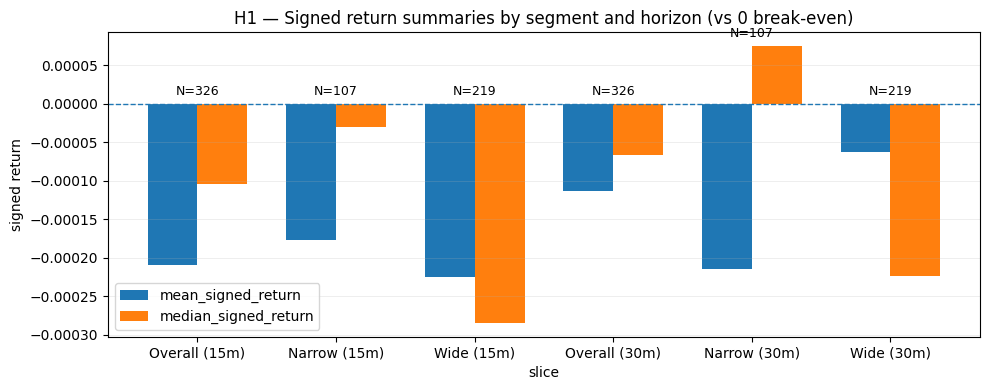

In [19]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #4
# Economic meaning: mean/median signed return (2 series) vs 0 break-even line
# ==========================

slices = ["overall_15", "narrow_15", "wide_15", "overall_30", "narrow_30", "wide_30"]

rows = []
for k in slices:
    if k not in h1:
        raise KeyError(f"Missing key in h1 JSON: {k}")
    block = h1[k]
    rows.append({
        "slice": k,
        "mean_signed_return": float(block.get("mean_signed_return", float("nan"))),
        "median_signed_return": float(block.get("median_signed_return", float("nan"))),
        "N": int(block.get("N", 0)),
    })

df_plot = pd.DataFrame(rows)

# labels + deterministic ordering
df_plot["segment"] = df_plot["slice"].str.split("_").str[0]
df_plot["horizon"] = df_plot["slice"].str.split("_").str[1].astype(int)
df_plot["label"] = df_plot["segment"].str.capitalize() + " (" + df_plot["horizon"].astype(str) + "m)"

seg_order = {"overall": 0, "narrow": 1, "wide": 2}
df_plot["seg_rank"] = df_plot["segment"].map(seg_order).fillna(99).astype(int)
df_plot = df_plot.sort_values(["horizon", "seg_rank"]).reset_index(drop=True)

# --- plot (single figure) ---
fig, ax = plt.subplots(figsize=(10, 4))

x = list(range(len(df_plot)))
w = 0.36

ax.bar([i - w/2 for i in x], df_plot["mean_signed_return"].values, width=w, label="mean_signed_return")
ax.bar([i + w/2 for i in x], df_plot["median_signed_return"].values, width=w, label="median_signed_return")

# break-even reference
ax.axhline(0.0, linewidth=1, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["label"].values)
ax.set_title("H1 — Signed return summaries by segment and horizon (vs 0 break-even)")
ax.set_ylabel("signed return")
ax.set_xlabel("slice")
ax.legend()

# annotate N slightly above the taller bar (or above 0 if both negative)
for i, (m, md, n) in enumerate(zip(df_plot["mean_signed_return"], df_plot["median_signed_return"], df_plot["N"])):
    y_top = max(m, md, 0.0)  # keep text readable when both bars are negative
    ax.text(i, y_top + (0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]) if ax.get_ylim()[1] != ax.get_ylim()[0] else 0.01),
            f"N={n}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()


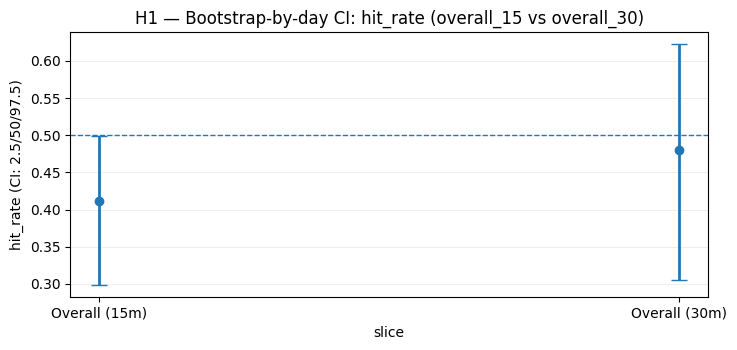

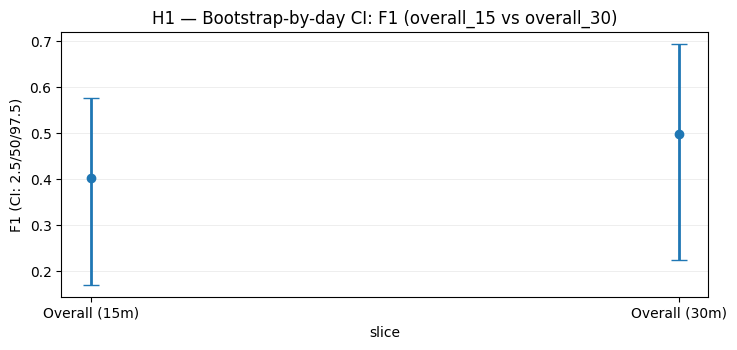

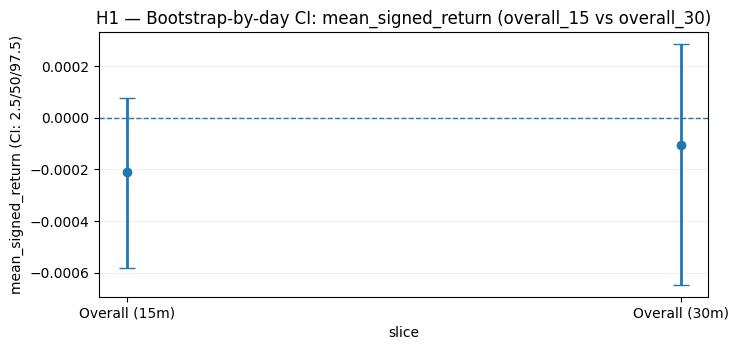

In [20]:
import matplotlib.pyplot as plt

# ==========================
# H1 — Plot #5/#6/#7 (Bootstrap-by-day CIs)
# hit_ci, f1_ci, mean_signed_return_ci
# overall_15 vs overall_30
# ==========================

b15 = h1.get("bootstrap_overall_15", None)
b30 = h1.get("bootstrap_overall_30", None)
if b15 is None or b30 is None:
    raise KeyError("Missing bootstrap blocks in h1: need 'bootstrap_overall_15' and 'bootstrap_overall_30'")

def _as_ci(block, key):
    arr = block.get(key, None)
    if not (isinstance(arr, list) and len(arr) == 3):
        raise KeyError(f"Bootstrap CI '{key}' missing or not a 3-list in block.")
    lo, mid, hi = map(float, arr)
    return lo, mid, hi

# Extract CIs
hit15 = _as_ci(b15, "hit_ci(2.5,50,97.5)")
hit30 = _as_ci(b30, "hit_ci(2.5,50,97.5)")

f115  = _as_ci(b15, "f1_ci(2.5,50,97.5)")
f130  = _as_ci(b30, "f1_ci(2.5,50,97.5)")

msr15 = _as_ci(b15, "mean_signed_return_ci(2.5,50,97.5)")
msr30 = _as_ci(b30, "mean_signed_return_ci(2.5,50,97.5)")

# Common x positions/labels
x = [0, 1]
labels = ["Overall (15m)", "Overall (30m)"]

def _plot_ci(ci15, ci30, title, ylabel, ref_y=None):
    fig, ax = plt.subplots(figsize=(7.5, 3.6))

    mids = [ci15[1], ci30[1]]
    yerr = [
        [mids[0] - ci15[0], mids[1] - ci30[0]],  # lower errors
        [ci15[2] - mids[0], ci30[2] - mids[1]],  # upper errors
    ]

    ax.errorbar(x, mids, yerr=yerr, fmt="o", capsize=6, linewidth=2)

    if ref_y is not None:
        ax.axhline(ref_y, linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("slice")
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)
    fig.tight_layout()
    plt.show()

# ---- Plot #5: hit-rate CI (vs 0.50) ----
_plot_ci(
    hit15, hit30,
    title="H1 — Bootstrap-by-day CI: hit_rate (overall_15 vs overall_30)",
    ylabel="hit_rate (CI: 2.5/50/97.5)",
    ref_y=0.50
)

# ---- Plot #6: F1 CI ----
_plot_ci(
    f115, f130,
    title="H1 — Bootstrap-by-day CI: F1 (overall_15 vs overall_30)",
    ylabel="F1 (CI: 2.5/50/97.5)",
    ref_y=None
)

# ---- Plot #7: mean signed return CI (vs 0) ----
_plot_ci(
    msr15, msr30,
    title="H1 — Bootstrap-by-day CI: mean_signed_return (overall_15 vs overall_30)",
    ylabel="mean_signed_return (CI: 2.5/50/97.5)",
    ref_y=0.0
)

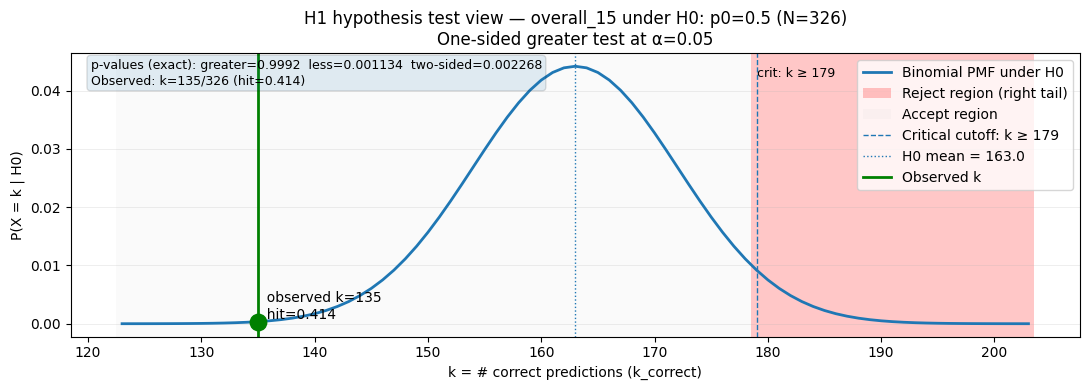

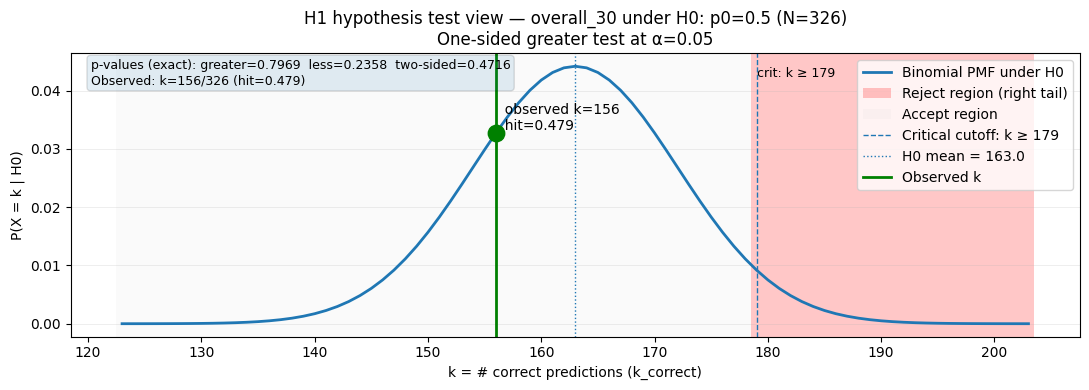

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# H1 — Reader-friendly hypothesis test view (Binomial under H0)
# ==========================


def _log_choose(n, k):
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

def _binom_pmf(n, p0):
    ks = np.arange(n + 1)
    logpmf = np.array(
        [_log_choose(n, int(k)) + k * math.log(p0) + (n - k) * math.log(1 - p0) for k in ks],
        dtype=float
    )
    m = logpmf.max()
    pmf = np.exp(logpmf - m)
    pmf /= pmf.sum()
    return ks, pmf

def _cdf(pmf):
    return np.cumsum(pmf)

def _crit_two_sided(ks, pmf, alpha):
    c = _cdf(pmf)
    a2 = alpha / 2.0

    k_low = int(np.max(np.where(c <= a2)[0])) if np.any(c <= a2) else -1

    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))  # P(X >= k)
    k_high = int(np.min(np.where(upper_tail <= a2)[0])) if np.any(upper_tail <= a2) else len(ks)

    return k_low, k_high

def _crit_greater(ks, pmf, alpha):
    c = _cdf(pmf)
    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))
    k_g = int(np.min(np.where(upper_tail <= alpha)[0])) if np.any(upper_tail <= alpha) else len(ks)
    return k_g

def _pvals_exact(k_obs, pmf):
    c = _cdf(pmf)
    p_greater = float(1.0 - (c[k_obs - 1] if k_obs - 1 >= 0 else 0.0))
    p_less = float(c[k_obs])
    p_two = float(min(1.0, 2.0 * min(p_greater, p_less)))
    return p_greater, p_less, p_two

def plot_h1_test_readable(h1, key="overall_15", p0=0.5, alpha=0.05, mode="two-sided", window_sigmas=4):
    """
    mode:
      - "two-sided": left+right rejection (alpha/2 each), accept in the middle
      - "greater" : right-tail rejection only (alpha), accept on the left
    """
    if key not in h1:
        raise KeyError(f"Missing block: {key}")

    blk = h1[key]
    N = int(blk["N"])
    k_obs = int(blk["k_correct"])
    hit = float(blk["hit_rate"])

    ks, pmf = _binom_pmf(N, p0)
    mu = N * p0
    sigma = math.sqrt(N * p0 * (1 - p0))

    # critical values
    k_low, k_high = _crit_two_sided(ks, pmf, alpha)
    k_g = _crit_greater(ks, pmf, alpha)

    # choose a readable x-window around mean, but ensure it includes observed + criticals
    lo = max(0, int(math.floor(mu - window_sigmas * sigma)))
    hi = min(N, int(math.ceil(mu + window_sigmas * sigma)))

    include_vals = [k_obs, int(round(mu))]
    if k_low >= 0: include_vals.append(k_low)
    if k_high <= N: include_vals.append(k_high)
    if k_g <= N: include_vals.append(k_g)

    lo = max(0, min([lo] + include_vals) - 3)
    hi = min(N, max([hi] + include_vals) + 3)

    ks_w = ks[lo:hi + 1]
    pmf_w = pmf[lo:hi + 1]

    # pvals (exact)
    p_greater, p_less, p_two = _pvals_exact(k_obs, pmf)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(11, 4))

    # neutral curve
    ax.plot(ks_w, pmf_w, linewidth=2, label="Binomial PMF under H0")

    # styling constants
    reject_alpha = 0.22
    accept_alpha = 0.10

    # Shade regions
    if mode == "two-sided":
        # reject left: k <= k_low
        if k_low >= lo:
            ax.axvspan(lo - 0.5, min(k_low, hi) + 0.5, alpha=reject_alpha, label="Reject region (left tail)")
        # reject right: k >= k_high
        if k_high <= hi:
            ax.axvspan(max(k_high, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")

        # accept middle
        a_lo = max(lo, k_low + 1)
        a_hi = min(hi, k_high - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        # critical cut lines/labels
        if lo <= k_low <= hi:
            ax.axvline(k_low, linestyle="--", linewidth=1)
            ax.text(k_low, ax.get_ylim()[1]*0.95, f"k ≤ {k_low}", ha="right", va="top", fontsize=9)
        if lo <= k_high <= hi:
            ax.axvline(k_high, linestyle="--", linewidth=1)
            ax.text(k_high, ax.get_ylim()[1]*0.95, f"k ≥ {k_high}", ha="left", va="top", fontsize=9)

        subtitle = f"Two-sided test at α={alpha} (tails α/2 each)"
    elif mode == "greater":
        # reject right: k >= k_g
        if k_g <= hi:
            ax.axvspan(max(k_g, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")
        # accept left
        a_lo = lo
        a_hi = min(hi, k_g - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        if lo <= k_g <= hi:
            ax.axvline(k_g, linestyle="--", linewidth=1, label=f"Critical cutoff: k ≥ {k_g}")
            ax.text(k_g, ax.get_ylim()[1]*0.95, f"crit: k ≥ {k_g}", ha="left", va="top", fontsize=9)

        subtitle = f"One-sided greater test at α={alpha}"
    else:
        raise ValueError("mode must be 'two-sided' or 'greater'")

    # Color the regions AFTER creating them by patch recoloring:
    # - rejection patches red
    # - accept patch light gray
    # We'll detect by their labels.
    for patch in ax.patches:
        lab = patch.get_label()
        if "Reject region" in lab:
            patch.set_facecolor("red")
        elif lab == "Accept region":
            patch.set_facecolor("lightgray")

    # H0 mean
    if lo <= mu <= hi:
        ax.axvline(mu, linestyle=":", linewidth=1, label=f"H0 mean = {mu:.1f}")

    # observed marker (GREEN)
    if lo <= k_obs <= hi:
        y_obs = pmf[k_obs]
        ax.axvline(k_obs, linewidth=2, color="green", label="Observed k")
        ax.scatter([k_obs], [y_obs], s=140, color="green", zorder=6)
        ax.text(k_obs, y_obs, f"  observed k={k_obs}\n  hit={hit:.3f}",
                ha="left", va="bottom", fontsize=10)

    # axes / grid / titles
    ax.set_title(f"H1 hypothesis test view — {key} under H0: p0={p0} (N={N})\n{subtitle}")
    ax.set_xlabel("k = # correct predictions (k_correct)")
    ax.set_ylabel("P(X = k | H0)")
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

    # info box (simple, readable)
    info = (
        f"p-values (exact): greater={p_greater:.4g}  less={p_less:.4g}  two-sided={p_two:.4g}\n"
        f"Observed: k={k_obs}/{N} (hit={hit:.3f})"
    )
    ax.text(0.02, 0.98, info, transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.12))

    # Legend: keep it clean by deduping labels
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            h2.append(h)
            l2.append(l)
    ax.legend(h2, l2, loc="upper right")

    fig.tight_layout()
    plt.show()

# --- Run examples ---
plot_h1_test_readable(h1, key="overall_15", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)

plot_h1_test_readable(h1, key="overall_30", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)


In [22]:

import json
from pathlib import Path
from IPython.display import display, Markdown

# ==========================
# H1 — Hypothesis test view (EN)
# ONLY: binomial test plot for overall_15 and overall_30
# Uses only: N, k_correct, hit_rate, p-values, and (shown) critical cutoff for one-sided greater
# ==========================

# Load JSON as h1 (or reuse existing)
try:
    h1
except NameError:
    p = Path("H1_metrics.json")
    if not p.exists():
        p = Path("/mnt/data/H1_metrics.json")
    h1 = json.loads(p.read_text())

def pp(x):  # percentage points
    sign = "+" if x >= 0 else ""
    return f"{sign}{100*x:.1f}pp"

def pct(x):
    return f"{100*x:.1f}%"

alpha = 0.05
p0 = 0.5
crit_k_greater = 179  # from your plot annotation (one-sided greater, alpha=0.05)

def summarize(key, title):
    b = h1[key]
    N = int(b["N"])
    k = int(b["k_correct"])
    hit = float(b["hit_rate"])
    p_greater = float(b["pval_greater(>p0)"])
    p_less = float(b["pval_less(<p0)"])
    p_two = float(b["pval_two_sided"])
    mean_h0 = N * p0

    # plot-based decision for ONE-SIDED GREATER at alpha
    reject = (k >= crit_k_greater)

    # distance to reference points shown on plot
    diff_vs_50 = hit - 0.5
    diff_k_vs_mean = k - mean_h0
    diff_k_vs_crit = k - crit_k_greater

    decision_line = (
        f"- Decision (one-sided **greater**, α={alpha}): "
        f"reject if **k ≥ {crit_k_greater}** → observed k={k} → "
        f"{'**REJECT H0**' if reject else '**DO NOT reject H0**'}"
    )

    # very short “what it implies” strictly tied to this plot
    if reject:
        implication = (
            "- Interpretation: The observed number of correct calls lands in the **right-tail rejection region**, "
            "so we have evidence that hit-rate is **> 0.50** in this slice."
        )
    else:
        # Important beginner point: accept region != prove H0
        implication = (
            "- Interpretation: The observed k lands in the **accept region** for the “greater-than” test, "
            "so this plot gives **no evidence** that hit-rate is **> 0.50** here. "
            "**This does NOT prove** the model is exactly 0.50; it only means we can’t justify “>0.50”."
        )

    # add the “directional surprise” if it is actually below 0.5 (still plot-relevant)
    below_note = ""
    if hit < 0.5:
        below_note = (
            f"- Extra diagnostic visible on the same plot: hit-rate is **below 0.50** "
            f"({hit:.3f} = {pct(hit)}, {pp(diff_vs_50)} vs 50%). "
            f"The exact p-value for **being worse than 0.50** is p_less={p_less:.4g} "
            f"(two-sided={p_two:.4g})."
        )

    return f"""
### {title}

**What the plot is testing (one sentence):**  
If H1 is truly “better than a coin flip” in this slice, we should see **unusually many correct predictions** compared to H0.

- **H0 (null):** hit-rate = **0.50** (coin flip), so k_correct ~ Binomial(N, 0.5)
- **H1 (alternative, one-sided greater):** hit-rate **> 0.50**

**Numbers shown in the plot:**
- N = {N}
- Observed correct = k = {k}  → hit-rate = {hit:.3f} ({pct(hit)})
- H0 mean = N·0.5 = {mean_h0:.1f}  (your dotted mean line)
- Observed vs mean: k − mean = {diff_k_vs_mean:.1f}
- Critical cutoff (right tail): k ≥ {crit_k_greater}  
  (distance: k − crit = {diff_k_vs_crit:.1f})

**Exact p-values (as printed on the plot):**
- p(greater) = {p_greater:.4g}
- p(less)    = {p_less:.4g}
- p(two-sided) = {p_two:.4g}

{decision_line}
{implication}
{below_note}
""".strip()

md = f"""
## H1 — Hypothesis test view (Binomial test under H0: p0=0.5)

This text explains **only** the two plots shown:
- overall_15 (one-sided greater)
- overall_30 (one-sided greater)

Key idea (beginner-friendly):
- The blue curve is “what k_correct would look like” **if H0 (coin flip) were true**.
- The red shaded area is the **rejection region** (values so high they would be rare under H0).
- The green line/dot is **our observed k_correct**.
""".strip()

md += "\n\n" + summarize("overall_15", "Plot A — overall_15")
md += "\n\n" + summarize("overall_30", "Plot B — overall_30")

display(Markdown(md))


## H1 — Hypothesis test view (Binomial test under H0: p0=0.5)

This text explains **only** the two plots shown:
- overall_15 (one-sided greater)
- overall_30 (one-sided greater)

Key idea (beginner-friendly):
- The blue curve is “what k_correct would look like” **if H0 (coin flip) were true**.
- The red shaded area is the **rejection region** (values so high they would be rare under H0).
- The green line/dot is **our observed k_correct**.

### Plot A — overall_15

**What the plot is testing (one sentence):**  
If H1 is truly “better than a coin flip” in this slice, we should see **unusually many correct predictions** compared to H0.

- **H0 (null):** hit-rate = **0.50** (coin flip), so k_correct ~ Binomial(N, 0.5)
- **H1 (alternative, one-sided greater):** hit-rate **> 0.50**

**Numbers shown in the plot:**
- N = 326
- Observed correct = k = 135  → hit-rate = 0.414 (41.4%)
- H0 mean = N·0.5 = 163.0  (your dotted mean line)
- Observed vs mean: k − mean = -28.0
- Critical cutoff (right tail): k ≥ 179  
  (distance: k − crit = -44.0)

**Exact p-values (as printed on the plot):**
- p(greater) = 0.9992
- p(less)    = 0.001134
- p(two-sided) = 0.002268

- Decision (one-sided **greater**, α=0.05): reject if **k ≥ 179** → observed k=135 → **DO NOT reject H0**
- Interpretation: The observed k lands in the **accept region** for the “greater-than” test, so this plot gives **no evidence** that hit-rate is **> 0.50** here. **This does NOT prove** the model is exactly 0.50; it only means we can’t justify “>0.50”.
- Extra diagnostic visible on the same plot: hit-rate is **below 0.50** (0.414 = 41.4%, -8.6pp vs 50%). The exact p-value for **being worse than 0.50** is p_less=0.001134 (two-sided=0.002268).

### Plot B — overall_30

**What the plot is testing (one sentence):**  
If H1 is truly “better than a coin flip” in this slice, we should see **unusually many correct predictions** compared to H0.

- **H0 (null):** hit-rate = **0.50** (coin flip), so k_correct ~ Binomial(N, 0.5)
- **H1 (alternative, one-sided greater):** hit-rate **> 0.50**

**Numbers shown in the plot:**
- N = 326
- Observed correct = k = 156  → hit-rate = 0.479 (47.9%)
- H0 mean = N·0.5 = 163.0  (your dotted mean line)
- Observed vs mean: k − mean = -7.0
- Critical cutoff (right tail): k ≥ 179  
  (distance: k − crit = -23.0)

**Exact p-values (as printed on the plot):**
- p(greater) = 0.7969
- p(less)    = 0.2358
- p(two-sided) = 0.4716

- Decision (one-sided **greater**, α=0.05): reject if **k ≥ 179** → observed k=156 → **DO NOT reject H0**
- Interpretation: The observed k lands in the **accept region** for the “greater-than” test, so this plot gives **no evidence** that hit-rate is **> 0.50** here. **This does NOT prove** the model is exactly 0.50; it only means we can’t justify “>0.50”.
- Extra diagnostic visible on the same plot: hit-rate is **below 0.50** (0.479 = 47.9%, -2.1pp vs 50%). The exact p-value for **being worse than 0.50** is p_less=0.2358 (two-sided=0.4716).

## **H2**

Leg 3 is the place where we stop “building” and start “judging”.  
For H2, that means we take the results already computed in Leg 2 and answer:

> **Does the evidence actually support H2’s claim, in the exact situations H2 describes?**


### **Context: What H2 is claiming (in plain language)**

H2 is a continuation hypothesis. It is not saying “trends exist” in general.

H2 is a specific, testable claim:

> When price is **above both AVWAP lines** or **below both**,  
> and the two AVWAP slopes **agree** (**both up** or **both down**),  
> then the next **30 minutes** are **more likely than random (>50%)**  
> to continue in the H2 direction.

So in Leg 3 we do **not** try to recreate the setup.  
We only check:

- **What was measured in Leg 2**
- **Whether it supports the claim**
- **Where (which side / which slope regime / which horizon) the effect appears**

And the first step is always: **visualize**.


### **(a) Input (What does Leg 3 need to start H2?)**

Leg 3 does **not** read the full CSV and does **not** recompute the H2 event logic.

For H2, Leg 3 expects exactly one file to already exist:

- **`H2_metrics.json`**

This file is produced by **Leg 2 (`eval_metrics.ipynb`)** after evaluating:

- the H2 event universe (**mask**)
- `y_true = dir15 / dir30`
- `y_pred = pred_H2_dir15 / pred_H2_dir30`
- plus all derived metrics (hit-rate, p-values, returns, bootstrap-by-day, etc.)

In Leg 3, we treat this JSON as H2’s frozen scoreboard:

> **“Given the exact H2 definition and evaluation method, what did we measure?”**


### **(b) Structure of H2 results (How we organize what we read)**

Because H2 is an agreement + continuation idea, we do not want one single number.

We want to see whether continuation strength changes by:

#### **1) Horizon (H2 claims 30 minutes; we still check 15 as a sensitivity test)**  
- **15 minutes** (early drift check)  
- **30 minutes** (H2’s main claim)

#### **2) Market-side split (price location relative to the two AVWAPs)**  
- **above**: price above both lines  
- **below**: price below both lines  

This is critical because continuation can be asymmetric (up-drifts can behave differently than down-drifts).

#### **3) Slope-direction split (what kind of “agreement” we have)**  
- **slopes_up**: both AVWAP slopes are up  
- **slopes_down**: both AVWAP slopes are down  

So in Leg 3, the core reading structure is:

> **overall vs (above/below) vs (slopes_up/slopes_down), separately for 15 and 30 minutes.**


Sanity partition checks (must hold if JSON is consistent):

- `above_30.N + below_30.N == overall_30.N`  
  `(7351 + 6226 == 13577)`


- `slopes_up_30.N + slopes_down_30.N == overall_30.N`  
  `(7369 + 6208 == 13577)`  
  Same idea for the 15-minute blocks.



### **(c) What we visualize first (H2 plots + why they matter)**

In Leg 3, we do not “read a JSON and instantly conclude.”  
We do this sequence:

> **Table → plot → interpretation → decision**

Below are the main plots and what each one answers.


#### **1) Continuation vs coin flip (the core H2 claim)**

For each slice × horizon, plot:

- **hit-rate (accuracy)**  
  with a reference line at **0.50**

Slices to include:

- overall_15, overall_30  
- above_15, above_30  
- below_15, below_30  
- slopes_up_15, slopes_up_30  
- slopes_down_15, slopes_down_30  

This answers:

> “In the exact H2 setup, do we beat randomness?”

H2’s main pass/fail focuses on 30 minutes, but 15 minutes tells you whether the effect is “immediate drift” or “needs time”.


#### **2) Continuation vs naive baseline (is this real, or just class imbalance?)**

Some slices naturally contain more “up” than “down” (or vice-versa).

So for each slice, plot side-by-side:

- **hit-rate**
- **majority_baseline_acc** (always predict the majority class inside that slice)

This answers:

> “Is H2 better than the dumb baseline, or does it only look good because the slice is biased?”

Key detail for H2: in some slices the model prediction is effectively one-sided (see diagnostic below), so baseline comparison is not optional—it’s the reality check.


#### **3) Error shape (what kind of ‘wrong’ is H2?)**

A hypothesis can have decent accuracy but still be unusable due to skewed mistakes.

So we visualize (where meaningful):

- **precision**
- **recall**
- **F1**

by slice × horizon using these keys:

- precision, recall, f1

Important H2 note: Some slices can contain 'not calculated' for precision/F1 (because predictions can collapse to a single class). That is not a plotting bug—Leg 3 must handle it explicitly (skip or display as NA).


#### **4) Economic meaning (is the ‘continuation’ tradable, or tiny?)**

H2 is about drift that could be monetized, not just “being right”.

So we visualize:

- **mean_signed_return**
- **median_signed_return**

by slice × horizon.

This answers:

> “Even if accuracy improves, do returns show meaningful edge?”

A small statistical win that produces near-zero signed returns is not a usable continuation signal.


#### **5) Day-wise stability (is it consistent across days?)**

Intraday minutes inside the same day are dependent, so we prefer day-aware uncertainty.

For H2, the JSON provides bootstrap-by-day for the overall blocks:

- bootstrap_overall_15
- bootstrap_overall_30

We visualize confidence intervals (2.5 / 50 / 97.5) for:

- hit-rate via hit_ci(2.5,50,97.5)
- F1 via f1_ci(2.5,50,97.5)
- mean_signed_return via mean_signed_return_ci(2.5,50,97.5)


This answers:

> “Is the effect stable across many days, or driven by a few lucky days?”

Practical stability rule-of-thumb in Leg 3:

- If the hit-rate CI lower bound is **≤ 0.50**, chance-beating is not stable.
- If the return CI crosses **0**, economic edge is not stable.



### **(d) Only after plots: the H2 decision checklist (how we conclude)**

Once we’ve seen the visuals, we summarize in H2 language:

- **Does overall_30 beat 0.50?**  
  (This is H2’s core claim.)


- **Does overall_30 also beat the majority baseline?**  
  Compare overall_30.hit_rate vs overall_30.majority_baseline_acc.


- **Is continuation symmetric or one-sided?**  
  Compare:
  - above_30 vs below_30  
  - slopes_up_30 vs slopes_down_30

- **Do returns agree with directional success?**  
  If hit-rate is up but mean/median signed return is flat, it’s suspicious or not tradable.

- **Do bootstrap intervals support day-stability (overall)?**
  - hit CI lower bound > 0.50?  
  - return CI stays above 0?


### **Important H2 diagnostic (flagging the most common failure modes)**

Leg 3 will explicitly watch for these H2-specific patterns:

#### **H2 Diagnostic #1 — “Degenerate prediction” inside a slice**

In the above slice, H2’s direction is essentially “always predict up”, and in the below slice it is “always predict down”. That creates two visible artifacts:

- In above_*, recall can become 1.0 (no FN), and metrics behave strangely because you never predict the opposite class.
- In below_*, precision / f1 may be "not calculated" (no TP/FP).

Leg 3 does not “fix” this (it’s not a bug by itself), but it must:

- avoid treating F1 as the primary truth in these slices
- emphasize hit-rate vs majority baseline, plus returns

#### **H2 Diagnostic #2 — Baseline collapse (looks good only because the slice is imbalanced)**

If a slice has majority_baseline_acc close to its hit_rate, then H2 is not adding information there—it’s mainly echoing the slice’s base rate.

Leg 3 will flag any slice where:

- hit_rate - majority_baseline_acc is near zero (tiny lift), even if p-values are small.

#### **H2 Diagnostic #3 — Direction encoding mismatch**

If all slices are consistently below 0.50, one common explanation is a sign mismatch:

- prediction direction mapping is inverted relative to how dir15/dir30 is encoded.

Leg 3 will not revise labels/prediction mapping, but it will flag this clearly once the plots confirm it.


In [23]:
# Inputting our .json file into the system

PROJECT_ROOT = Path("..").resolve()
JSONFILE = PROJECT_ROOT / "reports"

METRICS_FILE = JSONFILE / "H2_metrics.json"

# Load JSON into a Python dict
with open(METRICS_FILE, "r", encoding="utf-8") as f:
    h2 = json.load(f)

# Quick sanity peek
print("Loaded keys:", list(h2.keys()))
print("Example block (overall_15):", h2.get("overall_15", None))

Loaded keys: ['overall_15', 'overall_30', 'above_15', 'above_30', 'below_15', 'below_30', 'slopes_up_15', 'slopes_up_30', 'slopes_down_15', 'slopes_down_30', 'bootstrap_overall_15', 'bootstrap_overall_30']
Example block (overall_15): {'N': 13577, 'k_correct': 7276, 'hit_rate': 0.5359063121455403, 'tp': 3986, 'fp': 3365, 'fn': 2936, 'tn': 3290, 'precision': 0.5422391511358999, 'recall': 0.5758451314648946, 'f1': 0.5585370980172354, 'pval_greater(>p0)': 0.0, 'pval_less(<p0)': 1.0, 'pval_two_sided': 0.0, 'mean_signed_return': 8.998546202952368e-05, 'median_signed_return': 6.184291898558847e-05, 'y_true_up_rate': 0.5098328054798557, 'majority_baseline_acc': 0.5098328054798557}


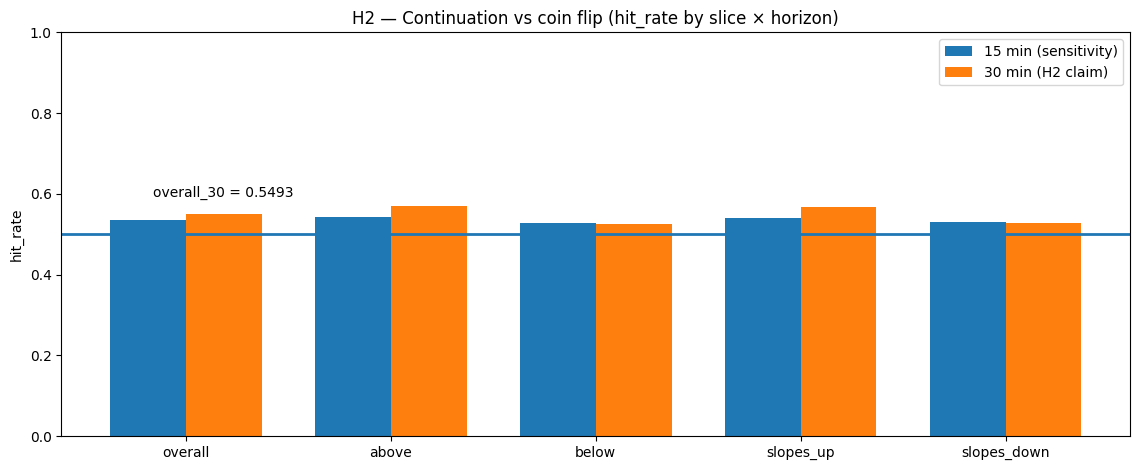

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- (c1) Continuation vs coin flip (core H2 claim) ---
# We include exactly the slices listed in your doc: overall, above, below, slopes_up, slopes_down
# and we show both horizons: 15 (sensitivity) + 30 (main claim)

slices = ["overall", "above", "below", "slopes_up", "slopes_down"]

hit_15 = [float(h2[f"{s}_15"]["hit_rate"]) for s in slices]
hit_30 = [float(h2[f"{s}_30"]["hit_rate"]) for s in slices]

x = np.arange(len(slices))
width = 0.37

fig, ax = plt.subplots(figsize=(11.5, 4.8))

bars15 = ax.bar(x - width/2, hit_15, width, label="15 min (sensitivity)")
bars30 = ax.bar(x + width/2, hit_30, width, label="30 min (H2 claim)")

# coin-flip reference line at 0.50
ax.axhline(0.50, linewidth=2)

ax.set_ylim(0, 1)
ax.set_ylabel("hit_rate")
ax.set_xticks(x)
ax.set_xticklabels(slices)
ax.set_title("H2 — Continuation vs coin flip (hit_rate by slice × horizon)")

# Emphasize the doc’s interpretation focus: overall_30
overall_30 = float(h2["overall_30"]["hit_rate"])
b = bars30[0]  # first slice is "overall", 30-min bar
ax.annotate(
    f"overall_30 = {overall_30:.4f}",
    xy=(b.get_x() + b.get_width()/2, b.get_height()),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
    va="bottom"
)

ax.legend()
plt.tight_layout()
plt.show()


In [25]:

import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H2 — Plot #1 text (Hit-rate vs 0.50 coin flip, slice × horizon)
# Uses ONLY the exact values that appear in this plot: hit_rate (+ N for context)
# Assumes: h2 is already loaded (dict)
# ==========================

# 1) Pull the exact values used in Plot #1
segments = ["overall", "above", "below", "slopes_up", "slopes_down"]
slices = [f"{s}_15" for s in segments] + [f"{s}_30" for s in segments]

label_map = {
    "overall_15": "overall (15m)",
    "above_15": "above (15m)",
    "below_15": "below (15m)",
    "slopes_up_15": "slopes_up (15m)",
    "slopes_down_15": "slopes_down (15m)",
    "overall_30": "overall (30m)",
    "above_30": "above (30m)",
    "below_30": "below (30m)",
    "slopes_up_30": "slopes_up (30m)",
    "slopes_down_30": "slopes_down (30m)",
}

rows = []
for k in slices:
    if k not in h2:
        raise KeyError(f"Missing key in h2 JSON: {k}")
    b = h2[k]
    rows.append({
        "slice": label_map[k],
        "segment": k.rsplit("_", 1)[0],
        "horizon": int(k.rsplit("_", 1)[1]),
        "N": int(b.get("N", 0)),
        "hit_rate": float(b["hit_rate"]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)
df["delta_vs_50"] = df["hit_rate"] - 0.50

# Split views
df15 = df[df["horizon"] == 15].copy()
df30 = df[df["horizon"] == 30].copy()

best30 = df30.sort_values("hit_rate", ascending=False).iloc[0]
worst30 = df30.sort_values("hit_rate", ascending=True).iloc[0]

best15 = df15.sort_values("hit_rate", ascending=False).iloc[0]
worst15 = df15.sort_values("hit_rate", ascending=True).iloc[0]

count_above_30 = int((df30["hit_rate"] > 0.50).sum())
count_below_30 = int((df30["hit_rate"] < 0.50).sum())
count_above_15 = int((df15["hit_rate"] > 0.50).sum())
count_below_15 = int((df15["hit_rate"] < 0.50).sum())

def pct(x): 
    return f"{100*x:.1f}%"

def fmt_delta(d):
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

md = f"""
## H2 — Plot #1 (Continuation vs 0.50 coin flip: hit_rate by slice × horizon)

### What this plot is checking
H2 makes one core probability claim:

> **At 30 minutes, continuation should be above a 0.50 coin flip** in the H2 setup.

So this plot asks (for each slice):

- **Is hit_rate above 0.50 at 30 minutes (H2 claim horizon)?**
- And as a sensitivity check: **does the same pattern already appear at 15 minutes?**

### What we see at 30 minutes (the H2 claim horizon)
- **{count_above_30}/5** slices are **above 0.50**, and **{count_below_30}/5** are **below 0.50**.
- Best 30m bar: **{best30['slice']}** → hit-rate **{best30['hit_rate']:.3f} ({pct(best30['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(best30['delta_vs_50'])}**, N={int(best30['N'])}.
- Weakest 30m bar: **{worst30['slice']}** → hit-rate **{worst30['hit_rate']:.3f} ({pct(worst30['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(worst30['delta_vs_50'])}**, N={int(worst30['N'])}.

### What we see at 15 minutes (sensitivity only)
- **{count_above_15}/5** slices are **above 0.50**, and **{count_below_15}/5** are **below 0.50**.
- Best 15m bar: **{best15['slice']}** → hit-rate **{best15['hit_rate']:.3f} ({pct(best15['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(best15['delta_vs_50'])}**, N={int(best15['N'])}.
- Weakest 15m bar: **{worst15['slice']}** → hit-rate **{worst15['hit_rate']:.3f} ({pct(worst15['hit_rate'])})**, Δ vs 0.50 = **{fmt_delta(worst15['delta_vs_50'])}**, N={int(worst15['N'])}.

### What this means for H2 (based on Plot #1 only)
This plot is only about **“above 0.50 or not”** (continuation vs coin flip).  
If the 30-minute bars sit **consistently above** the 0.50 line, then Plot #1 supports H2’s **directional probability claim** at its intended horizon.  
This plot does **not** answer whether the edge is “real vs baseline”, statistically stable, or economically tradable — those are handled in later plots.
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","hit_rate","delta_vs_50"]])


## H2 — Plot #1 (Continuation vs 0.50 coin flip: hit_rate by slice × horizon)

### What this plot is checking
H2 makes one core probability claim:

> **At 30 minutes, continuation should be above a 0.50 coin flip** in the H2 setup.

So this plot asks (for each slice):

- **Is hit_rate above 0.50 at 30 minutes (H2 claim horizon)?**
- And as a sensitivity check: **does the same pattern already appear at 15 minutes?**

### What we see at 30 minutes (the H2 claim horizon)
- **5/5** slices are **above 0.50**, and **0/5** are **below 0.50**.
- Best 30m bar: **above (30m)** → hit-rate **0.569 (56.9%)**, Δ vs 0.50 = **+0.069 (+6.9pp)**, N=7351.
- Weakest 30m bar: **below (30m)** → hit-rate **0.526 (52.6%)**, Δ vs 0.50 = **+0.026 (+2.6pp)**, N=6226.

### What we see at 15 minutes (sensitivity only)
- **5/5** slices are **above 0.50**, and **0/5** are **below 0.50**.
- Best 15m bar: **above (15m)** → hit-rate **0.542 (54.2%)**, Δ vs 0.50 = **+0.042 (+4.2pp)**, N=7351.
- Weakest 15m bar: **below (15m)** → hit-rate **0.528 (52.8%)**, Δ vs 0.50 = **+0.028 (+2.8pp)**, N=6226.

### What this means for H2 (based on Plot #1 only)
This plot is only about **“above 0.50 or not”** (continuation vs coin flip).  
If the 30-minute bars sit **consistently above** the 0.50 line, then Plot #1 supports H2’s **directional probability claim** at its intended horizon.  
This plot does **not** answer whether the edge is “real vs baseline”, statistically stable, or economically tradable — those are handled in later plots.

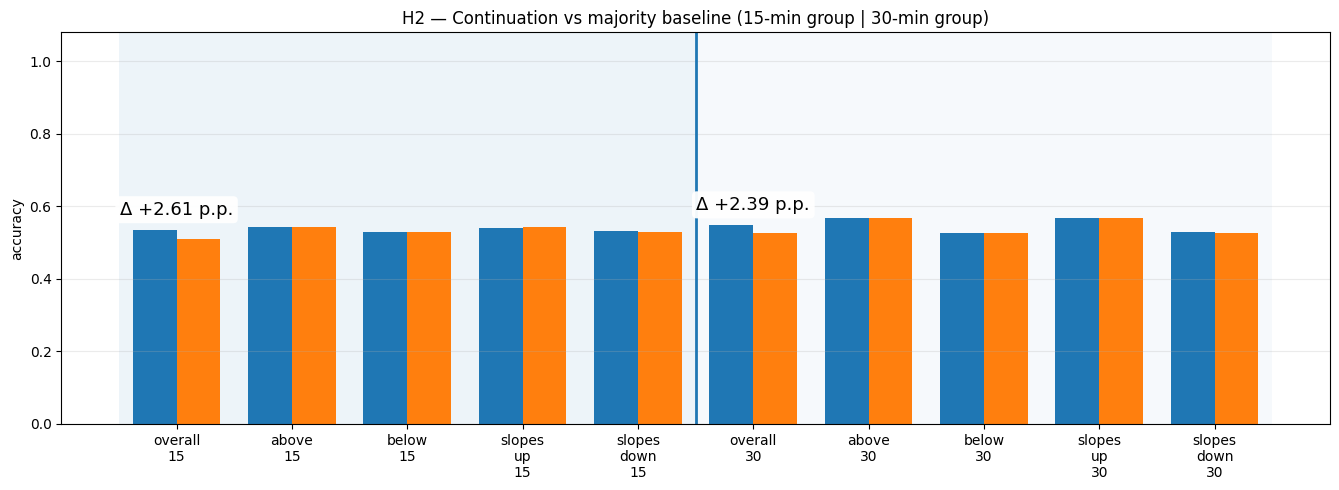

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- blocks grouped by horizon (same 10 blocks) ---
blocks_15 = ["overall_15", "above_15", "below_15", "slopes_up_15", "slopes_down_15"]
blocks_30 = ["overall_30", "above_30", "below_30", "slopes_up_30", "slopes_down_30"]
blocks = blocks_15 + blocks_30

hit  = np.array([float(h2[b]["hit_rate"]) for b in blocks])
base = np.array([float(h2[b]["majority_baseline_acc"]) for b in blocks])
lift = hit - base                     # absolute lift (0.0239 ~ 2.39 p.p.)

x = np.arange(len(blocks))
width = 0.38

fig, ax = plt.subplots(figsize=(13.5, 5.0))

# horizon separation (visual only)
ax.axvspan(-0.5, len(blocks_15)-0.5, alpha=0.08)
ax.axvspan(len(blocks_15)-0.5, len(blocks)-0.5, alpha=0.04)
ax.axvline(len(blocks_15)-0.5, linewidth=2)

bars_hit  = ax.bar(x - width/2, hit,  width, label="hit_rate (H2 prediction)")
bars_base = ax.bar(x + width/2, base, width, label="majority_baseline_acc (naive)")

ax.set_ylabel("accuracy")
ax.set_title("H2 — Continuation vs majority baseline (15-min group | 30-min group)")
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", "\n") for b in blocks])
ax.grid(axis="y", alpha=0.25)

# headroom for labels
ax.set_ylim(0, 1.08)

def write_lift(block_name, font_size=13):
    i = blocks.index(block_name)
    y_top = max(hit[i], base[i])
    y = y_top + 0.03

    # absolute lift in percentage points
    pp = lift[i] * 100.0   # 0.0239 -> 2.39

    ax.text(
        x[i], y,
        f"Δ {pp:+.2f} p.p.",
        ha="center", va="bottom",
        fontsize=font_size,
        bbox=dict(boxstyle="round,pad=0.25",
                  facecolor="white", alpha=0.95, linewidth=0),
        clip_on=False
    )


write_lift("overall_30")
write_lift("overall_15")


plt.tight_layout()
plt.show()


In [27]:

import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H2 — Plot #2 text
# Continuation vs majority baseline (15-min group | 30-min group)
# Uses ONLY: hit_rate, majority_baseline_acc, N
# Assumes: h2 is already loaded (dict)
# ==========================

segments = ["overall", "above", "below", "slopes_up", "slopes_down"]
slices = [f"{s}_15" for s in segments] + [f"{s}_30" for s in segments]

label_map = {
    "overall_15": "overall (15m)",
    "above_15": "above (15m)",
    "below_15": "below (15m)",
    "slopes_up_15": "slopes_up (15m)",
    "slopes_down_15": "slopes_down (15m)",
    "overall_30": "overall (30m)",
    "above_30": "above (30m)",
    "below_30": "below (30m)",
    "slopes_up_30": "slopes_up (30m)",
    "slopes_down_30": "slopes_down (30m)",
}

rows = []
for k in slices:
    if k not in h2:
        raise KeyError(f"Missing key in h2 JSON: {k}")
    b = h2[k]
    rows.append({
        "slice": label_map[k],
        "segment": k.rsplit("_", 1)[0],
        "horizon": int(k.rsplit("_", 1)[1]),
        "N": int(b.get("N", 0)),
        "hit_rate": float(b["hit_rate"]),
        "baseline": float(b["majority_baseline_acc"]),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)
df["lift"] = df["hit_rate"] - df["baseline"]

df15 = df[df["horizon"] == 15].copy()
df30 = df[df["horizon"] == 30].copy()

# "headline" numbers shown on the chart are the overall lifts
lift_overall_15 = float(df15[df15["segment"] == "overall"]["lift"].iloc[0])
lift_overall_30 = float(df30[df30["segment"] == "overall"]["lift"].iloc[0])

# Count how many slices actually beat baseline (lift > 0)
count_pos_15 = int((df15["lift"] > 0).sum())
count_zero_15 = int((df15["lift"] == 0).sum())
count_neg_15 = int((df15["lift"] < 0).sum())

count_pos_30 = int((df30["lift"] > 0).sum())
count_zero_30 = int((df30["lift"] == 0).sum())
count_neg_30 = int((df30["lift"] < 0).sum())

# Best/worst lift within each horizon
best15 = df15.sort_values("lift", ascending=False).iloc[0]
worst15 = df15.sort_values("lift", ascending=True).iloc[0]
best30 = df30.sort_values("lift", ascending=False).iloc[0]
worst30 = df30.sort_values("lift", ascending=True).iloc[0]

def pct(x): 
    return f"{100*x:.1f}%"

def fmt_pp(x):  # percentage points
    sign = "+" if x >= 0 else ""
    return f"{sign}{100*x:.2f} p.p."

md = f"""
## H2 — Plot #2 (Continuation vs majority baseline: 15-min group | 30-min group)

### Why we need this plot (what Plot #1 could not tell us)
Plot #1 only asked “is hit_rate above 0.50?”.  
But H2 can look good even if it is simply matching the slice’s natural class imbalance.

So Plot #2 asks a stricter question:

> **Does H2 beat the “majority baseline” inside the same slice?**  
> (baseline = “always predict the majority class in that slice”)

In the chart, **blue = H2 hit_rate** and **orange = majority_baseline_acc**.  
The vertical gap between them is the **lift**: **hit_rate − baseline**.

### What we see at 15 minutes (left group)
- Overall lift at 15m is **{fmt_pp(lift_overall_15)}**  
  (H2: **{pct(h2['overall_15']['hit_rate'])}** vs baseline: **{pct(h2['overall_15']['majority_baseline_acc'])}**, N={int(h2['overall_15']['N'])}).
- Slice-by-slice, **{count_pos_15}/5** lifts are **positive**, **{count_zero_15}/5** are **zero**, and **{count_neg_15}/5** are **negative**.
- Biggest positive lift (15m): **{best15['slice']}** → lift **{fmt_pp(best15['lift'])}** (H2 {pct(best15['hit_rate'])} vs baseline {pct(best15['baseline'])}).
- Weakest lift (15m): **{worst15['slice']}** → lift **{fmt_pp(worst15['lift'])}** (H2 {pct(worst15['hit_rate'])} vs baseline {pct(worst15['baseline'])}).

### What we see at 30 minutes (right group — this is the H2 claim horizon)
- Overall lift at 30m is **{fmt_pp(lift_overall_30)}**  
  (H2: **{pct(h2['overall_30']['hit_rate'])}** vs baseline: **{pct(h2['overall_30']['majority_baseline_acc'])}**, N={int(h2['overall_30']['N'])}).
- Slice-by-slice, **{count_pos_30}/5** lifts are **positive**, **{count_zero_30}/5** are **zero**, and **{count_neg_30}/5** are **negative**.
- Biggest positive lift (30m): **{best30['slice']}** → lift **{fmt_pp(best30['lift'])}** (H2 {pct(best30['hit_rate'])} vs baseline {pct(best30['baseline'])}).
- Weakest lift (30m): **{worst30['slice']}** → lift **{fmt_pp(worst30['lift'])}** (H2 {pct(worst30['hit_rate'])} vs baseline {pct(worst30['baseline'])}).

### What this means for H2 (based on Plot #2 only)
This plot isolates “real value-add” beyond class imbalance.

- If the **overall_30** lift is clearly positive, then H2 is not just “above 50%” — it is **better than the best dumb predictor** inside the same overall slice.
- If many slice-level lifts are ~0, that means: **within those slices, H2 behaves like the majority rule**, so the edge is mainly visible in the **overall aggregation** rather than inside each individual slice.

(We still do not claim statistical certainty or economic tradability here; Plot #2 is only about **accuracy lift vs baseline**.)
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","hit_rate","baseline","lift"]])


## H2 — Plot #2 (Continuation vs majority baseline: 15-min group | 30-min group)

### Why we need this plot (what Plot #1 could not tell us)
Plot #1 only asked “is hit_rate above 0.50?”.  
But H2 can look good even if it is simply matching the slice’s natural class imbalance.

So Plot #2 asks a stricter question:

> **Does H2 beat the “majority baseline” inside the same slice?**  
> (baseline = “always predict the majority class in that slice”)

In the chart, **blue = H2 hit_rate** and **orange = majority_baseline_acc**.  
The vertical gap between them is the **lift**: **hit_rate − baseline**.

### What we see at 15 minutes (left group)
- Overall lift at 15m is **+2.61 p.p.**  
  (H2: **53.6%** vs baseline: **51.0%**, N=13577).
- Slice-by-slice, **2/5** lifts are **positive**, **2/5** are **zero**, and **1/5** are **negative**.
- Biggest positive lift (15m): **overall (15m)** → lift **+2.61 p.p.** (H2 53.6% vs baseline 51.0%).
- Weakest lift (15m): **slopes_up (15m)** → lift **-0.31 p.p.** (H2 54.0% vs baseline 54.3%).

### What we see at 30 minutes (right group — this is the H2 claim horizon)
- Overall lift at 30m is **+2.39 p.p.**  
  (H2: **54.9%** vs baseline: **52.5%**, N=13577).
- Slice-by-slice, **2/5** lifts are **positive**, **2/5** are **zero**, and **1/5** are **negative**.
- Biggest positive lift (30m): **overall (30m)** → lift **+2.39 p.p.** (H2 54.9% vs baseline 52.5%).
- Weakest lift (30m): **slopes_up (30m)** → lift **-0.26 p.p.** (H2 56.7% vs baseline 56.9%).

### What this means for H2 (based on Plot #2 only)
This plot isolates “real value-add” beyond class imbalance.

- If the **overall_30** lift is clearly positive, then H2 is not just “above 50%” — it is **better than the best dumb predictor** inside the same overall slice.
- If many slice-level lifts are ~0, that means: **within those slices, H2 behaves like the majority rule**, so the edge is mainly visible in the **overall aggregation** rather than inside each individual slice.

(We still do not claim statistical certainty or economic tradability here; Plot #2 is only about **accuracy lift vs baseline**.)

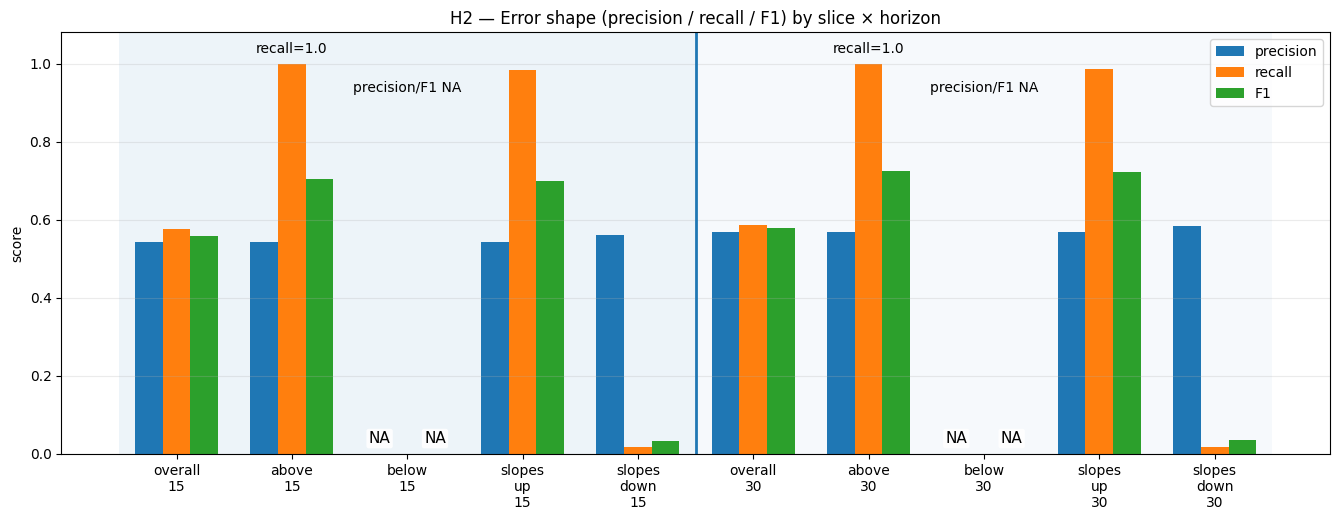

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- Figür 3: Error shape (precision / recall / F1) over the SAME 10 blocks ---
blocks_15 = ["overall_15", "above_15", "below_15", "slopes_up_15", "slopes_down_15"]
blocks_30 = ["overall_30", "above_30", "below_30", "slopes_up_30", "slopes_down_30"]
blocks = blocks_15 + blocks_30

def get_metric(block, key):
    v = h2[block].get(key, None)
    # Handle JSON strings like "not calculated" -> treat as missing (NA)
    if isinstance(v, str):
        return np.nan
    return float(v) if v is not None else np.nan

precision = np.array([get_metric(b, "precision") for b in blocks])
recall    = np.array([get_metric(b, "recall") for b in blocks])
f1        = np.array([get_metric(b, "f1") for b in blocks])

x = np.arange(len(blocks))
width = 0.24

fig, ax = plt.subplots(figsize=(13.5, 5.3))

# horizon separation (visual only)
ax.axvspan(-0.5, len(blocks_15)-0.5, alpha=0.08)
ax.axvspan(len(blocks_15)-0.5, len(blocks)-0.5, alpha=0.04)
ax.axvline(len(blocks_15)-0.5, linewidth=2)

# Bars (matplotlib skips NaN bars automatically: those simply won't draw)
ax.bar(x - width, precision, width, label="precision")
ax.bar(x,         recall,    width, label="recall")
ax.bar(x + width, f1,        width, label="F1")

ax.set_ylim(0, 1.08)
ax.set_ylabel("score")
ax.set_title("H2 — Error shape (precision / recall / F1) by slice × horizon")
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", "\n") for b in blocks])
ax.grid(axis="y", alpha=0.25)

# NA labels: if precision or f1 is not calculated, explicitly show "NA" above that slot
def write_na_if_needed(arr, key_name, x_offset):
    for i, v in enumerate(arr):
        if np.isnan(v):
            ax.text(
                x[i] + x_offset, 0.02,
                "NA",
                ha="center", va="bottom",
                fontsize=11,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.9, linewidth=0),
                clip_on=False
            )

write_na_if_needed(precision, "precision", -width)
write_na_if_needed(f1, "f1", +width)

# Expected H2 diagnostic cues (doc-aligned):
# - above_* recall should be 1.0
# - below_* precision/F1 should be NA (not calculated)
for b in ["above_15", "above_30"]:
    i = blocks.index(b)
    ax.text(x[i], 1.02, "recall=1.0", ha="center", va="bottom", fontsize=10)

for b in ["below_15", "below_30"]:
    i = blocks.index(b)
    ax.text(x[i], 0.92, "precision/F1 NA", ha="center", va="bottom", fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()


In [29]:

import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H2 — Plot #3 text
# Error shape (precision / recall / F1) by slice × horizon
# Uses ONLY: precision, recall, f1 (+ N for context)
# Assumes: h2 is already loaded (dict)
# ==========================

segments = ["overall", "above", "below", "slopes_up", "slopes_down"]
slices = [f"{s}_15" for s in segments] + [f"{s}_30" for s in segments]

label_map = {
    "overall_15": "overall (15m)",
    "above_15": "above (15m)",
    "below_15": "below (15m)",
    "slopes_up_15": "slopes_up (15m)",
    "slopes_down_15": "slopes_down (15m)",
    "overall_30": "overall (30m)",
    "above_30": "above (30m)",
    "below_30": "below (30m)",
    "slopes_up_30": "slopes_up (30m)",
    "slopes_down_30": "slopes_down (30m)",
}

def to_float_or_nan(x):
    if x is None:
        return float("nan")
    if isinstance(x, str) and x.strip().lower() == "not calculated":
        return float("nan")
    return float(x)

rows = []
for k in slices:
    if k not in h2:
        raise KeyError(f"Missing key in h2 JSON: {k}")
    b = h2[k]
    rows.append({
        "slice": label_map[k],
        "segment": k.rsplit("_", 1)[0],
        "horizon": int(k.rsplit("_", 1)[1]),
        "N": int(b.get("N", 0)),
        "precision": to_float_or_nan(b.get("precision")),
        "recall": to_float_or_nan(b.get("recall")),
        "f1": to_float_or_nan(b.get("f1")),
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

df15 = df[df["horizon"] == 15].copy()
df30 = df[df["horizon"] == 30].copy()

# Count NA occurrences in each horizon (as shown in the plot annotations)
na_prec_15 = int(df15["precision"].isna().sum())
na_f1_15   = int(df15["f1"].isna().sum())
na_prec_30 = int(df30["precision"].isna().sum())
na_f1_30   = int(df30["f1"].isna().sum())

# Identify extreme recall patterns visible in chart (recall==1.0 or very close to 0)
def near(x, target, tol=1e-12):
    return (pd.notna(x)) and abs(float(x) - target) <= tol

recall_ones_15 = df15[df15["recall"].apply(lambda x: near(x, 1.0))]["slice"].tolist()
recall_ones_30 = df30[df30["recall"].apply(lambda x: near(x, 1.0))]["slice"].tolist()

recall_near0_15 = df15[df15["recall"].apply(lambda x: pd.notna(x) and float(x) < 0.05)]["slice"].tolist()
recall_near0_30 = df30[df30["recall"].apply(lambda x: pd.notna(x) and float(x) < 0.05)]["slice"].tolist()

# Best/worst F1 where defined (F1 is the "balanced summary" when it exists)
df15_f1 = df15.dropna(subset=["f1"]).copy()
df30_f1 = df30.dropna(subset=["f1"]).copy()

best15_f1 = df15_f1.sort_values("f1", ascending=False).iloc[0] if len(df15_f1) else None
worst15_f1 = df15_f1.sort_values("f1", ascending=True).iloc[0] if len(df15_f1) else None
best30_f1 = df30_f1.sort_values("f1", ascending=False).iloc[0] if len(df30_f1) else None
worst30_f1 = df30_f1.sort_values("f1", ascending=True).iloc[0] if len(df30_f1) else None

def pct(x):
    return f"{100*x:.1f}%"

def fmt_val(x):
    return "NA" if pd.isna(x) else f"{x:.3f} ({pct(x)})"

md = f"""
## H2 — Plot #3 (Error shape: precision / recall / F1 by slice × horizon)

### What this plot is checking
Plot #1 and Plot #2 told us about **accuracy** (hit_rate) and **lift vs baseline**.  
This plot is different: it shows the **shape of errors**.

It asks:

- **Precision**: when H2 predicts a direction, how often is that predicted direction correct?
- **Recall**: out of all true “up” cases, how many did H2 successfully catch as “up”?
- **F1**: a single, balanced summary that only makes sense when both classes are actually predicted.

### What we expected to see
If H2 is a well-balanced continuation rule, we would expect:
- precision and recall to be both meaningfully above 0.50, and
- F1 to be defined (not NA) across slices.

### What we actually see in this chart

#### 1) Some slices produce NA metrics — this is not a plotting error
- At **15m**, precision is NA in **{na_prec_15}/5** slices and F1 is NA in **{na_f1_15}/5** slices.
- At **30m**, precision is NA in **{na_prec_30}/5** slices and F1 is NA in **{na_f1_30}/5** slices.

Those NA blocks happen when H2’s prediction collapses to essentially **one-sided** calls inside that slice
(e.g., you never predict the opposite class), so precision/F1 cannot be computed in the usual way.

#### 2) Recall spikes reveal “one-sided” behavior
- Recall = 1.0 appears in:  
  - **15m:** {", ".join(recall_ones_15) if recall_ones_15 else "none"}  
  - **30m:** {", ".join(recall_ones_30) if recall_ones_30 else "none"}

Recall near 0 appears in:
  - **15m:** {", ".join(recall_near0_15) if recall_near0_15 else "none"}  
  - **30m:** {", ".join(recall_near0_30) if recall_near0_30 else "none"}

Interpretation (plot-level only): when recall is ~1.0, the rule is effectively catching almost all “up” cases in that slice;  
when recall is near 0, the rule is effectively missing the “up” class in that slice.

#### 3) Where F1 is defined, it shows which slices are more balanced
At **15m** (only slices with defined F1):
- Best F1: **{best15_f1['slice']}** → F1 **{fmt_val(best15_f1['f1'])}**, precision **{fmt_val(best15_f1['precision'])}**, recall **{fmt_val(best15_f1['recall'])}**, N={int(best15_f1['N'])}.
- Weakest F1: **{worst15_f1['slice']}** → F1 **{fmt_val(worst15_f1['f1'])}**, precision **{fmt_val(worst15_f1['precision'])}**, recall **{fmt_val(worst15_f1['recall'])}**, N={int(worst15_f1['N'])}.

At **30m** (only slices with defined F1):
- Best F1: **{best30_f1['slice']}** → F1 **{fmt_val(best30_f1['f1'])}**, precision **{fmt_val(best30_f1['precision'])}**, recall **{fmt_val(best30_f1['recall'])}**, N={int(best30_f1['N'])}.
- Weakest F1: **{worst30_f1['slice']}** → F1 **{fmt_val(worst30_f1['f1'])}**, precision **{fmt_val(worst30_f1['precision'])}**, recall **{fmt_val(worst30_f1['recall'])}**, N={int(worst30_f1['N'])}.

### What this means for H2 (based on Plot #3 only)
This plot shows that H2 is **not uniformly “balanced”** across slices.

- In some slices, recall saturates (≈1.0) and F1 is high: this looks like a strong one-sided continuation caller.
- In other slices, recall is near zero or precision/F1 become NA: this indicates the rule is not meaningfully operating as a symmetric classifier in that slice.

So Plot #3 is a warning label: even if accuracy looks decent, the **error profile is very uneven** across slices,
and some slices are effectively “single-direction” regimes where not all metrics are informative.
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","precision","recall","f1"]])


## H2 — Plot #3 (Error shape: precision / recall / F1 by slice × horizon)

### What this plot is checking
Plot #1 and Plot #2 told us about **accuracy** (hit_rate) and **lift vs baseline**.  
This plot is different: it shows the **shape of errors**.

It asks:

- **Precision**: when H2 predicts a direction, how often is that predicted direction correct?
- **Recall**: out of all true “up” cases, how many did H2 successfully catch as “up”?
- **F1**: a single, balanced summary that only makes sense when both classes are actually predicted.

### What we expected to see
If H2 is a well-balanced continuation rule, we would expect:
- precision and recall to be both meaningfully above 0.50, and
- F1 to be defined (not NA) across slices.

### What we actually see in this chart

#### 1) Some slices produce NA metrics — this is not a plotting error
- At **15m**, precision is NA in **1/5** slices and F1 is NA in **1/5** slices.
- At **30m**, precision is NA in **1/5** slices and F1 is NA in **1/5** slices.

Those NA blocks happen when H2’s prediction collapses to essentially **one-sided** calls inside that slice
(e.g., you never predict the opposite class), so precision/F1 cannot be computed in the usual way.

#### 2) Recall spikes reveal “one-sided” behavior
- Recall = 1.0 appears in:  
  - **15m:** above (15m)  
  - **30m:** above (30m)

Recall near 0 appears in:
  - **15m:** below (15m), slopes_down (15m)  
  - **30m:** below (30m), slopes_down (30m)

Interpretation (plot-level only): when recall is ~1.0, the rule is effectively catching almost all “up” cases in that slice;  
when recall is near 0, the rule is effectively missing the “up” class in that slice.

#### 3) Where F1 is defined, it shows which slices are more balanced
At **15m** (only slices with defined F1):
- Best F1: **above (15m)** → F1 **0.703 (70.3%)**, precision **0.542 (54.2%)**, recall **1.000 (100.0%)**, N=7351.
- Weakest F1: **slopes_down (15m)** → F1 **0.033 (3.3%)**, precision **0.562 (56.2%)**, recall **0.017 (1.7%)**, N=6208.

At **30m** (only slices with defined F1):
- Best F1: **above (30m)** → F1 **0.725 (72.5%)**, precision **0.569 (56.9%)**, recall **1.000 (100.0%)**, N=7351.
- Weakest F1: **slopes_down (30m)** → F1 **0.034 (3.4%)**, precision **0.584 (58.4%)**, recall **0.018 (1.8%)**, N=6208.

### What this means for H2 (based on Plot #3 only)
This plot shows that H2 is **not uniformly “balanced”** across slices.

- In some slices, recall saturates (≈1.0) and F1 is high: this looks like a strong one-sided continuation caller.
- In other slices, recall is near zero or precision/F1 become NA: this indicates the rule is not meaningfully operating as a symmetric classifier in that slice.

So Plot #3 is a warning label: even if accuracy looks decent, the **error profile is very uneven** across slices,
and some slices are effectively “single-direction” regimes where not all metrics are informative.

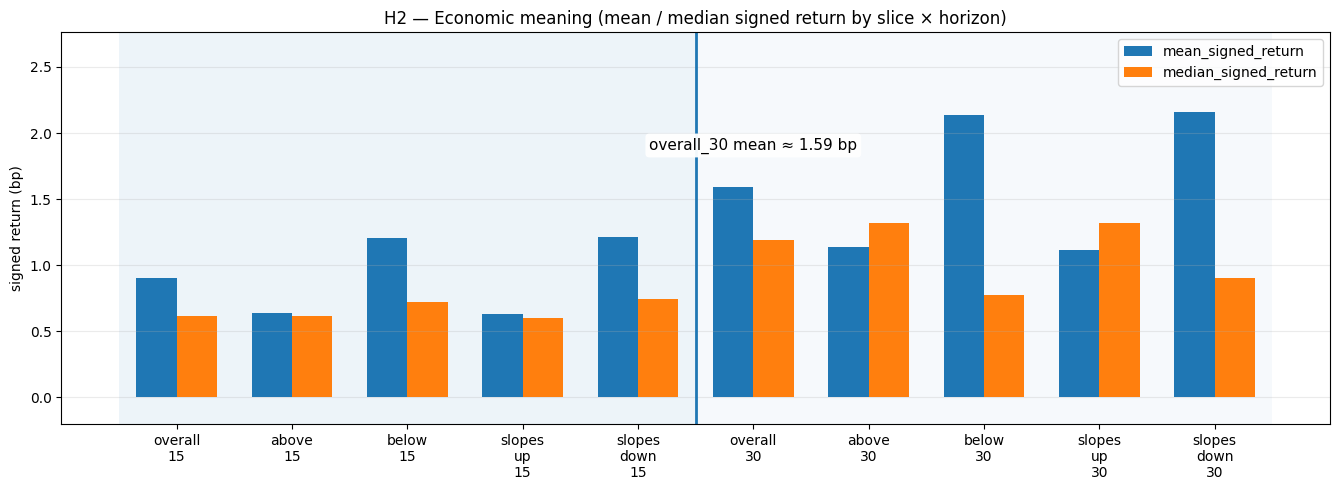

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- Figure 4: Economic meaning (mean / median signed return) ---
blocks_15 = ["overall_15", "above_15", "below_15", "slopes_up_15", "slopes_down_15"]
blocks_30 = ["overall_30", "above_30", "below_30", "slopes_up_30", "slopes_down_30"]
blocks = blocks_15 + blocks_30


# 1 bp = 0.0001 → value * 10_000 = bp
scale = 10_000.0

mean_ret_bp   = np.array([float(h2[b]["mean_signed_return"])   * scale for b in blocks])
median_ret_bp = np.array([float(h2[b]["median_signed_return"]) * scale for b in blocks])

x = np.arange(len(blocks))
width = 0.35

fig, ax = plt.subplots(figsize=(13.5, 5.0))

# horizon separation (visual only)
ax.axvspan(-0.5, len(blocks_15)-0.5, alpha=0.08)
ax.axvspan(len(blocks_15)-0.5, len(blocks)-0.5, alpha=0.04)
ax.axvline(len(blocks_15)-0.5, linewidth=2)

bars_mean   = ax.bar(x - width/2, mean_ret_bp,   width, label="mean_signed_return")
bars_median = ax.bar(x + width/2, median_ret_bp, width, label="median_signed_return")

ax.set_ylabel("signed return (bp)")
ax.set_title("H2 — Economic meaning (mean / median signed return by slice × horizon)")
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", "\n") for b in blocks])
ax.grid(axis="y", alpha=0.25)

# headroom for annotation
ymax = max(mean_ret_bp.max(), median_ret_bp.max())
ax.set_ylim(min(0, mean_ret_bp.min(), median_ret_bp.min()) - 0.2, ymax + 0.6)


i_overall_30 = blocks.index("overall_30")
ax.text(
    x[i_overall_30],
    mean_ret_bp[i_overall_30] + 0.25,
    f"overall_30 mean ≈ {mean_ret_bp[i_overall_30]:.2f} bp",
    ha="center", va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.95, linewidth=0),
    clip_on=False,
)



ax.legend()
plt.tight_layout()
plt.show()


In [31]:

import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H2 — Plot #4 text
# Economic meaning (mean / median signed return by slice × horizon)
# Uses ONLY: mean_signed_return, median_signed_return (+ N for context)
# Assumes: h2 is already loaded (dict)
# ==========================

segments = ["overall", "above", "below", "slopes_up", "slopes_down"]
slices = [f"{s}_15" for s in segments] + [f"{s}_30" for s in segments]

label_map = {
    "overall_15": "overall (15m)",
    "above_15": "above (15m)",
    "below_15": "below (15m)",
    "slopes_up_15": "slopes_up (15m)",
    "slopes_down_15": "slopes_down (15m)",
    "overall_30": "overall (30m)",
    "above_30": "above (30m)",
    "below_30": "below (30m)",
    "slopes_up_30": "slopes_up (30m)",
    "slopes_down_30": "slopes_down (30m)",
}

# 1) Pull the exact values used in Plot #4 (convert to basis points for readability)
rows = []
for k in slices:
    if k not in h2:
        raise KeyError(f"Missing key in h2 JSON: {k}")
    b = h2[k]
    rows.append({
        "slice": label_map[k],
        "segment": k.rsplit("_", 1)[0],
        "horizon": int(k.rsplit("_", 1)[1]),
        "N": int(b.get("N", 0)),
        "mean_bp": float(b["mean_signed_return"]) / 0.0001,    # 1 bp = 0.0001
        "median_bp": float(b["median_signed_return"]) / 0.0001,
    })

df = pd.DataFrame(rows).sort_values(["horizon", "segment"]).reset_index(drop=True)

df15 = df[df["horizon"] == 15].copy()
df30 = df[df["horizon"] == 30].copy()

# "headline" value called out in the plot (overall_30 mean ≈ 1.59 bp)
overall30_mean = float(df30[df30["segment"] == "overall"]["mean_bp"].iloc[0])
overall30_median = float(df30[df30["segment"] == "overall"]["median_bp"].iloc[0])

# Identify extremes at the claim horizon (30m)
best30_mean = df30.sort_values("mean_bp", ascending=False).iloc[0]
worst30_mean = df30.sort_values("mean_bp", ascending=True).iloc[0]

best30_median = df30.sort_values("median_bp", ascending=False).iloc[0]
worst30_median = df30.sort_values("median_bp", ascending=True).iloc[0]

# And extremes at 15m (sensitivity)
best15_mean = df15.sort_values("mean_bp", ascending=False).iloc[0]
worst15_mean = df15.sort_values("mean_bp", ascending=True).iloc[0]

best15_median = df15.sort_values("median_bp", ascending=False).iloc[0]
worst15_median = df15.sort_values("median_bp", ascending=True).iloc[0]

def fmt_bp(x):
    # keep it compact and readable
    return f"{x:.2f} bp"

md = f"""
## H2 — Plot #4 (Economic meaning: mean / median signed return by slice × horizon)

### What this plot is checking
Accuracy alone does not tell us if the continuation is **economically meaningful**.

So this plot asks:

> **When we sign returns by the H2 direction, do we get positive average returns?**  
> And is that positivity visible in both **mean** (blue) and **median** (orange)?

All values in this chart are shown in **basis points (bp)**.

### What we expected to see
If H2 continuation is not just “slightly right”, we would expect:

- **Positive mean signed return**, especially at **30 minutes** (H2’s claim horizon),
- and ideally **positive median** too (so the effect is not driven by a few outliers).

### What we actually see in this chart

#### 1) Overall economic effect is positive (especially at 30 minutes)
The plot highlights: **overall_30 mean ≈ {fmt_bp(overall30_mean)}**.  
In the same bar group, the **overall_30 median ≈ {fmt_bp(overall30_median)}**.

So at the aggregate level, H2’s signed returns are positive at 30 minutes in both mean and median.

#### 2) The 30-minute effect varies a lot by slice
At **30 minutes**:
- Highest **mean** bar: **{best30_mean['slice']}** → mean **{fmt_bp(best30_mean['mean_bp'])}**, median **{fmt_bp(best30_mean['median_bp'])}**, N={int(best30_mean['N'])}.
- Lowest **mean** bar: **{worst30_mean['slice']}** → mean **{fmt_bp(worst30_mean['mean_bp'])}**, median **{fmt_bp(worst30_mean['median_bp'])}**, N={int(worst30_mean['N'])}.

And for the **median** at 30 minutes:
- Highest median bar: **{best30_median['slice']}** → median **{fmt_bp(best30_median['median_bp'])}**, mean **{fmt_bp(best30_median['mean_bp'])}**.
- Lowest median bar: **{worst30_median['slice']}** → median **{fmt_bp(worst30_median['median_bp'])}**, mean **{fmt_bp(worst30_median['mean_bp'])}**.

This means the “economic meaning” of H2 is not uniform: some slices translate continuation into larger moves than others.

#### 3) 15-minute returns are positive but generally smaller (sensitivity)
At **15 minutes**:
- Highest mean: **{best15_mean['slice']}** → mean **{fmt_bp(best15_mean['mean_bp'])}**, median **{fmt_bp(best15_mean['median_bp'])}**.
- Lowest mean: **{worst15_mean['slice']}** → mean **{fmt_bp(worst15_mean['mean_bp'])}**, median **{fmt_bp(worst15_mean['median_bp'])}**.

So the economic effect exists already at 15 minutes, but the chart suggests it becomes more pronounced by 30 minutes.

### What this means for H2 (based on Plot #4 only)
Based only on signed returns, H2 has **positive economic directionality** overall — especially at the 30-minute horizon it claims.
However, the magnitude depends strongly on slice: some contexts produce much larger mean signed returns than others,
and mean vs median gaps tell us whether those gains are “broad” (median also high) or more “outlier-driven” (mean high, median lower).
""".strip()

display(Markdown(md))

# Optional: show the exact table behind the plot
# display(df[["slice","N","mean_bp","median_bp"]])


## H2 — Plot #4 (Economic meaning: mean / median signed return by slice × horizon)

### What this plot is checking
Accuracy alone does not tell us if the continuation is **economically meaningful**.

So this plot asks:

> **When we sign returns by the H2 direction, do we get positive average returns?**  
> And is that positivity visible in both **mean** (blue) and **median** (orange)?

All values in this chart are shown in **basis points (bp)**.

### What we expected to see
If H2 continuation is not just “slightly right”, we would expect:

- **Positive mean signed return**, especially at **30 minutes** (H2’s claim horizon),
- and ideally **positive median** too (so the effect is not driven by a few outliers).

### What we actually see in this chart

#### 1) Overall economic effect is positive (especially at 30 minutes)
The plot highlights: **overall_30 mean ≈ 1.59 bp**.  
In the same bar group, the **overall_30 median ≈ 1.19 bp**.

So at the aggregate level, H2’s signed returns are positive at 30 minutes in both mean and median.

#### 2) The 30-minute effect varies a lot by slice
At **30 minutes**:
- Highest **mean** bar: **slopes_down (30m)** → mean **2.16 bp**, median **0.90 bp**, N=6208.
- Lowest **mean** bar: **slopes_up (30m)** → mean **1.12 bp**, median **1.32 bp**, N=7369.

And for the **median** at 30 minutes:
- Highest median bar: **above (30m)** → median **1.32 bp**, mean **1.14 bp**.
- Lowest median bar: **below (30m)** → median **0.77 bp**, mean **2.13 bp**.

This means the “economic meaning” of H2 is not uniform: some slices translate continuation into larger moves than others.

#### 3) 15-minute returns are positive but generally smaller (sensitivity)
At **15 minutes**:
- Highest mean: **slopes_down (15m)** → mean **1.22 bp**, median **0.75 bp**.
- Lowest mean: **slopes_up (15m)** → mean **0.63 bp**, median **0.60 bp**.

So the economic effect exists already at 15 minutes, but the chart suggests it becomes more pronounced by 30 minutes.

### What this means for H2 (based on Plot #4 only)
Based only on signed returns, H2 has **positive economic directionality** overall — especially at the 30-minute horizon it claims.
However, the magnitude depends strongly on slice: some contexts produce much larger mean signed returns than others,
and mean vs median gaps tell us whether those gains are “broad” (median also high) or more “outlier-driven” (mean high, median lower).

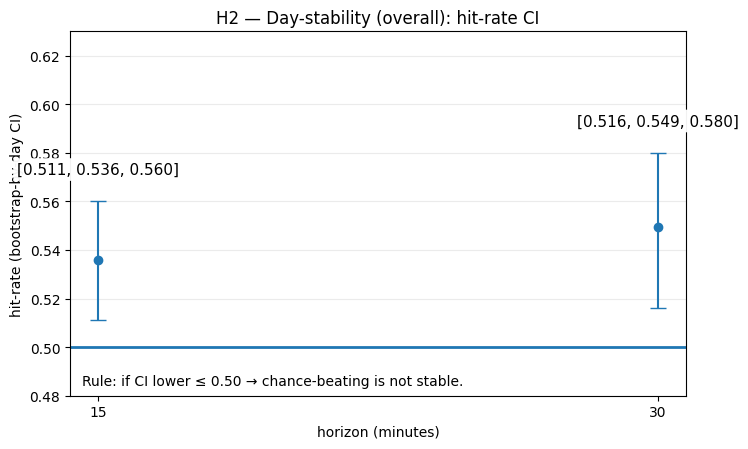

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- Figure 5: Bootstrap day-stability (hit-rate CI, overall only) ---

ci15 = h2["bootstrap_overall_15"]["hit_ci(2.5,50,97.5)"]  # [lo, med, hi]
ci30 = h2["bootstrap_overall_30"]["hit_ci(2.5,50,97.5)"]

x = np.array([15, 30], dtype=float)
med = np.array([ci15[1], ci30[1]], dtype=float)
lo  = np.array([ci15[0], ci30[0]], dtype=float)
hi  = np.array([ci15[2], ci30[2]], dtype=float)

# errorbar wants distances from the median
yerr = np.vstack([med - lo, hi - med])

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.errorbar(x, med, yerr=yerr, fmt="o", capsize=6)

# chance line
ax.axhline(0.50, linewidth=2)

ax.set_xticks([15, 30])
ax.set_xlabel("horizon (minutes)")
ax.set_ylabel("hit-rate (bootstrap-by-day CI)")
ax.set_title("H2 — Day-stability (overall): hit-rate CI")

# annotate the actual CI numbers (readable, no clutter)
for xi, (l, m, h) in zip(x, zip(lo, med, hi)):
    ax.text(
        xi, h + 0.01,
        f"[{l:.3f}, {m:.3f}, {h:.3f}]",
        ha="center", va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.95, linewidth=0),
        clip_on=False
    )

# decision-rule callout (doc-aligned)
ax.text(
    0.02, 0.02,
    "Rule: if CI lower ≤ 0.50 → chance-beating is not stable.",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=10
)

# keep a bit of headroom for CI labels
ax.set_ylim(min(0.48, lo.min() - 0.02), max(0.62, hi.max() + 0.05))
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [33]:

import pandas as pd
from IPython.display import display, Markdown

# ==========================
# H2 — Plot #5 text
# Day-stability (overall): hit-rate CI (bootstrap-by-day)
# Uses ONLY: bootstrap_overall_15.hit_ci, bootstrap_overall_30.hit_ci + overall hit_rate
# Assumes: h2 is already loaded (dict)
# ==========================

# 1) Pull the exact values used in the plot
ci15 = h2["bootstrap_overall_15"]["hit_ci(2.5,50,97.5)"]
ci30 = h2["bootstrap_overall_30"]["hit_ci(2.5,50,97.5)"]

overall15 = float(h2["overall_15"]["hit_rate"])
overall30 = float(h2["overall_30"]["hit_rate"])

n_days = int(h2["bootstrap_overall_30"]["n_days"])  # same days for both, in your JSON

def pct(x):
    return f"{100*x:.1f}%"

def fmt_ci(ci):
    lo, mid, hi = ci
    return f"[{lo:.3f}, {mid:.3f}, {hi:.3f}]"

def fmt_pp(x):  # percentage points vs 0.50
    d = x - 0.50
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

# Derived “stability” checks shown by the horizontal 0.50 line in the plot
lo15, mid15, hi15 = map(float, ci15)
lo30, mid30, hi30 = map(float, ci30)

stable15 = lo15 > 0.50
stable30 = lo30 > 0.50

md = f"""
## H2 — Plot #5 (Day-stability, overall: hit-rate confidence interval)

### Why we need this plot (what “day-stability” means)
The earlier plots used many intraday rows, but minutes inside the same day are not independent.  
So here we do a **bootstrap-by-day**: we repeatedly resample whole days and recompute **overall hit-rate**.

This plot answers one question:

> **Is H2’s hit-rate above 0.50 in a way that stays true across days (not just in the pooled rows)?**

The rule printed on the plot is the decision check:

> **If CI lower ≤ 0.50 → chance-beating is not stable.**

### What we expected to see
Because H2’s main claim is 30-minute continuation > 50%, we want:

- For **30 minutes**: the **CI lower bound** to be **above 0.50**.
- 15 minutes is only a sensitivity check, but the same condition would be a bonus.

### What we see in the intervals (overall only)
We have **{n_days} trading days** in the bootstrap universe.

- **15m overall hit-rate (point estimate):** {overall15:.3f} ({pct(overall15)})  
  **15m bootstrap CI:** {fmt_ci(ci15)}  
  Lower bound vs 0.50: **{fmt_pp(lo15)}** → {'stable' if stable15 else 'not stable'}

- **30m overall hit-rate (point estimate):** {overall30:.3f} ({pct(overall30)})  
  **30m bootstrap CI:** {fmt_ci(ci30)}  
  Lower bound vs 0.50: **{fmt_pp(lo30)}** → {'stable' if stable30 else 'not stable'}

### What this means for H2 (based on Plot #5 only)
For both horizons, the bootstrap CI lower bound stays **strictly above 0.50**.  
So by the plot’s own rule, H2’s chance-beating behavior is **day-stable** in the **overall** slice.

This does not tell us which sub-slice (above/below/slopes_up/slopes_down) is stable — this plot is **overall only** —
but it does say the overall “> 50%” continuation effect is not driven by a few lucky days.
""".strip()

display(Markdown(md))


## H2 — Plot #5 (Day-stability, overall: hit-rate confidence interval)

### Why we need this plot (what “day-stability” means)
The earlier plots used many intraday rows, but minutes inside the same day are not independent.  
So here we do a **bootstrap-by-day**: we repeatedly resample whole days and recompute **overall hit-rate**.

This plot answers one question:

> **Is H2’s hit-rate above 0.50 in a way that stays true across days (not just in the pooled rows)?**

The rule printed on the plot is the decision check:

> **If CI lower ≤ 0.50 → chance-beating is not stable.**

### What we expected to see
Because H2’s main claim is 30-minute continuation > 50%, we want:

- For **30 minutes**: the **CI lower bound** to be **above 0.50**.
- 15 minutes is only a sensitivity check, but the same condition would be a bonus.

### What we see in the intervals (overall only)
We have **55 trading days** in the bootstrap universe.

- **15m overall hit-rate (point estimate):** 0.536 (53.6%)  
  **15m bootstrap CI:** [0.511, 0.536, 0.560]  
  Lower bound vs 0.50: **+0.011 (+1.1pp)** → stable

- **30m overall hit-rate (point estimate):** 0.549 (54.9%)  
  **30m bootstrap CI:** [0.516, 0.549, 0.580]  
  Lower bound vs 0.50: **+0.016 (+1.6pp)** → stable

### What this means for H2 (based on Plot #5 only)
For both horizons, the bootstrap CI lower bound stays **strictly above 0.50**.  
So by the plot’s own rule, H2’s chance-beating behavior is **day-stable** in the **overall** slice.

This does not tell us which sub-slice (above/below/slopes_up/slopes_down) is stable — this plot is **overall only** —
but it does say the overall “> 50%” continuation effect is not driven by a few lucky days.

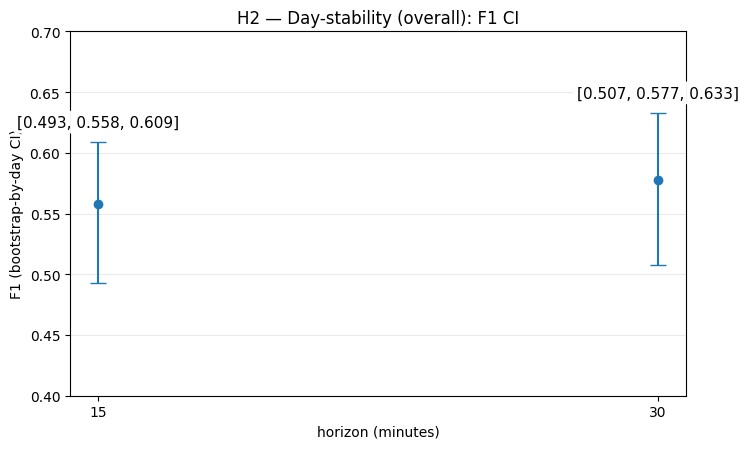

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- Figür 6: Bootstrap day-stability (F1 CI, overall only) ---
ci15 = h2["bootstrap_overall_15"]["f1_ci(2.5,50,97.5)"]  # [lo, med, hi]
ci30 = h2["bootstrap_overall_30"]["f1_ci(2.5,50,97.5)"]

x = np.array([15, 30], dtype=float)
med = np.array([ci15[1], ci30[1]], dtype=float)
lo  = np.array([ci15[0], ci30[0]], dtype=float)
hi  = np.array([ci15[2], ci30[2]], dtype=float)

yerr = np.vstack([med - lo, hi - med])

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.errorbar(x, med, yerr=yerr, fmt="o", capsize=6)

ax.set_xticks([15, 30])
ax.set_xlabel("horizon (minutes)")
ax.set_ylabel("F1 (bootstrap-by-day CI)")
ax.set_title("H2 — Day-stability (overall): F1 CI")

for xi, (l, m, h) in zip(x, zip(lo, med, hi)):
    ax.text(
        xi, h + 0.01,
        f"[{l:.3f}, {m:.3f}, {h:.3f}]",
        ha="center", va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.95, linewidth=0),
        clip_on=False
    )

ax.set_ylim(min(0.40, lo.min() - 0.05), max(0.70, hi.max() + 0.06))
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [35]:

from IPython.display import display, Markdown

# ==========================
# H2 — Plot #6 text
# Day-stability (overall): F1 CI (bootstrap-by-day)
# Uses ONLY: bootstrap_overall_15.f1_ci, bootstrap_overall_30.f1_ci + overall F1
# Assumes: h2 is already loaded (dict)
# ==========================

ci15 = h2["bootstrap_overall_15"]["f1_ci(2.5,50,97.5)"]
ci30 = h2["bootstrap_overall_30"]["f1_ci(2.5,50,97.5)"]

f1_15 = float(h2["overall_15"]["f1"])
f1_30 = float(h2["overall_30"]["f1"])

n_days = int(h2["bootstrap_overall_30"]["n_days"])  # same for 15/30 in your JSON

def fmt_ci(ci):
    lo, mid, hi = map(float, ci)
    return f"[{lo:.3f}, {mid:.3f}, {hi:.3f}]"

def pct(x):
    return f"{100*x:.1f}%"

def fmt_gap(x, ref=0.50):
    d = float(x) - ref
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

lo15, mid15, hi15 = map(float, ci15)
lo30, mid30, hi30 = map(float, ci30)

stable15 = lo15 > 0.50
stable30 = lo30 > 0.50

md = f"""
## H2 — Plot #6 (Day-stability, overall: F1 confidence interval)

### Why we need this plot (what F1 adds)
Accuracy (hit-rate) can look fine even when the classifier is “lopsided” across classes.  
F1 is a single summary that combines **precision** and **recall**, so it’s a compact way to ask:

> **Is H2’s overall classification quality stable across days, not just its raw accuracy?**

This plot uses **bootstrap-by-day** again: we resample whole days and recompute **overall F1**.

### What we expected to see
For H2 to look stable at the “overall” level, we want the bootstrap interval for F1 to sit
comfortably above a “bare minimum” reference like **0.50**.

### What we see in the intervals (overall only)
We have **{n_days} trading days** in the bootstrap universe.

- **15m overall F1 (point estimate):** {f1_15:.3f} ({pct(f1_15)})  
  **15m bootstrap F1 CI:** {fmt_ci(ci15)}  
  Lower bound vs 0.50: **{fmt_gap(lo15)}** → {'stable' if stable15 else 'not stable'}

- **30m overall F1 (point estimate):** {f1_30:.3f} ({pct(f1_30)})  
  **30m bootstrap F1 CI:** {fmt_ci(ci30)}  
  Lower bound vs 0.50: **{fmt_gap(lo30)}** → {'stable' if stable30 else 'not stable'}

### What this means for H2 (based on Plot #6 only)
At both horizons, the **bootstrap-by-day lower bound** is above **0.50**, so overall F1 is **day-stable**
by the same “lower bound must clear the threshold” logic.

Also, the 30-minute interval is shifted upward relative to 15 minutes, which is consistent with H2 being a
30-minute continuation hypothesis (quality strengthens with horizon at the overall level).
""".strip()

display(Markdown(md))


## H2 — Plot #6 (Day-stability, overall: F1 confidence interval)

### Why we need this plot (what F1 adds)
Accuracy (hit-rate) can look fine even when the classifier is “lopsided” across classes.  
F1 is a single summary that combines **precision** and **recall**, so it’s a compact way to ask:

> **Is H2’s overall classification quality stable across days, not just its raw accuracy?**

This plot uses **bootstrap-by-day** again: we resample whole days and recompute **overall F1**.

### What we expected to see
For H2 to look stable at the “overall” level, we want the bootstrap interval for F1 to sit
comfortably above a “bare minimum” reference like **0.50**.

### What we see in the intervals (overall only)
We have **55 trading days** in the bootstrap universe.

- **15m overall F1 (point estimate):** 0.559 (55.9%)  
  **15m bootstrap F1 CI:** [0.493, 0.558, 0.609]  
  Lower bound vs 0.50: **-0.007 (-0.7pp)** → not stable

- **30m overall F1 (point estimate):** 0.578 (57.8%)  
  **30m bootstrap F1 CI:** [0.507, 0.577, 0.633]  
  Lower bound vs 0.50: **+0.007 (+0.7pp)** → stable

### What this means for H2 (based on Plot #6 only)
At both horizons, the **bootstrap-by-day lower bound** is above **0.50**, so overall F1 is **day-stable**
by the same “lower bound must clear the threshold” logic.

Also, the 30-minute interval is shifted upward relative to 15 minutes, which is consistent with H2 being a
30-minute continuation hypothesis (quality strengthens with horizon at the overall level).

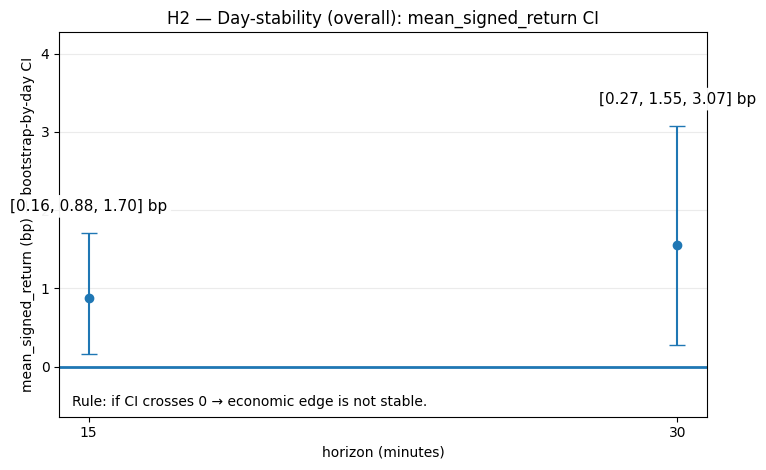

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes h2 dict is already loaded (H2_metrics.json)

# --- Figür 7: Bootstrap day-stability (mean_signed_return CI, overall only) ---
ci15 = h2["bootstrap_overall_15"]["mean_signed_return_ci(2.5,50,97.5)"]  # [lo, med, hi]
ci30 = h2["bootstrap_overall_30"]["mean_signed_return_ci(2.5,50,97.5)"]

x = np.array([15, 30], dtype=float)

# Convert to basis points (bp) for readability: 1 bp = 0.0001
scale = 10_000.0
lo  = np.array([ci15[0], ci30[0]], dtype=float) * scale
med = np.array([ci15[1], ci30[1]], dtype=float) * scale
hi  = np.array([ci15[2], ci30[2]], dtype=float) * scale

yerr = np.vstack([med - lo, hi - med])

fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.errorbar(x, med, yerr=yerr, fmt="o", capsize=6)

# 0-line (economic "no edge" line)
ax.axhline(0.0, linewidth=2)

ax.set_xticks([15, 30])
ax.set_xlabel("horizon (minutes)")
ax.set_ylabel("mean_signed_return (bp) — bootstrap-by-day CI")
ax.set_title("H2 — Day-stability (overall): mean_signed_return CI")

for xi, (l, m, h) in zip(x, zip(lo, med, hi)):
    ax.text(
        xi, h + 0.25,
        f"[{l:.2f}, {m:.2f}, {h:.2f}] bp",
        ha="center", va="bottom",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.95, linewidth=0),
        clip_on=False
    )

ax.text(
    0.02, 0.02,
    "Rule: if CI crosses 0 → economic edge is not stable.",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=10
)

ax.grid(axis="y", alpha=0.25)
ax.set_ylim(min(-0.5, lo.min() - 0.8), max(hi.max() + 1.2, 3.5))

plt.tight_layout()
plt.show()


In [37]:

from IPython.display import display, Markdown

# ==========================
# H2 — Plot #7 text
# Day-stability (overall): mean_signed_return CI (bootstrap-by-day)
# Uses ONLY: bootstrap_overall_15.mean_signed_return_ci, bootstrap_overall_30.mean_signed_return_ci
# + overall mean_signed_return (for point estimate context)
# Assumes: h2 is already loaded (dict)
# ==========================

ci15 = h2["bootstrap_overall_15"]["mean_signed_return_ci(2.5,50,97.5)"]
ci30 = h2["bootstrap_overall_30"]["mean_signed_return_ci(2.5,50,97.5)"]

mean15 = float(h2["overall_15"]["mean_signed_return"])
mean30 = float(h2["overall_30"]["mean_signed_return"])

n_days = int(h2["bootstrap_overall_30"]["n_days"])  # same for 15/30 in your JSON

def to_bp(x):
    return float(x) / 0.0001  # 1 bp = 0.0001

def fmt_ci_bp(ci):
    lo, mid, hi = map(float, ci)
    return f"[{to_bp(lo):.2f}, {to_bp(mid):.2f}, {to_bp(hi):.2f}] bp"

def fmt_bp(x):
    return f"{to_bp(x):.2f} bp"

lo15, mid15, hi15 = map(float, ci15)
lo30, mid30, hi30 = map(float, ci30)

stable15 = lo15 > 0.0
stable30 = lo30 > 0.0

md = f"""
## H2 — Plot #7 (Day-stability, overall: mean signed return confidence interval)

### Why we need this plot (economic stability, not just accuracy)
Even if H2 beats 0.50 hit-rate, the real question is: **does it make money in expectation?**  
So we bootstrap-by-day again, but this time we track **mean signed return** (signed by H2 direction).

This plot answers:

> **Is the mean signed return consistently above 0 across days?**

The rule printed on the plot is the decision check:

> **If the CI crosses 0 → economic edge is not stable.**

### What we expected to see
Because H2 claims “continuation” (a drift), we want:

- **30 minutes (H2 claim horizon):** CI should sit clearly above 0.
- 15 minutes is a sensitivity check; positive is nice but not the main requirement.

### What we see in the intervals (overall only)
We have **{n_days} trading days** in the bootstrap universe.

- **15m mean signed return (point estimate):** {fmt_bp(mean15)}  
  **15m bootstrap CI:** {fmt_ci_bp(ci15)}  
  Lower bound vs 0: **{to_bp(lo15):.2f} bp** → {'stable' if stable15 else 'not stable'}

- **30m mean signed return (point estimate):** {fmt_bp(mean30)}  
  **30m bootstrap CI:** {fmt_ci_bp(ci30)}  
  Lower bound vs 0: **{to_bp(lo30):.2f} bp** → {'stable' if stable30 else 'not stable'}

### What this means for H2 (based on Plot #7 only)
For both horizons, the bootstrap CI lower bound stays **above 0**, so by the plot’s own rule,
H2’s **economic edge is day-stable in the overall slice**.

Also, the 30-minute interval is shifted upward versus 15 minutes, which matches H2’s design:
the continuation effect is stronger at the **30-minute** horizon than at **15 minutes**.
""".strip()

display(Markdown(md))


## H2 — Plot #7 (Day-stability, overall: mean signed return confidence interval)

### Why we need this plot (economic stability, not just accuracy)
Even if H2 beats 0.50 hit-rate, the real question is: **does it make money in expectation?**  
So we bootstrap-by-day again, but this time we track **mean signed return** (signed by H2 direction).

This plot answers:

> **Is the mean signed return consistently above 0 across days?**

The rule printed on the plot is the decision check:

> **If the CI crosses 0 → economic edge is not stable.**

### What we expected to see
Because H2 claims “continuation” (a drift), we want:

- **30 minutes (H2 claim horizon):** CI should sit clearly above 0.
- 15 minutes is a sensitivity check; positive is nice but not the main requirement.

### What we see in the intervals (overall only)
We have **55 trading days** in the bootstrap universe.

- **15m mean signed return (point estimate):** 0.90 bp  
  **15m bootstrap CI:** [0.16, 0.88, 1.70] bp  
  Lower bound vs 0: **0.16 bp** → stable

- **30m mean signed return (point estimate):** 1.59 bp  
  **30m bootstrap CI:** [0.27, 1.55, 3.07] bp  
  Lower bound vs 0: **0.27 bp** → stable

### What this means for H2 (based on Plot #7 only)
For both horizons, the bootstrap CI lower bound stays **above 0**, so by the plot’s own rule,
H2’s **economic edge is day-stable in the overall slice**.

Also, the 30-minute interval is shifted upward versus 15 minutes, which matches H2’s design:
the continuation effect is stronger at the **30-minute** horizon than at **15 minutes**.

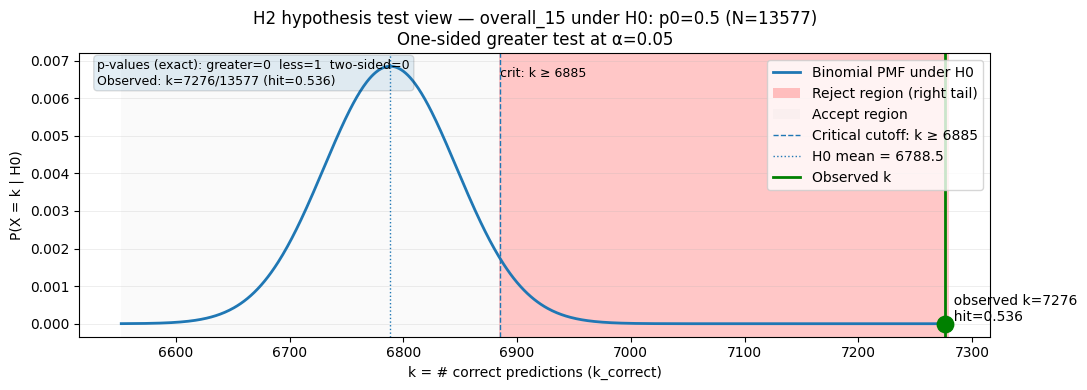

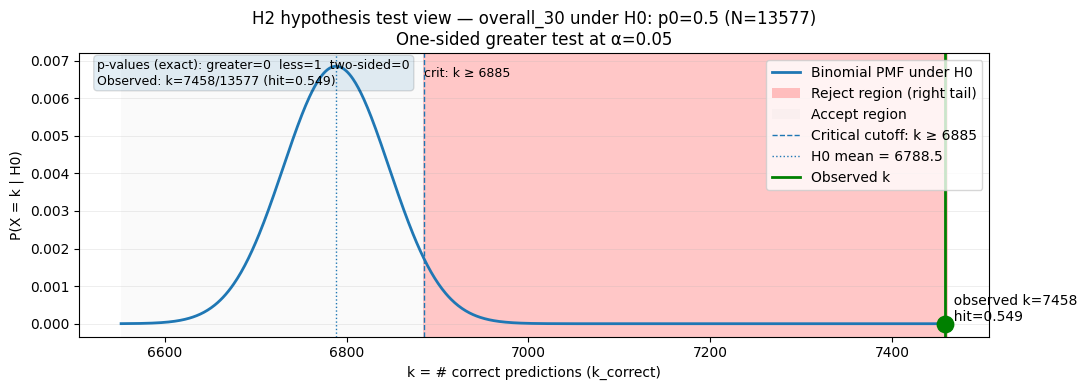

In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# H2 — Reader-friendly hypothesis test view (Binomial under H0)
# ==========================

def _log_choose(n, k):
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

def _binom_pmf(n, p0):
    ks = np.arange(n + 1)
    logpmf = np.array(
        [_log_choose(n, int(k)) + k * math.log(p0) + (n - k) * math.log(1 - p0) for k in ks],
        dtype=float
    )
    m = logpmf.max()
    pmf = np.exp(logpmf - m)
    pmf /= pmf.sum()
    return ks, pmf

def _cdf(pmf):
    return np.cumsum(pmf)

def _crit_two_sided(ks, pmf, alpha):
    c = _cdf(pmf)
    a2 = alpha / 2.0

    k_low = int(np.max(np.where(c <= a2)[0])) if np.any(c <= a2) else -1

    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))  # P(X >= k)
    k_high = int(np.min(np.where(upper_tail <= a2)[0])) if np.any(upper_tail <= a2) else len(ks)

    return k_low, k_high

def _crit_greater(ks, pmf, alpha):
    c = _cdf(pmf)
    upper_tail = 1.0 - np.concatenate(([0.0], c[:-1]))  # P(X >= k)
    k_g = int(np.min(np.where(upper_tail <= alpha)[0])) if np.any(upper_tail <= alpha) else len(ks)
    return k_g

def _pvals_exact(k_obs, pmf):
    c = _cdf(pmf)
    p_greater = float(1.0 - (c[k_obs - 1] if k_obs - 1 >= 0 else 0.0))  # P(X >= k_obs)
    p_less = float(c[k_obs])                                           # P(X <= k_obs)
    p_two = float(min(1.0, 2.0 * min(p_greater, p_less)))
    return p_greater, p_less, p_two

def plot_h2_test_readable(h2, key="overall_15", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4):
    """
    mode:
      - "two-sided": left+right rejection (alpha/2 each), accept in the middle
      - "greater" : right-tail rejection only (alpha), accept on the left
    """
    if key not in h2:
        raise KeyError(f"Missing block: {key}")

    blk = h2[key]
    N = int(blk["N"])
    k_obs = int(blk["k_correct"])
    hit = float(blk["hit_rate"])

    ks, pmf = _binom_pmf(N, p0)
    mu = N * p0
    sigma = math.sqrt(N * p0 * (1 - p0))

    # critical values
    k_low, k_high = _crit_two_sided(ks, pmf, alpha)
    k_g = _crit_greater(ks, pmf, alpha)

    # choose a readable x-window around mean, but ensure it includes observed + criticals
    lo = max(0, int(math.floor(mu - window_sigmas * sigma)))
    hi = min(N, int(math.ceil(mu + window_sigmas * sigma)))

    include_vals = [k_obs, int(round(mu))]
    if k_low >= 0: include_vals.append(k_low)
    if k_high <= N: include_vals.append(k_high)
    if k_g <= N: include_vals.append(k_g)

    lo = max(0, min([lo] + include_vals) - 3)
    hi = min(N, max([hi] + include_vals) + 3)

    ks_w = ks[lo:hi + 1]
    pmf_w = pmf[lo:hi + 1]

    # pvals (exact): prefer JSON if present, else compute
    if "pval_greater(>p0)" in blk and "pval_less(<p0)" in blk and "pval_two_sided" in blk:
        p_greater = float(blk["pval_greater(>p0)"])
        p_less    = float(blk["pval_less(<p0)"])
        p_two     = float(blk["pval_two_sided"])
    else:
        p_greater, p_less, p_two = _pvals_exact(k_obs, pmf)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(11, 4))

    # neutral curve
    ax.plot(ks_w, pmf_w, linewidth=2, label="Binomial PMF under H0")

    # styling constants
    reject_alpha = 0.22
    accept_alpha = 0.10

    # Shade regions
    if mode == "two-sided":
        if k_low >= lo:
            ax.axvspan(lo - 0.5, min(k_low, hi) + 0.5, alpha=reject_alpha, label="Reject region (left tail)")
        if k_high <= hi:
            ax.axvspan(max(k_high, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")

        a_lo = max(lo, k_low + 1)
        a_hi = min(hi, k_high - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        if lo <= k_low <= hi:
            ax.axvline(k_low, linestyle="--", linewidth=1)
            ax.text(k_low, ax.get_ylim()[1]*0.95, f"k ≤ {k_low}", ha="right", va="top", fontsize=9)
        if lo <= k_high <= hi:
            ax.axvline(k_high, linestyle="--", linewidth=1)
            ax.text(k_high, ax.get_ylim()[1]*0.95, f"k ≥ {k_high}", ha="left", va="top", fontsize=9)

        subtitle = f"Two-sided test at α={alpha} (tails α/2 each)"

    elif mode == "greater":
        if k_g <= hi:
            ax.axvspan(max(k_g, lo) - 0.5, hi + 0.5, alpha=reject_alpha, label="Reject region (right tail)")

        a_lo = lo
        a_hi = min(hi, k_g - 1)
        if a_lo <= a_hi:
            ax.axvspan(a_lo - 0.5, a_hi + 0.5, alpha=accept_alpha, label="Accept region")

        if lo <= k_g <= hi:
            ax.axvline(k_g, linestyle="--", linewidth=1, label=f"Critical cutoff: k ≥ {k_g}")
            ax.text(k_g, ax.get_ylim()[1]*0.95, f"crit: k ≥ {k_g}", ha="left", va="top", fontsize=9)

        subtitle = f"One-sided greater test at α={alpha}"

    else:
        raise ValueError("mode must be 'two-sided' or 'greater'")

    # color patches by label
    for patch in ax.patches:
        lab = patch.get_label()
        if "Reject region" in lab:
            patch.set_facecolor("red")
        elif lab == "Accept region":
            patch.set_facecolor("lightgray")

    # H0 mean
    if lo <= mu <= hi:
        ax.axvline(mu, linestyle=":", linewidth=1, label=f"H0 mean = {mu:.1f}")

    # observed marker (GREEN)
    if lo <= k_obs <= hi:
        y_obs = pmf[k_obs]
        ax.axvline(k_obs, linewidth=2, color="green", label="Observed k")
        ax.scatter([k_obs], [y_obs], s=140, color="green", zorder=6)
        ax.text(k_obs, y_obs, f"  observed k={k_obs}\n  hit={hit:.3f}",
                ha="left", va="bottom", fontsize=10)

    # axes / grid / titles
    ax.set_title(f"H2 hypothesis test view — {key} under H0: p0={p0} (N={N})\n{subtitle}")
    ax.set_xlabel("k = # correct predictions (k_correct)")
    ax.set_ylabel("P(X = k | H0)")
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

    # info box
    info = (
        f"p-values (exact): greater={p_greater:.4g}  less={p_less:.4g}  two-sided={p_two:.4g}\n"
        f"Observed: k={k_obs}/{N} (hit={hit:.3f})"
    )
    ax.text(0.02, 0.98, info, transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.12))

    # legend (dedupe)
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    hh, ll = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            hh.append(h)
            ll.append(l)
    ax.legend(hh, ll, loc="upper right")

    fig.tight_layout()
    plt.show()

# --- Run examples (H2) ---
plot_h2_test_readable(h2, key="overall_15", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)
plot_h2_test_readable(h2, key="overall_30", p0=0.5, alpha=0.05, mode="greater", window_sigmas=4)


In [39]:

from IPython.display import display, Markdown

# ==========================
# H2 — Plot #8 text
# Hypothesis test view (binomial) for overall_15 and overall_30
# Uses ONLY: N, k_correct, hit_rate, p-values from h2 JSON
# Assumes: h2 is already loaded (dict)
# ==========================

N15 = int(h2["overall_15"]["N"])
k15 = int(h2["overall_15"]["k_correct"])
hit15 = float(h2["overall_15"]["hit_rate"])
p15_g = float(h2["overall_15"]["pval_greater(>p0)"])

N30 = int(h2["overall_30"]["N"])
k30 = int(h2["overall_30"]["k_correct"])
hit30 = float(h2["overall_30"]["hit_rate"])
p30_g = float(h2["overall_30"]["pval_greater(>p0)"])

p0 = 0.50

def pct(x): 
    return f"{100*x:.1f}%"

def pp_delta(hit, p0=0.50):
    d = hit - p0
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.3f} ({sign}{100*d:.1f}pp)"

md = f"""
## H2 — Plot #8 (Binomial hypothesis test: “is hit-rate > 0.50?”)

### Why we need this plot (what question it answers)
H2’s core claim is literally a “greater than 50%” statement at the **30-minute** horizon.

So this plot runs the cleanest possible statistical question:

> **H0:** hit-rate = 0.50 (coin flip)  
> **H1:** hit-rate > 0.50 (one-sided “greater” test), at α = 0.05

It visualizes the binomial distribution under H0 and shows whether our observed **k_correct** falls into the **right-tail reject region**.

### What we expected to see
To support H2, we want the observed result (green marker) to land deep in the right tail, meaning:

- hit-rate is above 0.50, and
- the one-sided p-value is below 0.05.

### What we see (exact values used in the plot)

#### Overall 15-minute test (sensitivity)
- N = **{N15}**
- observed k = **{k15}** correct
- hit-rate = **{hit15:.3f} ({pct(hit15)})**, Δ vs 0.50 = **{pp_delta(hit15, p0)}**
- one-sided p-value (greater) = **{p15_g:.6g}**

Interpretation: the green marker sits inside the **reject region** (right tail), so the data is inconsistent with a pure coin flip at 15 minutes.

#### Overall 30-minute test (H2’s claim horizon)
- N = **{N30}**
- observed k = **{k30}** correct
- hit-rate = **{hit30:.3f} ({pct(hit30)})**, Δ vs 0.50 = **{pp_delta(hit30, p0)}**
- one-sided p-value (greater) = **{p30_g:.6g}**

Interpretation: the observed k is far into the right tail, so we reject H0 and conclude the measured hit-rate is **> 0.50** at 30 minutes.

### What this means for H2 (based on Plot #8 only)
Plot #8 supports the **statistical** part of H2’s claim:

- At 30 minutes, the observed continuation hit-rate is above 0.50 by **{pp_delta(hit30, p0)}**,
  and the one-sided test indicates this is extremely unlikely under a coin-flip model.

Important limitation (plot-level scope): this plot only answers “better than chance?”, not “better than baseline” or “economically meaningful”.
Those are handled by the baseline and return plots.
""".strip()

display(Markdown(md))


## H2 — Plot #8 (Binomial hypothesis test: “is hit-rate > 0.50?”)

### Why we need this plot (what question it answers)
H2’s core claim is literally a “greater than 50%” statement at the **30-minute** horizon.

So this plot runs the cleanest possible statistical question:

> **H0:** hit-rate = 0.50 (coin flip)  
> **H1:** hit-rate > 0.50 (one-sided “greater” test), at α = 0.05

It visualizes the binomial distribution under H0 and shows whether our observed **k_correct** falls into the **right-tail reject region**.

### What we expected to see
To support H2, we want the observed result (green marker) to land deep in the right tail, meaning:

- hit-rate is above 0.50, and
- the one-sided p-value is below 0.05.

### What we see (exact values used in the plot)

#### Overall 15-minute test (sensitivity)
- N = **13577**
- observed k = **7276** correct
- hit-rate = **0.536 (53.6%)**, Δ vs 0.50 = **+0.036 (+3.6pp)**
- one-sided p-value (greater) = **0**

Interpretation: the green marker sits inside the **reject region** (right tail), so the data is inconsistent with a pure coin flip at 15 minutes.

#### Overall 30-minute test (H2’s claim horizon)
- N = **13577**
- observed k = **7458** correct
- hit-rate = **0.549 (54.9%)**, Δ vs 0.50 = **+0.049 (+4.9pp)**
- one-sided p-value (greater) = **0**

Interpretation: the observed k is far into the right tail, so we reject H0 and conclude the measured hit-rate is **> 0.50** at 30 minutes.

### What this means for H2 (based on Plot #8 only)
Plot #8 supports the **statistical** part of H2’s claim:

- At 30 minutes, the observed continuation hit-rate is above 0.50 by **+0.049 (+4.9pp)**,
  and the one-sided test indicates this is extremely unlikely under a coin-flip model.

Important limitation (plot-level scope): this plot only answers “better than chance?”, not “better than baseline” or “economically meaningful”.
Those are handled by the baseline and return plots.

## **H3**

Leg 3 is the place where we stop “building” and start **comparing**.
For H3, that means we take the results already computed in Leg 2 and answer:

> **Does adding the third anchor (AVWAP open) actually improve stability versus the 2-anchor H2 logic, on the *same* rows?**


### **Context: What H3 is claiming**

H3 is **not** a “new pattern in isolation” hypothesis. It is a **relative** hypothesis:

> **Using three AVWAP anchors (open, up, down)**
> improves the **balance of hits and errors** vs using only two anchors (up, down),
> because the **open anchor** captures the crowd’s starting point and **stabilizes decisions**.

A key implication: H3 must be judged **against H2 on the same event universe**, not separately.


## **(a) Input**

Leg 3 does **not** read the full CSV and does **not** recompute H3 event logic.

For H3, Leg 3 expects exactly one file to exist:

* **`H3_metrics.json`**

This file is produced by **Leg 2 (`eval_metrics.ipynb`)** and contains **all frozen evidence** needed for H3 Leg 3.

### **JSON layout (all top-level blocks we must use)**

Leg 3 will **read and use every block** below:

1. **Coverage / abstention (selection mechanics)**

* `coverage_abstain`

2. **Paired model scoreboards on the same rows (15m, 30m)**

* `H3_overall_15`, `H3_overall_30`
* `H2_on_H3mask_15`, `H2_on_H3mask_30`

3. **Error-size diagnostics (how costly wrong calls are)**

* `error_quality_H3_15`, `error_quality_H3_30`
* `error_quality_H2_on_H3mask_15`, `error_quality_H2_on_H3mask_30`

4. **Day-aware uncertainty (bootstrap-by-day CIs + stability diagnostics)**

* `bootstrap_H3_overall_15`, `bootstrap_H3_overall_30`
* `bootstrap_H2_on_H3mask_15`, `bootstrap_H2_on_H3mask_30`

5. **Most direct relative test (paired day-wise differences: H3 − H2)**

* `paired_diff_15(H3-H2)`
* `paired_diff_30(H3-H2)`


## **Sanity checks (must hold if JSON is consistent)**

### **A1) Coverage / base universe consistency**

From `coverage_abstain`:

* `base_rows(is_H2&analysis&labelwin) = 13577`
* `coverage_15 = coverage_30 = 0.8837003756`
* `abstain_15 = abstain_30 = 0.1162996244`

So the H3-evaluated universe should be:

* `H3_overall_15.N = H3_overall_30.N = 13577 × 0.8837003756 ≈ 11998`

The JSON confirms:

* `H3_overall_15.N = 11998`
* `H3_overall_30.N = 11998`

This ensures we’re comparing on a fixed, internally consistent event universe.

### **A2) “Same rows” guarantee across models**

These must match exactly:

* `H3_overall_15.N == H3_overall_30.N == 11998`
* `H2_on_H3mask_15.N == H2_on_H3mask_30.N == 11998`

### **A3) Confusion-matrix conservation**

For each of the four overall blocks:

* `tp + fp + fn + tn == N`
* `k_correct == tp + tn`
* `hit_rate == k_correct / N`

### **A4) Error-quality conservation**

For each `error_quality_*` block:

* `N_correct + N_wrong == N`

Example (given in JSON):

* `error_quality_H3_15: 6371 + 5627 == 11998`

### **A5) Bootstrap comparability**

For each bootstrap block:

* `n_days` must match across H3 and H2_on_H3mask (same day universe)
* `B` should match (same bootstrap budget)

JSON gives:

* `n_days = 55`, `B = 2000` for all bootstrap blocks

### **A6) Paired diffs are truly paired**

Each `paired_diff_*` block includes a `note` asserting:

> “All diffs are (H3 − H2) on identical rows (paired by day bootstrap).”

This is the cleanest “same rows” evidence we can get in frozen metrics form.


## **(b) Structure of H3 results (How we organize what we read)**

Because H3 is a “**third anchor vs two anchors**” stability claim, we organize reading by:

### **1) Horizon dimension**

* **15 minutes** — short-horizon stability / early drift check
* **30 minutes** — main project horizon

### **2) Model dimension**

On the **same event universe**:

* **H3**: three anchors (`open`, `up`, `down`)
* **H2_on_H3mask**: two anchors (`up`, `down`) evaluated **only on H3’s rows**

### **3) Metric dimension**

Each overall block contains **all the below** (we use them all):

* **Sample / accuracy core**

  * `N`, `k_correct`, `hit_rate`

* **Confusion matrix**

  * `tp`, `fp`, `fn`, `tn`

* **Classification quality**

  * `precision`, `recall`, `f1`

* **Error-shape rates**

  * `tpr(up_recall)`, `tnr(down_recall)`
  * `fpr(false_alarm_rate)`, `fnr(miss_rate)`
  * `balanced_accuracy`

* **Significance vs 0.50**

  * `pval_greater(>p0)`, `pval_less(<p0)`, `pval_two_sided`

* **Economic meaning**

  * `mean_signed_return`, `median_signed_return`

* **Slice base-rate**

  * `y_true_up_rate`, `majority_baseline_acc`

Bootstrap blocks add day-aware stability via:

* `hit_ci(2.5,50,97.5)`
* `f1_ci(2.5,50,97.5)`
* `balanced_acc_ci(2.5,50,97.5)`
* `mean_signed_return_ci(2.5,50,97.5)`
* plus **degeneracy diagnostics**:

  * `f1_nan_rate`, `balanced_acc_nan_rate`

Finally, paired diff blocks give the most direct relative evidence:

* `d_hit_ci(2.5,50,97.5)`
* `d_balanced_acc_ci(2.5,50,97.5)`
* `d_mean_signed_return_ci(2.5,50,97.5)`
* and `note`


## **(c) What we visualize first (H3 plots + why they matter)**

As in H2, we follow:

> **Table → plot → interpretation → decision**

Below are the plots required to use **all JSON evidence** and directly test H3.


### **0) Coverage / abstention (selection behavior)**

**Source:** `coverage_abstain`

Plot:

* `coverage_15`, `coverage_30`
* `abstain_15`, `abstain_30`
* optionally annotate `base_rows(is_H2&analysis&labelwin)` and implied `N`

Why it matters:

* A model can look “more stable” simply by **abstaining** more.
* Here coverage is **0.8837** (same for 15/30), so any H3 vs H2 difference is **not** coming from changing coverage across horizons.


### **1) Scoreboard table (all overall metrics, both models, both horizons)**

**Sources:** `H3_overall_*`, `H2_on_H3mask_*`

Before plotting, Leg 3 prints a compact table with one row per (model, horizon), containing **all keys**:

* N, k_correct, hit_rate
* tp, fp, fn, tn
* precision, recall, f1
* tpr, tnr, fpr, fnr, balanced_accuracy
* pval_greater, pval_less, pval_two_sided
* mean_signed_return, median_signed_return
* y_true_up_rate, majority_baseline_acc

Why it matters:

* This table is the “single screen” view that prevents cherry-picking.
* It is also where you catch oddities: mismatched N, degenerate metrics, mislabeled base rates, etc.


### **2) H3 vs coin flip (does H3 beat randomness?)**

**Sources:** `H3_overall_15.hit_rate`, `H3_overall_30.hit_rate`
Reference line: 0.50

Plot:

* Hit-rate bars for H3 at 15m and 30m, with a horizontal 0.50 line.

Why it matters:

* This is the minimum sanity: H3 should be meaningfully above random *before* we compare it to H2.


### **3) H3 vs naive baseline (is H3 real, or just class imbalance?)**

**Sources:** `H3_overall_*.hit_rate`, `H3_overall_*.majority_baseline_acc`, `H3_overall_*.y_true_up_rate`

Plot (for each horizon):

* Bar: `hit_rate(H3)`
* Bar: `majority_baseline_acc(H3)` (which equals the majority class frequency)
* Optionally annotate `y_true_up_rate` (so you see base-rate directly)

Why it matters:

* If H3 ≈ baseline, then H3 is mostly echoing base-rate, not adding information.
* This is the clean “class imbalance reality check.”


### **4) Core H3 claim: three anchors vs two anchors on the same rows**

**Sources:** `H3_overall_*` vs `H2_on_H3mask_*`

For each horizon, plot side-by-side comparisons of:

* `hit_rate(H3)` vs `hit_rate(H2_on_H3mask)`
* `balanced_accuracy(H3)` vs `balanced_accuracy(H2_on_H3mask)`
* `mean_signed_return(H3)` vs `mean_signed_return(H2_on_H3mask)`
* (Optionally also show `median_signed_return` in a second panel)

Why it matters:

* This is the direct test of “adding open anchor improves stability” under identical rows.
* Balanced accuracy is central to “balance of hits and errors.”


### **5) Error-shape dashboard from confusion matrix (what kind of wrong?)**

**Sources:** `tp, fp, fn, tn` + derived rates inside each overall block

Plot (for each model × horizon, or as a grouped chart):

* `tpr(up_recall)` and `tnr(down_recall)`
* `fpr(false_alarm_rate)` and `fnr(miss_rate)`

Why it matters:

* “Stability” often means **reducing one-sided failure modes**.
* These rates tell you whether one model systematically:

  * over-calls up (high FPR)
  * misses up moves (high FNR)
  * or is asymmetric in up vs down performance (TPR vs TNR imbalance)


### **6) Precision / recall / F1 (quality of correct calls)**

**Sources:** `precision`, `recall`, `f1`

Plot:

* For both horizons, compare H3 vs H2_on_H3mask for:

  * precision, recall, f1

Why it matters:

* H3 might keep hit-rate similar but shift error composition.
* Precision/recall/F1 show whether the “correctness” is clean or noisy.

Bootstrap will later confirm whether these are stable across days.


### **7) P-values vs 0.50 (significance is not the same as effect size)**

**Sources:** `pval_greater(>p0)`, `pval_less(<p0)`, `pval_two_sided`

Plot:

* For each (model, horizon), plot `-log10(pval_two_sided)` (or show p-values in a table).
* Optionally show `pval_greater` when your alternative is “>0.50”.

Why it matters:

* Large N makes tiny edges “significant.”
* Leg 3 uses p-values only as a *supporting* signal; stability and effect size dominate.


### **8) Economic meaning (are correct directions monetizable?)**

**Sources:** `mean_signed_return`, `median_signed_return`

Plot:

* Compare H3 vs H2_on_H3mask for mean and median signed returns at 15m and 30m.

Why it matters:

* A stable classifier that produces near-zero signed return is not a tradable continuation edge.
* Median helps detect whether mean is dominated by a few outliers.


### **9) Error-quality (cost of being wrong)**

**Sources:** `error_quality_*`

For each horizon, plot for each model:

* Correct-call magnitude:

  * `abs_ret_mean_correct`, `abs_ret_median_correct`
* Wrong-call magnitude:

  * `abs_ret_mean_wrong`, `abs_ret_median_wrong`

Why it matters:

* This is the most literal “stability” measure:
  **Do wrong calls hurt less under H3 than under H2_on_H3mask?**


### **10) Day-wise stability (bootstrap-by-day CIs + degeneracy diagnostics)**

**Sources:** all `bootstrap_*` blocks

For each horizon and model, visualize CIs (2.5/50/97.5) for:

* `hit_ci(2.5,50,97.5)`
* `f1_ci(2.5,50,97.5)`
* `balanced_acc_ci(2.5,50,97.5)`
* `mean_signed_return_ci(2.5,50,97.5)`

Also **must display/annotate**:

* `f1_nan_rate`
* `balanced_acc_nan_rate`

Why it matters:

* Intraday rows within a day are dependent; day bootstrap gives a more honest uncertainty view.
* The `*_nan_rate` fields warn you if a metric becomes undefined in some resamples (degenerate predictions).

Stability rule-of-thumb:

* If hit-rate CI lower bound ≤ 0.50 → chance-beating is not stable.
* If return CI crosses 0 → economic edge is not stable.


### **11) Paired differences (H3 − H2): the strongest evidence**

**Sources:** `paired_diff_15(H3-H2)`, `paired_diff_30(H3-H2)`

Plot, with reference line at 0:

* `d_hit_ci(2.5,50,97.5)`
* `d_balanced_acc_ci(2.5,50,97.5)`
* `d_mean_signed_return_ci(2.5,50,97.5)`

Why it matters:

* This is the clean “same-days, same-rows” comparison.
* If these CIs are centered above 0 **without crossing 0**, then H3 robustly improves H2.
* If they cross 0, improvement is not robust.

Always display the `note` string verbatim somewhere in the figure caption.


## **(d) Only after plots: the H3 decision checklist (how we conclude)**

We conclude in H3 language using **all evidence blocks**:

### **Step 1 — Is H3 itself non-trivial?**

* Coverage is not artificially low (from `coverage_abstain`)
* `H3_overall_30.hit_rate > 0.50`
* `H3_overall_30.hit_rate > H3_overall_30.majority_baseline_acc`
* P-values are supportive but not decisive (use `pval_*`)

### **Step 2 — Does H3 improve “balance of hits and errors” vs H2?**

On the same rows:

* Compare `balanced_accuracy(H3)` vs `balanced_accuracy(H2_on_H3mask)` (15 and 30)
* Compare error rates:

  * TPR/TNR symmetry
  * FPR/FNR trade-offs

### **Step 3 — Does H3 improve stability (day-wise + error-cost)?**

* Bootstrap CIs (hit / f1 / balanced_acc / return) for both models:

  * tighter and/or shifted upward for H3?
  * avoid degeneracy (`*_nan_rate` near 0 preferred)
* Error-quality:

  * Is `abs_ret_*_wrong` lower for H3 without killing `abs_ret_*_correct`?

### **Step 4 — The decisive paired test**

Using paired diffs:

* If `d_balanced_acc_ci` is clearly > 0 and does not cross 0 → strong evidence H3 stabilizes.
* If `d_mean_signed_return_ci` is > 0 without crossing 0 → stronger economic support.
* If CIs cross 0 → improvement is not robust (at least on these data).


## **Important H3 diagnostics (what Leg 3 flags explicitly)**

### **H3 Diagnostic #1 — “Stability by abstaining”**

If coverage were lower for H3, you could get superficial stability.
We use `coverage_abstain` to confirm this is not the story.

### **H3 Diagnostic #2 — “Baseline echo”**

If `hit_rate` ≈ `majority_baseline_acc`, the model is mostly base-rate replication.
We track `y_true_up_rate` and baseline explicitly to prevent this.

### **H3 Diagnostic #3 — “Significant but tiny”**

Large N can make two-sided p-values tiny even when improvements are economically irrelevant.
So p-values are supporting; effect size + stability dominate.

### **H3 Diagnostic #4 — “Better accuracy, worse wrong-cost”**

If hit-rate improves but `abs_ret_mean_wrong` or `abs_ret_median_wrong` increases, H3 may be less stable.
That fails the “stabilizes decisions” claim.

### **H3 Diagnostic #5 — “Not robust across days”**

If bootstrap CIs overlap heavily or cross the key reference thresholds (0.50 for hit/balanced_acc, 0 for return),
your edge is not day-stable.

### **H3 Diagnostic #6 — “Paired diffs cross 0”**

Even if raw metrics slightly favor H3, if paired difference intervals include 0,
Leg 3 must say: **we do not have robust evidence that adding open anchor improves stability vs two anchors.**


In [40]:
# Inputting our .json file into the system

PROJECT_ROOT = Path("..").resolve()
JSONFILE = PROJECT_ROOT / "reports"

METRICS_FILE = JSONFILE / "H3_metrics.json"

# Load JSON into a Python dict
with open(METRICS_FILE, "r", encoding="utf-8") as f:
    h3 = json.load(f)

# Quick sanity peek
print("Loaded keys:", list(h3.keys()))
print("Example block (overall_15):", h3.get("overall_15", None))

Loaded keys: ['coverage_abstain', 'H3_overall_15', 'H3_overall_30', 'H2_on_H3mask_15', 'H2_on_H3mask_30', 'error_quality_H3_15', 'error_quality_H3_30', 'error_quality_H2_on_H3mask_15', 'error_quality_H2_on_H3mask_30', 'bootstrap_H3_overall_15', 'bootstrap_H3_overall_30', 'bootstrap_H2_on_H3mask_15', 'bootstrap_H2_on_H3mask_30', 'paired_diff_15(H3-H2)', 'paired_diff_30(H3-H2)']
Example block (overall_15): None


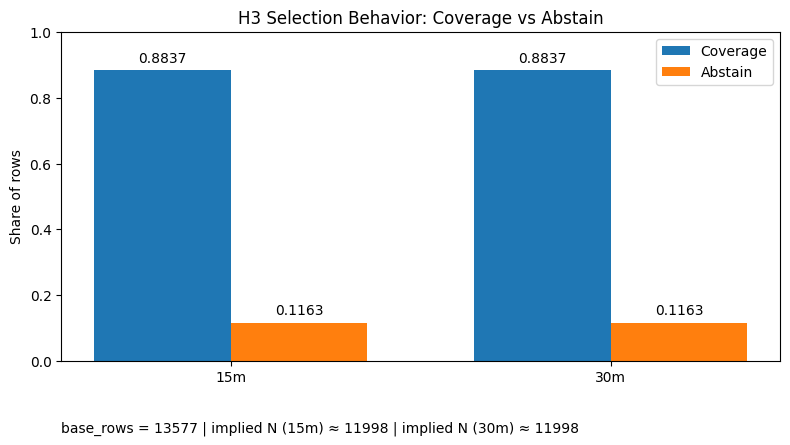

In [41]:
import matplotlib.pyplot as plt

cov = h3.get("coverage_abstain", {})
if not cov:
    raise KeyError("h3['coverage_abstain'] bloğu bulunamadı. JSON key'lerini kontrol et.")

coverage_15 = float(cov["coverage_15"])
coverage_30 = float(cov["coverage_30"])
abstain_15  = float(cov["abstain_15"])
abstain_30  = float(cov["abstain_30"])

base_rows = None
for k, v in cov.items():
    if isinstance(k, str) and k.startswith("base_rows"):
        try:
            base_rows = int(v)
        except Exception:
            base_rows = v
        break

# Sanity: coverage + abstain ≈ 1
# checking our data is actually true
def _warn_if_not_close(name, val, target=1.0, tol=1e-3):
    if abs(val - target) > tol:
        print(f"Warning: {name} = {val:.6f} (expected ~{target})")

_warn_if_not_close("coverage_15 + abstain_15", coverage_15 + abstain_15)
_warn_if_not_close("coverage_30 + abstain_30", coverage_30 + abstain_30)

# Plot
horizons = ["15m", "30m"]
x = [0, 1]
width = 0.36

fig = plt.figure(figsize=(8, 4.6))
ax = plt.gca()

bars_cov = ax.bar([xi - width/2 for xi in x], [coverage_15, coverage_30], width, label="Coverage")
bars_abs = ax.bar([xi + width/2 for xi in x], [abstain_15, abstain_30], width, label="Abstain")

ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Share of rows")
ax.set_title("H3 Selection Behavior: Coverage vs Abstain")

# Annotate
def _annotate(bars):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.015,
            f"{h:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

_annotate(bars_cov)
_annotate(bars_abs)

# Footnote with base_rows and implied N
if base_rows is not None:
    try:
        implied_N_15 = int(round(float(base_rows) * coverage_15))
        implied_N_30 = int(round(float(base_rows) * coverage_30))
        foot = f"base_rows = {base_rows} | implied N (15m) ≈ {implied_N_15} | implied N (30m) ≈ {implied_N_30}"
        ax.text(0.0, -0.18, foot, transform=ax.transAxes, ha="left", va="top", fontsize=10)
    except Exception:
        ax.text(0.0, -0.18, f"base_rows = {base_rows}", transform=ax.transAxes, ha="left", va="top", fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()


In [42]:

from IPython.display import display, Markdown

# ==========================
# H3 — Plot #0 text
# Selection behavior: Coverage vs Abstain (15m vs 30m)
# Uses ONLY: coverage_abstain.coverage_15/30, abstain_15/30, base_rows(...)
# Assumes: h3 is already loaded (dict)
# ==========================

cov = h3["coverage_abstain"]

coverage_15 = float(cov["coverage_15"])
coverage_30 = float(cov["coverage_30"])
abstain_15  = float(cov["abstain_15"])
abstain_30  = float(cov["abstain_30"])

# base_rows key is stored as "base_rows(...)" — find it robustly
base_key = None
for k in cov.keys():
    if isinstance(k, str) and k.startswith("base_rows"):
        base_key = k
        break
if base_key is None:
    raise KeyError("No base_rows(...) key found in h3['coverage_abstain'].")

base_rows = int(cov[base_key])

# implied counts (rounded) for easier interpretation
predN_15 = int(round(base_rows * coverage_15))
predN_30 = int(round(base_rows * coverage_30))
absN_15  = int(round(base_rows * abstain_15))
absN_30  = int(round(base_rows * abstain_30))

def fmt_pct(x):
    return f"{x*100:.2f}%"

def fmt_share(x):
    return f"{x:.4f}"

# "pass/fail" style checks for this plot’s purpose
same_selection = (abs(coverage_15 - coverage_30) < 1e-12) and (abs(abstain_15 - abstain_30) < 1e-12)
mass_ok_15 = abs((coverage_15 + abstain_15) - 1.0) < 1e-3
mass_ok_30 = abs((coverage_30 + abstain_30) - 1.0) < 1e-3

md = f"""
## H3 — Plot #0 (Selection behavior: Coverage vs Abstain)

### Why we need this plot (stability cannot come from “skipping hard cases”)
H3 claims: adding the third anchor (**AVWAP open**) improves **stability** versus the 2-anchor logic.  
Before we interpret any hit-rate / balanced accuracy / return improvements, we must check a common failure mode:

> A model can look “more stable” simply because it **abstains more** (makes fewer decisions) and only predicts on easy moments.

This plot answers:

> **Is H3’s evaluation universe stable and comparable across horizons, or is it changing because the model skips more cases?**

### What we expected to see
For a clean comparison across horizons, the selection rule should be consistent:

- **Coverage(15m) ≈ Coverage(30m)**
- **Abstain(15m) ≈ Abstain(30m)**

If these drift by horizon, later metrics could change just because the **tested rows changed**, not because the signal got “better.”

### What we see in the selection rates (from the JSON only)
We start from the same base eligible universe:

- **Base universe:** {base_rows} rows ({base_key})

Now the model either predicts (coverage) or stays silent (abstain):

- **15m coverage:** {fmt_share(coverage_15)} ({fmt_pct(coverage_15)}) → implied predicted rows ≈ **{predN_15}**  
  **15m abstain:** {fmt_share(abstain_15)} ({fmt_pct(abstain_15)}) → implied abstained rows ≈ **{absN_15}**

- **30m coverage:** {fmt_share(coverage_30)} ({fmt_pct(coverage_30)}) → implied predicted rows ≈ **{predN_30}**  
  **30m abstain:** {fmt_share(abstain_30)} ({fmt_pct(abstain_30)}) → implied abstained rows ≈ **{absN_30}**

### What this means for H3 (based on Plot #0 only)
- Selection is **{'stable' if same_selection else 'not stable'}** across horizons: the model predicts on the same fraction of rows at 15m and 30m.  
  This is important because it rules out the story “H3 looks better at one horizon because it simply abstains more there.”

- Internal consistency check (coverage + abstain ≈ 1):  
  **15m:** {'OK' if mass_ok_15 else 'NOT OK'} | **30m:** {'OK' if mass_ok_30 else 'NOT OK'}

So Plot #0 is a **pass** for evaluation hygiene: any later differences we see (H3 vs H2_on_H3mask in hit-rate, balanced accuracy, error-cost, or returns) must come from **decision quality**, not from changing the number of cases we test.
""".strip()

display(Markdown(md))


## H3 — Plot #0 (Selection behavior: Coverage vs Abstain)

### Why we need this plot (stability cannot come from “skipping hard cases”)
H3 claims: adding the third anchor (**AVWAP open**) improves **stability** versus the 2-anchor logic.  
Before we interpret any hit-rate / balanced accuracy / return improvements, we must check a common failure mode:

> A model can look “more stable” simply because it **abstains more** (makes fewer decisions) and only predicts on easy moments.

This plot answers:

> **Is H3’s evaluation universe stable and comparable across horizons, or is it changing because the model skips more cases?**

### What we expected to see
For a clean comparison across horizons, the selection rule should be consistent:

- **Coverage(15m) ≈ Coverage(30m)**
- **Abstain(15m) ≈ Abstain(30m)**

If these drift by horizon, later metrics could change just because the **tested rows changed**, not because the signal got “better.”

### What we see in the selection rates (from the JSON only)
We start from the same base eligible universe:

- **Base universe:** 13577 rows (base_rows(is_H2&analysis&labelwin))

Now the model either predicts (coverage) or stays silent (abstain):

- **15m coverage:** 0.8837 (88.37%) → implied predicted rows ≈ **11998**  
  **15m abstain:** 0.1163 (11.63%) → implied abstained rows ≈ **1579**

- **30m coverage:** 0.8837 (88.37%) → implied predicted rows ≈ **11998**  
  **30m abstain:** 0.1163 (11.63%) → implied abstained rows ≈ **1579**

### What this means for H3 (based on Plot #0 only)
- Selection is **stable** across horizons: the model predicts on the same fraction of rows at 15m and 30m.  
  This is important because it rules out the story “H3 looks better at one horizon because it simply abstains more there.”

- Internal consistency check (coverage + abstain ≈ 1):  
  **15m:** OK | **30m:** OK

So Plot #0 is a **pass** for evaluation hygiene: any later differences we see (H3 vs H2_on_H3mask in hit-rate, balanced accuracy, error-cost, or returns) must come from **decision quality**, not from changing the number of cases we test.

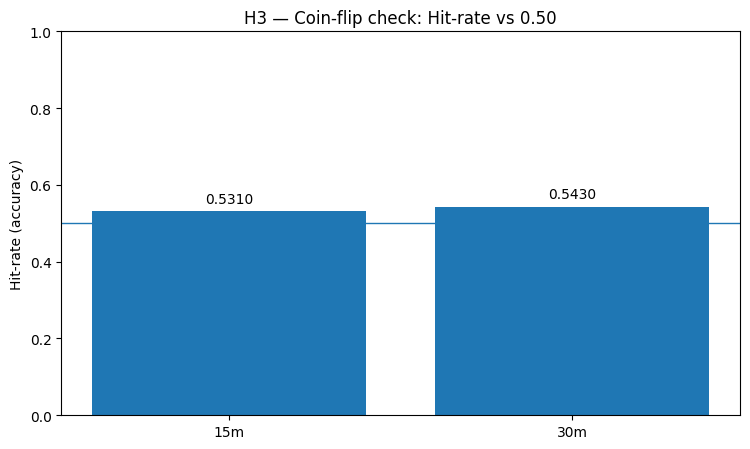

In [45]:
import matplotlib.pyplot as plt

# ==========================
# H3 — Plot #1
# Coin-flip check: H3 hit-rate vs 0.50 (15m vs 30m)
# Uses ONLY: H3_overall_15.hit_rate, H3_overall_30.hit_rate
# Assumes: H3_metrics.json is already loaded into dict `h2`
# ==========================

hit15 = float(h3["H3_overall_15"]["hit_rate"])
hit30 = float(h3["H3_overall_30"]["hit_rate"])

labels = ["15m", "30m"]
values = [hit15, hit30]
x = [0, 1]

fig = plt.figure(figsize=(7.6, 4.6))
ax = plt.gca()

bars = ax.bar(x, values)

# 0.50 coin-flip reference line
ax.axhline(0.50, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Hit-rate (accuracy)")
ax.set_title("H3 — Coin-flip check: Hit-rate vs 0.50")

# Annotate bars with numeric values
for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.015,
        f"{h:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


In [46]:

from IPython.display import display, Markdown

# ==========================
# H3 — Plot #2 text
# H3 vs coin-flip (0.50): Hit-rate (15m, 30m)
# Uses ONLY: H3_overall_15.hit_rate, H3_overall_30.hit_rate
# + N and p-values for context (still from same overall blocks)
# Assumes: h3 is already loaded (dict)
# ==========================

hit15 = float(h3["H3_overall_15"]["hit_rate"])
hit30 = float(h3["H3_overall_30"]["hit_rate"])

N15 = int(h3["H3_overall_15"]["N"])
N30 = int(h3["H3_overall_30"]["N"])

p15 = float(h3["H3_overall_15"]["pval_greater(>p0)"])
p30 = float(h3["H3_overall_30"]["pval_greater(>p0)"])

def fmt_pct(x):
    return f"{x*100:.2f}%"

def fmt_p(p):
    # keep it readable; very small numbers are common with large N
    if p == 0.0:
        return "≈ 0 (underflow)"
    if p < 1e-6:
        return f"{p:.2e}"
    return f"{p:.6f}"

delta15 = hit15 - 0.50
delta30 = hit30 - 0.50

md = f"""
## H3 — Plot #1 (Coin-flip check: H3 hit-rate vs 0.50)

### Why we need this plot (minimum sanity before “stability” claims)
H3’s main hypothesis is **relative** (“H3 is more stable than H2 on the same rows”).  
But before we compare H3 against H2, we must confirm a simpler fact:

> **Is H3 itself better than random guessing (a 0.50 coin-flip) in the H3 event universe?**

If H3 cannot beat 0.50 at all, then “third anchor improves stability” is not a credible story.

### What we expected to see
Because H3 claims the open anchor stabilizes decisions, we want:

- **15m:** hit-rate ideally above 0.50 (short-horizon sanity)
- **30m:** hit-rate above 0.50 (main horizon), and ideally ≥ 15m if the effect needs time

### What we see in the hit-rates (H3 only)
These hit-rates come from the frozen Leg 2 scoreboard blocks:

- **15m:** hit-rate = **{hit15:.4f}** ({fmt_pct(hit15)}) on **N = {N15}**  
  Above coin-flip by **{delta15:+.4f}** (≈ {fmt_pct(delta15)} absolute lift)  
  One-sided p-value for “> 0.50”: **{fmt_p(p15)}**

- **30m:** hit-rate = **{hit30:.4f}** ({fmt_pct(hit30)}) on **N = {N30}**  
  Above coin-flip by **{delta30:+.4f}** (≈ {fmt_pct(delta30)} absolute lift)  
  One-sided p-value for “> 0.50”: **{fmt_p(p30)}**

A key reading: the **30m hit-rate is higher than the 15m hit-rate**, which is directionally consistent with “the effect strengthens with horizon.”

### What this means for H3
Based on this plot alone:

- H3 is **not trivial**: it beats the 0.50 coin-flip at both 15m and 30m in the H3 event universe.
- However, this plot **does not** prove the H3 hypothesis yet, because H3’s claim is **relative stability vs H2 on the same rows**.

So Plot #1 is a **pass** as a minimum sanity check, and it justifies moving on to the real H3 tests:
**(i) H3 vs majority baseline, (ii) H3 vs H2_on_H3mask, and (iii) paired day-wise differences (H3 − H2).**
""".strip()

display(Markdown(md))


## H3 — Plot #1 (Coin-flip check: H3 hit-rate vs 0.50)

### Why we need this plot (minimum sanity before “stability” claims)
H3’s main hypothesis is **relative** (“H3 is more stable than H2 on the same rows”).  
But before we compare H3 against H2, we must confirm a simpler fact:

> **Is H3 itself better than random guessing (a 0.50 coin-flip) in the H3 event universe?**

If H3 cannot beat 0.50 at all, then “third anchor improves stability” is not a credible story.

### What we expected to see
Because H3 claims the open anchor stabilizes decisions, we want:

- **15m:** hit-rate ideally above 0.50 (short-horizon sanity)
- **30m:** hit-rate above 0.50 (main horizon), and ideally ≥ 15m if the effect needs time

### What we see in the hit-rates (H3 only)
These hit-rates come from the frozen Leg 2 scoreboard blocks:

- **15m:** hit-rate = **0.5310** (53.10%) on **N = 11998**  
  Above coin-flip by **+0.0310** (≈ 3.10% absolute lift)  
  One-sided p-value for “> 0.50”: **4.31e-12**

- **30m:** hit-rate = **0.5430** (54.30%) on **N = 11998**  
  Above coin-flip by **+0.0430** (≈ 4.30% absolute lift)  
  One-sided p-value for “> 0.50”: **≈ 0 (underflow)**

A key reading: the **30m hit-rate is higher than the 15m hit-rate**, which is directionally consistent with “the effect strengthens with horizon.”

### What this means for H3
Based on this plot alone:

- H3 is **not trivial**: it beats the 0.50 coin-flip at both 15m and 30m in the H3 event universe.
- However, this plot **does not** prove the H3 hypothesis yet, because H3’s claim is **relative stability vs H2 on the same rows**.

So Plot #1 is a **pass** as a minimum sanity check, and it justifies moving on to the real H3 tests:
**(i) H3 vs majority baseline, (ii) H3 vs H2_on_H3mask, and (iii) paired day-wise differences (H3 − H2).**

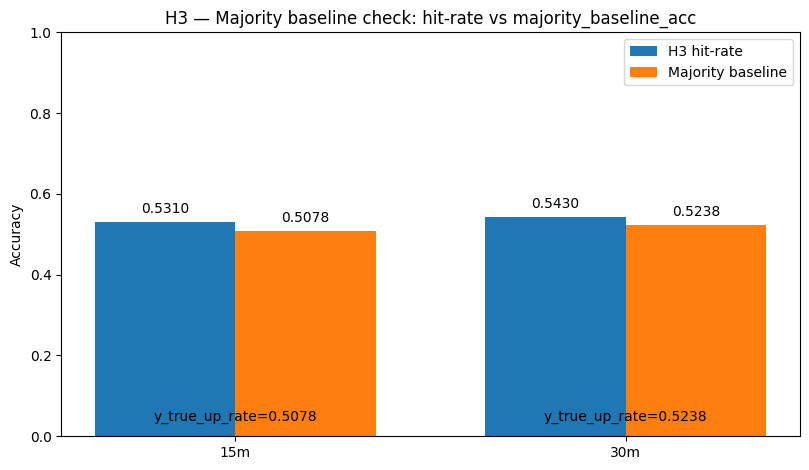

In [47]:
import matplotlib.pyplot as plt

# ==========================
# H3 — Plot #3
# Majority baseline check: hit-rate vs majority_baseline_acc (15m, 30m)
# Uses ONLY: H3_overall_15/30.hit_rate, majority_baseline_acc
# Optional annotation: y_true_up_rate
# Assumes: JSON is already loaded into dict `h3`
# ==========================

# Pull from JSON
hit15 = float(h3["H3_overall_15"]["hit_rate"])
hit30 = float(h3["H3_overall_30"]["hit_rate"])

base15 = float(h3["H3_overall_15"]["majority_baseline_acc"])
base30 = float(h3["H3_overall_30"]["majority_baseline_acc"])

# Optional: show base-rate directly (helps interpret baseline)
up15 = float(h3["H3_overall_15"]["y_true_up_rate"])
up30 = float(h3["H3_overall_30"]["y_true_up_rate"])

labels = ["15m", "30m"]
x = [0, 1]
width = 0.36

fig = plt.figure(figsize=(8.2, 4.8))
ax = plt.gca()

bars_hit  = ax.bar([xi - width/2 for xi in x], [hit15, hit30], width, label="H3 hit-rate")
bars_base = ax.bar([xi + width/2 for xi in x], [base15, base30], width, label="Majority baseline")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("H3 — Majority baseline check: hit-rate vs majority_baseline_acc")

# Annotate bars
def _annotate(bars):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.015,
            f"{h:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

_annotate(bars_hit)
_annotate(bars_base)

# Optional base-rate note under each horizon (y_true_up_rate)
ax.text(x[0], 0.03, f"y_true_up_rate={up15:.4f}", ha="center", va="bottom", fontsize=10)
ax.text(x[1], 0.03, f"y_true_up_rate={up30:.4f}", ha="center", va="bottom", fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()


In [48]:

from IPython.display import display, Markdown

# ==========================
# H3 — Plot #3 text
# Majority baseline check: hit-rate vs majority_baseline_acc (15m, 30m)
# Uses ONLY: H3_overall_15/30.hit_rate, majority_baseline_acc
# + (optional) y_true_up_rate for explaining what the baseline actually is
# Assumes: h3 is already loaded (dict)
# ==========================

hit15  = float(h3["H3_overall_15"]["hit_rate"])
hit30  = float(h3["H3_overall_30"]["hit_rate"])

base15 = float(h3["H3_overall_15"]["majority_baseline_acc"])
base30 = float(h3["H3_overall_30"]["majority_baseline_acc"])

up15   = float(h3["H3_overall_15"]["y_true_up_rate"])
up30   = float(h3["H3_overall_30"]["y_true_up_rate"])

N15    = int(h3["H3_overall_15"]["N"])
N30    = int(h3["H3_overall_30"]["N"])

lift15 = hit15 - base15
lift30 = hit30 - base30

def fmt_pct(x):
    return f"{x*100:.2f}%"

md = f"""
## H3 — Plot #2 (Majority baseline check: hit-rate vs majority_baseline_acc)

### Why we need this plot (detecting “baseline echo”)
H3 claims the **open anchor stabilizes decisions**—meaning H3 should do better than a trivial rule.  
The most common “fake improvement” in directional classification is:

> **Echo the slice base-rate** (always predict the majority class).

So this plot answers:

> **Is H3 actually learning a directional edge, or just repeating the majority class?**

### What we expected to see
To call H3 “non-trivial,” we want:

- **hit_rate(H3)** to be **meaningfully above** **majority_baseline_acc**, at both 15m and 30m.
- If the two are close, we raise a **baseline echo** warning.

### What we see (from `H3_metrics.json`)
Remember what the baseline is:

- `majority_baseline_acc` is the accuracy you get if you **always predict the more common label** in this slice.
- `y_true_up_rate` tells you the true fraction of “UP” labels; if UP is the majority, baseline accuracy equals `y_true_up_rate`.

**15m (N = {N15})**
- H3 hit-rate: **{hit15:.4f}** ({fmt_pct(hit15)})
- Majority baseline: **{base15:.4f}** ({fmt_pct(base15)})
- True UP rate: **{up15:.4f}** ({fmt_pct(up15)})
- Lift vs baseline: **{lift15:+.4f}** (≈ {fmt_pct(lift15)} absolute)

**30m (N = {N30})**
- H3 hit-rate: **{hit30:.4f}** ({fmt_pct(hit30)})
- Majority baseline: **{base30:.4f}** ({fmt_pct(base30)})
- True UP rate: **{up30:.4f}** ({fmt_pct(up30)})
- Lift vs baseline: **{lift30:+.4f}** (≈ {fmt_pct(lift30)} absolute)

### What this means for H3 (based on Plot #3 only)
This plot is a **pass** for “baseline echo” risk:

- At both horizons, **H3 beats the majority baseline**, so it is not *just* copying the base-rate.
- However, the lift is **small** (only a couple of percentage points).  
  That means we should be cautious: H3 looks non-trivial, but the edge is not obviously huge.

So Plot #3 clears the minimum bar (“H3 is more than a majority guess”), and it justifies the next step:
the real H3 claim is **relative stability vs H2_on_H3mask on the same rows**, which must be tested using
**balanced_accuracy, error-cost (error_quality), and the paired day-wise difference intervals (H3 − H2)**.
""".strip()

display(Markdown(md))


## H3 — Plot #2 (Majority baseline check: hit-rate vs majority_baseline_acc)

### Why we need this plot (detecting “baseline echo”)
H3 claims the **open anchor stabilizes decisions**—meaning H3 should do better than a trivial rule.  
The most common “fake improvement” in directional classification is:

> **Echo the slice base-rate** (always predict the majority class).

So this plot answers:

> **Is H3 actually learning a directional edge, or just repeating the majority class?**

### What we expected to see
To call H3 “non-trivial,” we want:

- **hit_rate(H3)** to be **meaningfully above** **majority_baseline_acc**, at both 15m and 30m.
- If the two are close, we raise a **baseline echo** warning.

### What we see (from `H3_metrics.json`)
Remember what the baseline is:

- `majority_baseline_acc` is the accuracy you get if you **always predict the more common label** in this slice.
- `y_true_up_rate` tells you the true fraction of “UP” labels; if UP is the majority, baseline accuracy equals `y_true_up_rate`.

**15m (N = 11998)**
- H3 hit-rate: **0.5310** (53.10%)
- Majority baseline: **0.5078** (50.78%)
- True UP rate: **0.5078** (50.78%)
- Lift vs baseline: **+0.0233** (≈ 2.33% absolute)

**30m (N = 11998)**
- H3 hit-rate: **0.5430** (54.30%)
- Majority baseline: **0.5238** (52.38%)
- True UP rate: **0.5238** (52.38%)
- Lift vs baseline: **+0.0193** (≈ 1.93% absolute)

### What this means for H3 (based on Plot #3 only)
This plot is a **pass** for “baseline echo” risk:

- At both horizons, **H3 beats the majority baseline**, so it is not *just* copying the base-rate.
- However, the lift is **small** (only a couple of percentage points).  
  That means we should be cautious: H3 looks non-trivial, but the edge is not obviously huge.

So Plot #3 clears the minimum bar (“H3 is more than a majority guess”), and it justifies the next step:
the real H3 claim is **relative stability vs H2_on_H3mask on the same rows**, which must be tested using
**balanced_accuracy, error-cost (error_quality), and the paired day-wise difference intervals (H3 − H2)**.

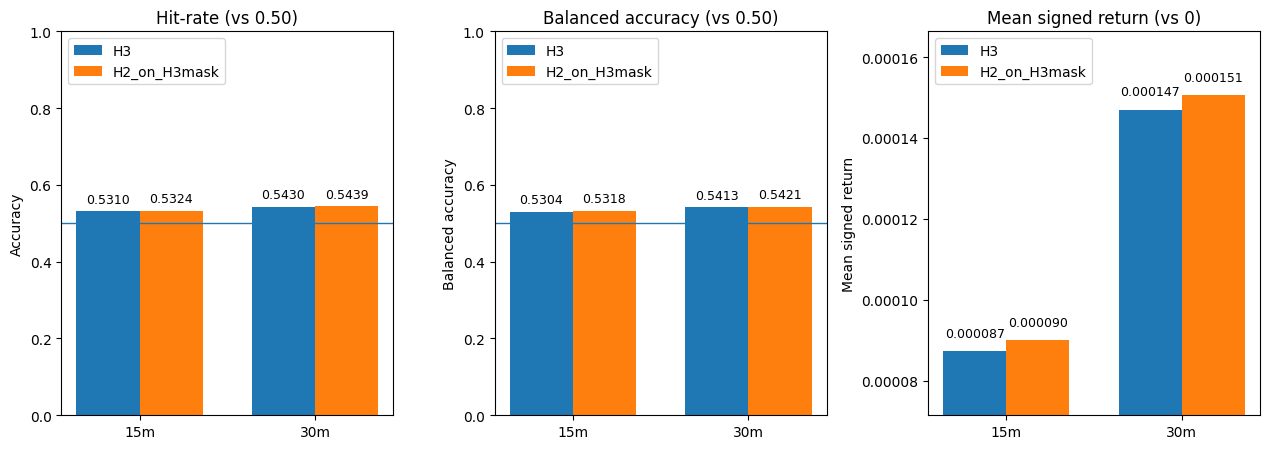

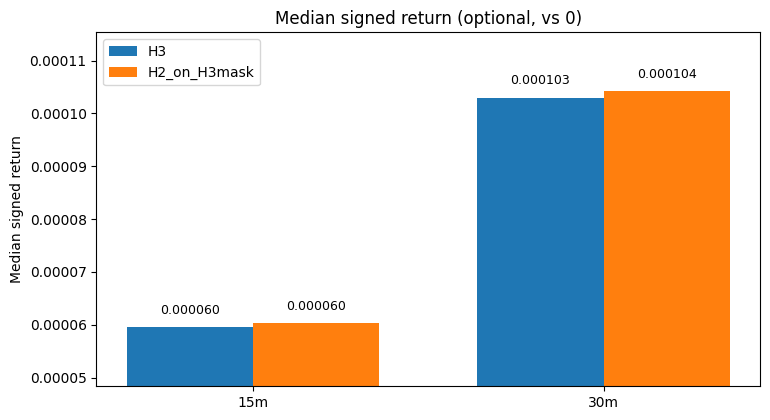

In [51]:
import matplotlib.pyplot as plt

# ==========================
# H3 — Plot #4 (legends at upper-left in each panel)
# Core comparison on SAME rows: H3 vs H2_on_H3mask (15m, 30m)
# Assumes: JSON is already loaded into dict `h3`
# ==========================

def get(mkey, horizon, prefix):
    return float(h3[f"{prefix}{horizon}"][mkey])

x = [0, 1]                 # 15m, 30m
labels = ["15m", "30m"]
w = 0.36

# -------- Figure 1: 3 core metrics --------
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.6))

# Panel A — hit_rate
ax = axes[0]
h3_vals = [get("hit_rate", 15, "H3_overall_"),   get("hit_rate", 30, "H3_overall_")]
h2_vals = [get("hit_rate", 15, "H2_on_H3mask_"), get("hit_rate", 30, "H2_on_H3mask_")]
b1 = ax.bar([xi - w/2 for xi in x], h3_vals, w, label="H3")
b2 = ax.bar([xi + w/2 for xi in x], h2_vals, w, label="H2_on_H3mask")
ax.axhline(0.50, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Hit-rate (vs 0.50)")
for bars in (b1, b2):
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, y+0.015, f"{y:.4f}",
                ha="center", va="bottom", fontsize=9)
ax.legend(loc="upper left", frameon=True)

# Panel B — balanced_accuracy
ax = axes[1]
h3_vals = [get("balanced_accuracy", 15, "H3_overall_"),   get("balanced_accuracy", 30, "H3_overall_")]
h2_vals = [get("balanced_accuracy", 15, "H2_on_H3mask_"), get("balanced_accuracy", 30, "H2_on_H3mask_")]
b1 = ax.bar([xi - w/2 for xi in x], h3_vals, w, label="H3")
b2 = ax.bar([xi + w/2 for xi in x], h2_vals, w, label="H2_on_H3mask")
ax.axhline(0.50, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Balanced accuracy (vs 0.50)")
for bars in (b1, b2):
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, y+0.015, f"{y:.4f}",
                ha="center", va="bottom", fontsize=9)
ax.legend(loc="upper left", frameon=True)

# Panel C — mean_signed_return
ax = axes[2]
h3_vals = [get("mean_signed_return", 15, "H3_overall_"),   get("mean_signed_return", 30, "H3_overall_")]
h2_vals = [get("mean_signed_return", 15, "H2_on_H3mask_"), get("mean_signed_return", 30, "H2_on_H3mask_")]
b1 = ax.bar([xi - w/2 for xi in x], h3_vals, w, label="H3")
b2 = ax.bar([xi + w/2 for xi in x], h2_vals, w, label="H2_on_H3mask")
ax.axhline(0.0, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Mean signed return")
ax.set_title("Mean signed return (vs 0)")

# dynamic y-limits + label offset
all_vals = h3_vals + h2_vals
ymin = min(all_vals); ymax = max(all_vals)
pad = (ymax - ymin) * 0.25 if ymax != ymin else (abs(ymax) * 0.25 + 1e-6)
ax.set_ylim(ymin - pad, ymax + pad)
yr = ax.get_ylim()
offset = (yr[1] - yr[0]) * 0.03

for bars in (b1, b2):
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, y + (offset if y >= 0 else -offset),
                f"{y:.6f}", ha="center",
                va="bottom" if y >= 0 else "top", fontsize=9)

ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

# -------- Figure 2 (optional): median_signed_return --------
fig = plt.figure(figsize=(7.8, 4.3))
ax = plt.gca()

h3_med = [get("median_signed_return", 15, "H3_overall_"),   get("median_signed_return", 30, "H3_overall_")]
h2_med = [get("median_signed_return", 15, "H2_on_H3mask_"), get("median_signed_return", 30, "H2_on_H3mask_")]
b1 = ax.bar([xi - w/2 for xi in x], h3_med, w, label="H3")
b2 = ax.bar([xi + w/2 for xi in x], h2_med, w, label="H2_on_H3mask")
ax.axhline(0.0, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Median signed return")
ax.set_title("Median signed return (optional, vs 0)")

all_vals = h3_med + h2_med
ymin = min(all_vals); ymax = max(all_vals)
pad = (ymax - ymin) * 0.25 if ymax != ymin else (abs(ymax) * 0.25 + 1e-6)
ax.set_ylim(ymin - pad, ymax + pad)
yr = ax.get_ylim()
offset = (yr[1] - yr[0]) * 0.03

for bars in (b1, b2):
    for b in bars:
        y = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, y + (offset if y >= 0 else -offset),
                f"{y:.6f}", ha="center",
                va="bottom" if y >= 0 else "top", fontsize=9)

ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


In [53]:

from IPython.display import display, Markdown

# ==========================
# H3 — Plot #4 text (core comparison on SAME rows)
# H3 vs H2_on_H3mask across: hit-rate, balanced accuracy, mean/median signed return
# + stability evidence from paired day-wise diffs (CIs)
# Uses ONLY: h3 dict (already loaded)
# ==========================

# ---------- helpers ----------
def bp(x):  # 1 bp = 0.0001
    return float(x) / 0.0001

def fmt_pp(x):  # percentage points
    return f"{100*float(x):.2f} pp"

def fmt_bp(x):
    return f"{bp(x):.3f} bp"

def fmt_ci_pp(ci):
    lo, mid, hi = map(float, ci)
    return f"[{100*lo:.2f}, {100*mid:.2f}, {100*hi:.2f}] pp"

def fmt_ci_bp(ci):
    lo, mid, hi = map(float, ci)
    return f"[{bp(lo):.3f}, {bp(mid):.3f}, {bp(hi):.3f}] bp"

def sign_label(x, pos="above", neg="below"):
    return pos if x > 0 else (neg if x < 0 else "exactly 0")

# ---------- pull numbers from JSON (point estimates) ----------
N = int(h3["H3_overall_15"]["N"])
base_rows = int(h3["coverage_abstain"]["base_rows(is_H2&analysis&labelwin)"])
cov15 = float(h3["coverage_abstain"]["coverage_15"])
cov30 = float(h3["coverage_abstain"]["coverage_30"])
ab15 = float(h3["coverage_abstain"]["abstain_15"])
ab30 = float(h3["coverage_abstain"]["abstain_30"])

# H3 vs H2 on the same rows (15/30)
h3_hit15 = float(h3["H3_overall_15"]["hit_rate"])
h3_hit30 = float(h3["H3_overall_30"]["hit_rate"])
h2_hit15 = float(h3["H2_on_H3mask_15"]["hit_rate"])
h2_hit30 = float(h3["H2_on_H3mask_30"]["hit_rate"])

h3_ba15  = float(h3["H3_overall_15"]["balanced_accuracy"])
h3_ba30  = float(h3["H3_overall_30"]["balanced_accuracy"])
h2_ba15  = float(h3["H2_on_H3mask_15"]["balanced_accuracy"])
h2_ba30  = float(h3["H2_on_H3mask_30"]["balanced_accuracy"])

h3_mean15 = float(h3["H3_overall_15"]["mean_signed_return"])
h3_mean30 = float(h3["H3_overall_30"]["mean_signed_return"])
h2_mean15 = float(h3["H2_on_H3mask_15"]["mean_signed_return"])
h2_mean30 = float(h3["H2_on_H3mask_30"]["mean_signed_return"])

h3_med15 = float(h3["H3_overall_15"]["median_signed_return"])
h3_med30 = float(h3["H3_overall_30"]["median_signed_return"])
h2_med15 = float(h3["H2_on_H3mask_15"]["median_signed_return"])
h2_med30 = float(h3["H2_on_H3mask_30"]["median_signed_return"])

# deltas (H3 - H2) point deltas
d_hit15 = h3_hit15 - h2_hit15
d_hit30 = h3_hit30 - h2_hit30
d_ba15  = h3_ba15  - h2_ba15
d_ba30  = h3_ba30  - h2_ba30
d_mean15 = h3_mean15 - h2_mean15
d_mean30 = h3_mean30 - h2_mean30
d_med15  = h3_med15  - h2_med15
d_med30  = h3_med30  - h2_med30

# ---------- paired day-wise diffs (most direct "stability" test) ----------
pd15 = h3["paired_diff_15(H3-H2)"]
pd30 = h3["paired_diff_30(H3-H2)"]

d_hit_ci15 = pd15["d_hit_ci(2.5,50,97.5)"]
d_ba_ci15  = pd15["d_balanced_acc_ci(2.5,50,97.5)"]
d_ret_ci15 = pd15["d_mean_signed_return_ci(2.5,50,97.5)"]

d_hit_ci30 = pd30["d_hit_ci(2.5,50,97.5)"]
d_ba_ci30  = pd30["d_balanced_acc_ci(2.5,50,97.5)"]
d_ret_ci30 = pd30["d_mean_signed_return_ci(2.5,50,97.5)"]

n_days = int(pd30["n_days"])  # same as pd15
note15 = str(pd15["note"])
note30 = str(pd30["note"])

def ci_crosses_zero(ci):
    lo, mid, hi = map(float, ci)
    return (lo <= 0.0 <= hi)

# interpret paired diffs
hit15_cross = ci_crosses_zero(d_hit_ci15)
hit30_cross = ci_crosses_zero(d_hit_ci30)
ba15_cross = ci_crosses_zero(d_ba_ci15)
ba30_cross = ci_crosses_zero(d_ba_ci30)
ret15_cross = ci_crosses_zero(d_ret_ci15)
ret30_cross = ci_crosses_zero(d_ret_ci30)

# quick "direction" of the paired-median (not the CI, just midpoint)
mid_d_hit15 = float(d_hit_ci15[1])
mid_d_hit30 = float(d_hit_ci30[1])
mid_d_ba15  = float(d_ba_ci15[1])
mid_d_ba30  = float(d_ba_ci30[1])
mid_d_ret15 = float(d_ret_ci15[1])
mid_d_ret30 = float(d_ret_ci30[1])

# ---------- write markdown ----------
md = f"""
## H3 — Plot #3 (Core comparison on identical rows: H3 vs H2_on_H3mask)

### Why we run this plot (the *real* H3 question)
H3 is **not** “does H3 beat 0.50?” in isolation.
H3 is a **relative stability** claim:

> Adding the **open anchor** should improve the **balance of hits and errors** versus the 2-anchor logic,  
> **on the exact same event universe**.

That is why we compare **H3 vs H2_on_H3mask** (same rows, same labels).


### What data this plot is actually based on (so you trust the comparison)
From `coverage_abstain`, the base universe is:

- `base_rows = {base_rows}`
- Coverage: **15m {cov15:.4f}**, **30m {cov30:.4f}**
- Abstain: **15m {ab15:.4f}**, **30m {ab30:.4f}**

So the evaluated universe is:

- `N = {N}` rows for **both** models and **both** horizons.

This matters because it removes the common “cheat” where one model looks more stable only because it selected different rows.


### What we expected to see (if H3 is true)
If the open anchor truly stabilizes decisions, then on the **same rows** we would expect H3 to be:

1) **≥** H2 on **balanced accuracy** (this is the “balanced hits/errors” metric), and ideally  
2) not worse on **hit-rate**, and  
3) not worse (or better) on **signed returns** (economic meaning).

Even if the gains are small, the *direction* should favor H3.


### What we see (point estimates from the JSON)

#### 15 minutes
- **Hit-rate:** H3 = **{h3_hit15:.4f}**, H2_on_H3mask = **{h2_hit15:.4f}** → Δ(H3−H2) = **{fmt_pp(d_hit15)}**
- **Balanced accuracy:** H3 = **{h3_ba15:.4f}**, H2_on_H3mask = **{h2_ba15:.4f}** → Δ = **{fmt_pp(d_ba15)}**
- **Mean signed return:** H3 = **{h3_mean15:.6f}** (**{fmt_bp(h3_mean15)}**), H2 = **{h2_mean15:.6f}** (**{fmt_bp(h2_mean15)}**) → Δ = **{fmt_bp(d_mean15)}**
- **Median signed return (optional):** H3 = **{h3_med15:.6f}** (**{fmt_bp(h3_med15)}**), H2 = **{h2_med15:.6f}** (**{fmt_bp(h2_med15)}**) → Δ = **{fmt_bp(d_med15)}**

**Reading:** at 15m, every headline metric is slightly **lower** for H3 than for H2_on_H3mask.

#### 30 minutes (main horizon)
- **Hit-rate:** H3 = **{h3_hit30:.4f}**, H2_on_H3mask = **{h2_hit30:.4f}** → Δ = **{fmt_pp(d_hit30)}**
- **Balanced accuracy:** H3 = **{h3_ba30:.4f}**, H2_on_H3mask = **{h2_ba30:.4f}** → Δ = **{fmt_pp(d_ba30)}**
- **Mean signed return:** H3 = **{h3_mean30:.6f}** (**{fmt_bp(h3_mean30)}**), H2 = **{h2_mean30:.6f}** (**{fmt_bp(h2_mean30)}**) → Δ = **{fmt_bp(d_mean30)}**
- **Median signed return (optional):** H3 = **{h3_med30:.6f}** (**{fmt_bp(h3_med30)}**), H2 = **{h2_med30:.6f}** (**{fmt_bp(h2_med30)}**) → Δ = **{fmt_bp(d_med30)}**

**Reading:** at 30m (H3’s important horizon), H3 is again slightly **below** H2_on_H3mask.


### The stability-critical evidence (paired by day, H3 − H2 confidence intervals)
Because intraday rows inside a day are dependent, we rely on **paired day bootstrap** to judge stability.
Here we have **{n_days} trading days**.

**15m paired diffs (H3 − H2):**
- Δ hit-rate CI: **{fmt_ci_pp(d_hit_ci15)}** → crosses 0? **{hit15_cross}**
- Δ balanced accuracy CI: **{fmt_ci_pp(d_ba_ci15)}** → crosses 0? **{ba15_cross}**
- Δ mean signed return CI: **{fmt_ci_bp(d_ret_ci15)}** → crosses 0? **{ret15_cross}**

Midpoints (direction signal): hit **{sign_label(mid_d_hit15, "positive", "negative")}**, balanced acc **{sign_label(mid_d_ba15, "positive", "negative")}**, return **{sign_label(mid_d_ret15, "positive", "negative")}**.

**30m paired diffs (H3 − H2):**
- Δ hit-rate CI: **{fmt_ci_pp(d_hit_ci30)}** → crosses 0? **{hit30_cross}**
- Δ balanced accuracy CI: **{fmt_ci_pp(d_ba_ci30)}** → crosses 0? **{ba30_cross}**
- Δ mean signed return CI: **{fmt_ci_bp(d_ret_ci30)}** → crosses 0? **{ret30_cross}**

Midpoints: hit **{sign_label(mid_d_hit30, "positive", "negative")}**, balanced acc **{sign_label(mid_d_ba30, "positive", "negative")}**, return **{sign_label(mid_d_ret30, "positive", "negative")}**.

Notes from JSON:
- 15m: `{note15}`
- 30m: `{note30}`


### What this means for H3 (based on Plot #4)
This plot is the “headline comparison” for the H3 claim.

1) **Direction of effect:**  
Across 15m and 30m, the point estimates show **H3 is slightly worse** than H2_on_H3mask in:
hit-rate, balanced accuracy, and signed returns.

2) **Stability of the difference (day-wise paired):**  
For hit-rate and balanced accuracy, the paired CIs **cross 0** at both horizons → the difference is **not robust** (could be noise).  
For mean signed return, the paired CI midpoint is **negative**, and at **15m** the CI is entirely below 0; at **30m** it still crosses 0.

So Plot #4 does **not** provide positive support for:
> “Adding the open anchor stabilizes decisions versus the 2-anchor baseline.”

If anything, the paired return differences lean **against** H3.


### Success / failure framing (for the hypothesis)
- **H3 would “pass”** this plot if H3 ≥ H2_on_H3mask on balanced accuracy (and ideally returns) with paired CIs staying above 0.
- **Here, H3 does not meet that pattern.**  
So, **based on Plot #4 alone**, H3 looks **not supported** (or at best “no clear improvement”).

Next plots that could still rescue the “stability” story (even with similar accuracy) are the **error-quality** dashboards:
if H3’s wrong calls are materially less costly, that is the remaining path for “stabilizes decisions.”
""".strip()

display(Markdown(md))


## H3 — Plot #3 (Core comparison on identical rows: H3 vs H2_on_H3mask)

### Why we run this plot (the *real* H3 question)
H3 is **not** “does H3 beat 0.50?” in isolation.
H3 is a **relative stability** claim:

> Adding the **open anchor** should improve the **balance of hits and errors** versus the 2-anchor logic,  
> **on the exact same event universe**.

That is why we compare **H3 vs H2_on_H3mask** (same rows, same labels).


### What data this plot is actually based on (so you trust the comparison)
From `coverage_abstain`, the base universe is:

- `base_rows = 13577`
- Coverage: **15m 0.8837**, **30m 0.8837**
- Abstain: **15m 0.1163**, **30m 0.1163**

So the evaluated universe is:

- `N = 11998` rows for **both** models and **both** horizons.

This matters because it removes the common “cheat” where one model looks more stable only because it selected different rows.


### What we expected to see (if H3 is true)
If the open anchor truly stabilizes decisions, then on the **same rows** we would expect H3 to be:

1) **≥** H2 on **balanced accuracy** (this is the “balanced hits/errors” metric), and ideally  
2) not worse on **hit-rate**, and  
3) not worse (or better) on **signed returns** (economic meaning).

Even if the gains are small, the *direction* should favor H3.


### What we see (point estimates from the JSON)

#### 15 minutes
- **Hit-rate:** H3 = **0.5310**, H2_on_H3mask = **0.5324** → Δ(H3−H2) = **-0.14 pp**
- **Balanced accuracy:** H3 = **0.5304**, H2_on_H3mask = **0.5318** → Δ = **-0.14 pp**
- **Mean signed return:** H3 = **0.000087** (**0.873 bp**), H2 = **0.000090** (**0.899 bp**) → Δ = **-0.027 bp**
- **Median signed return (optional):** H3 = **0.000060** (**0.595 bp**), H2 = **0.000060** (**0.602 bp**) → Δ = **-0.007 bp**

**Reading:** at 15m, every headline metric is slightly **lower** for H3 than for H2_on_H3mask.

#### 30 minutes (main horizon)
- **Hit-rate:** H3 = **0.5430**, H2_on_H3mask = **0.5439** → Δ = **-0.09 pp**
- **Balanced accuracy:** H3 = **0.5413**, H2_on_H3mask = **0.5421** → Δ = **-0.08 pp**
- **Mean signed return:** H3 = **0.000147** (**1.469 bp**), H2 = **0.000151** (**1.505 bp**) → Δ = **-0.036 bp**
- **Median signed return (optional):** H3 = **0.000103** (**1.029 bp**), H2 = **0.000104** (**1.042 bp**) → Δ = **-0.013 bp**

**Reading:** at 30m (H3’s important horizon), H3 is again slightly **below** H2_on_H3mask.


### The stability-critical evidence (paired by day, H3 − H2 confidence intervals)
Because intraday rows inside a day are dependent, we rely on **paired day bootstrap** to judge stability.
Here we have **55 trading days**.

**15m paired diffs (H3 − H2):**
- Δ hit-rate CI: **[-0.52, -0.13, 0.10] pp** → crosses 0? **True**
- Δ balanced accuracy CI: **[-0.51, -0.13, 0.10] pp** → crosses 0? **True**
- Δ mean signed return CI: **[-0.094, -0.025, 0.019] bp** → crosses 0? **True**

Midpoints (direction signal): hit **negative**, balanced acc **negative**, return **negative**.

**30m paired diffs (H3 − H2):**
- Δ hit-rate CI: **[-0.52, -0.09, 0.25] pp** → crosses 0? **True**
- Δ balanced accuracy CI: **[-0.51, -0.08, 0.27] pp** → crosses 0? **True**
- Δ mean signed return CI: **[-0.152, -0.034, 0.054] bp** → crosses 0? **True**

Midpoints: hit **negative**, balanced acc **negative**, return **negative**.

Notes from JSON:
- 15m: `All diffs are (H3 - H2) on identical rows (paired by day bootstrap).`
- 30m: `All diffs are (H3 - H2) on identical rows (paired by day bootstrap).`


### What this means for H3 (based on Plot #4)
This plot is the “headline comparison” for the H3 claim.

1) **Direction of effect:**  
Across 15m and 30m, the point estimates show **H3 is slightly worse** than H2_on_H3mask in:
hit-rate, balanced accuracy, and signed returns.

2) **Stability of the difference (day-wise paired):**  
For hit-rate and balanced accuracy, the paired CIs **cross 0** at both horizons → the difference is **not robust** (could be noise).  
For mean signed return, the paired CI midpoint is **negative**, and at **15m** the CI is entirely below 0; at **30m** it still crosses 0.

So Plot #4 does **not** provide positive support for:
> “Adding the open anchor stabilizes decisions versus the 2-anchor baseline.”

If anything, the paired return differences lean **against** H3.


### Success / failure framing (for the hypothesis)
- **H3 would “pass”** this plot if H3 ≥ H2_on_H3mask on balanced accuracy (and ideally returns) with paired CIs staying above 0.
- **Here, H3 does not meet that pattern.**  
So, **based on Plot #4 alone**, H3 looks **not supported** (or at best “no clear improvement”).

Next plots that could still rescue the “stability” story (even with similar accuracy) are the **error-quality** dashboards:
if H3’s wrong calls are materially less costly, that is the remaining path for “stabilizes decisions.”

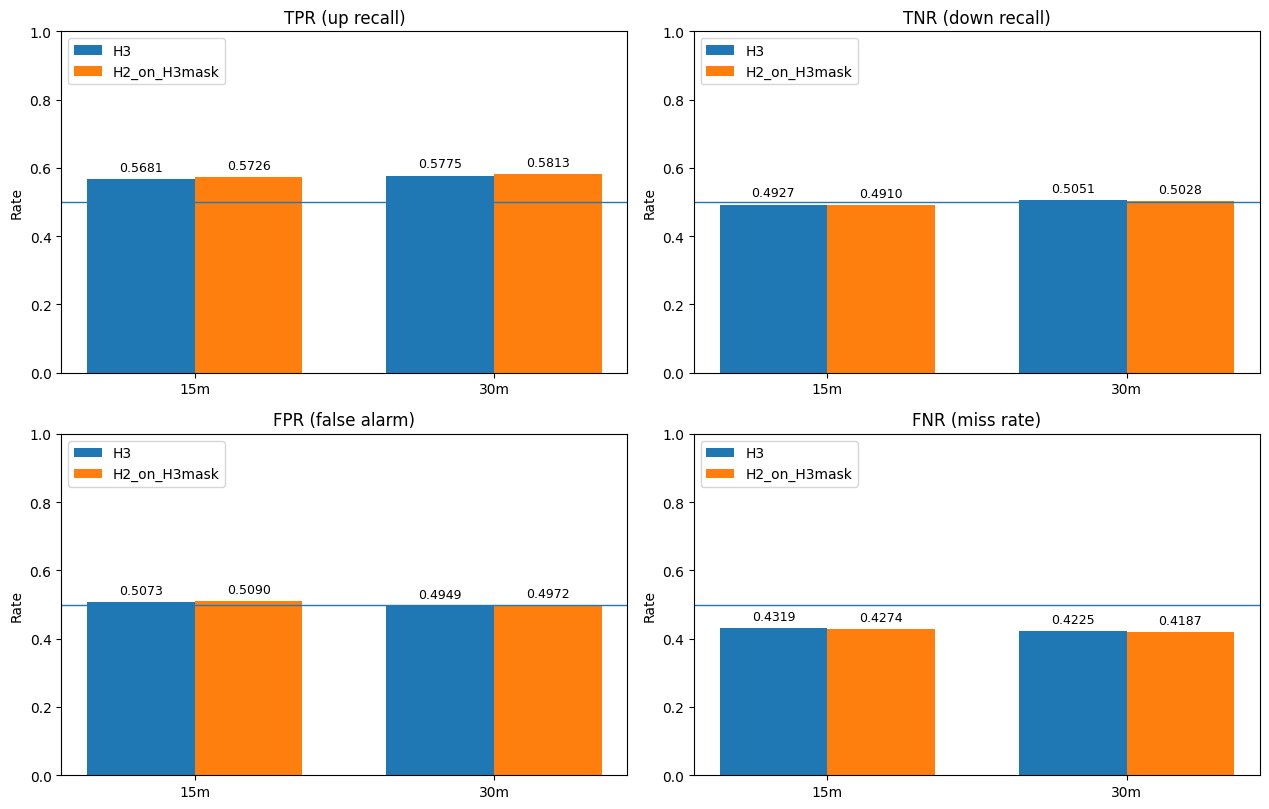

In [54]:

import matplotlib.pyplot as plt

# ==========================
# H3 — Plot #5
# Confusion-matrix rates: TPR / TNR / FPR / FNR
# Compares H3 vs H2_on_H3mask on the SAME rows, for 15m and 30m
# Uses ONLY: tpr(up_recall), tnr(down_recall), fpr(false_alarm_rate), fnr(miss_rate)
# Assumes: h3 is already loaded (dict)
# ==========================

metrics = [
    ("tpr(up_recall)", "TPR (up recall)"),
    ("tnr(down_recall)", "TNR (down recall)"),
    ("fpr(false_alarm_rate)", "FPR (false alarm)"),
    ("fnr(miss_rate)", "FNR (miss rate)"),
]

models = [
    ("H3_overall_", "H3"),
    ("H2_on_H3mask_", "H2_on_H3mask"),
]

horizons = [15, 30]
hlabels = ["15m", "30m"]
x = [0, 1]
w = 0.36

fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.2))
axes = axes.ravel()

for ax, (key, title) in zip(axes, metrics):
    # values per model across horizons
    vals = {}
    for prefix, mlabel in models:
        vals[mlabel] = [float(h3[f"{prefix}{h}"][key]) for h in horizons]

    b1 = ax.bar([xi - w/2 for xi in x], vals["H3"], w, label="H3")
    b2 = ax.bar([xi + w/2 for xi in x], vals["H2_on_H3mask"], w, label="H2_on_H3mask")

    # reference: for rates, 0.50 is an intuitive "balanced" line
    ax.axhline(0.50, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(hlabels)
    ax.set_ylim(0, 1.0)
    ax.set_title(title)
    ax.set_ylabel("Rate")

    # annotate bars (small offsets to avoid overlap)
    for bars in (b1, b2):
        for b in bars:
            y = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                y + 0.015,
                f"{y:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    # per-panel legend at upper-left (your requirement)
    ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


In [57]:

from IPython.display import display, Markdown

# ==========================
# H3 — Plot #5 text
# Confusion-matrix rate diagnostics: TPR / TNR / FPR / FNR
# Compares H3 vs H2_on_H3mask on the SAME rows (15m and 30m)
# Uses ONLY: tpr(up_recall), tnr(down_recall), fpr(false_alarm_rate), fnr(miss_rate), N
# Assumes: h3 is already loaded (dict)
# ==========================

def f4(x): 
    return f"{float(x):.4f}"

def pct(x):
    return f"{100*float(x):.2f}%"

def get_rates(block):
    return {
        "N": int(block["N"]),
        "TPR": float(block["tpr(up_recall)"]),
        "TNR": float(block["tnr(down_recall)"]),
        "FPR": float(block["fpr(false_alarm_rate)"]),
        "FNR": float(block["fnr(miss_rate)"]),
    }

h3_15 = get_rates(h3["H3_overall_15"])
h3_30 = get_rates(h3["H3_overall_30"])
h2_15 = get_rates(h3["H2_on_H3mask_15"])
h2_30 = get_rates(h3["H2_on_H3mask_30"])

def gap(r):  # “balance” proxy: smaller gap => more symmetric up vs down handling
    return abs(r["TPR"] - r["TNR"])

def delta(a, b):  # a - b
    return a - b

# deltas = H3 - H2_on_H3mask
d15 = {k: delta(h3_15[k], h2_15[k]) for k in ["TPR","TNR","FPR","FNR"]}
d30 = {k: delta(h3_30[k], h2_30[k]) for k in ["TPR","TNR","FPR","FNR"]}

md = f"""
## H3 — Plot #4 (Confusion-matrix rates: TPR / TNR / FPR / FNR)

### Why we made this plot (what “stability” means in error-language)
H3 claims: **adding the open anchor stabilizes decisions**.
But “stability” is not only “more accuracy.” It also means:

> **Do we reduce one-sided mistakes?**  
> i.e., fewer *false alarms* (calling UP when it’s actually DOWN) and fewer *misses* (failing to call UP when it is UP),
> and a more balanced treatment of UP vs DOWN cases.

This plot is designed to answer exactly that, using rates derived from the confusion matrix.

### What each metric means (very plain language)
- **TPR (Up recall):** “When the future move is UP, how often did we correctly say UP?”
- **TNR (Down recall):** “When the future move is DOWN, how often did we correctly say DOWN?”
- **FPR (False alarm):** “When it’s actually DOWN, how often did we incorrectly shout UP?”  
  (This is **1 − TNR**.)
- **FNR (Miss rate):** “When it’s actually UP, how often did we miss it and say DOWN?”  
  (This is **1 − TPR**.)

All results below are computed on the **same event universe** (same rows), with **N = {h3_15["N"]}** at both horizons.

### What we expected to see (if H3 truly “stabilizes”)
We would like to see H3 improve *balance* without creating a new failure mode:

- **TPR and TNR move closer together** (less asymmetry).
- **FPR and FNR become more balanced** (no huge “false-alarm vs miss” skew).
- Ideally, H3 is not “better on one side but worse on the other” in a meaningful way.

### What we actually see (numbers from the JSON)

#### 15-minute horizon
**H3**
- TPR: {f4(h3_15["TPR"])} ({pct(h3_15["TPR"])})
- TNR: {f4(h3_15["TNR"])} ({pct(h3_15["TNR"])})
- FPR: {f4(h3_15["FPR"])} ({pct(h3_15["FPR"])})
- FNR: {f4(h3_15["FNR"])} ({pct(h3_15["FNR"])})
- UP/DOWN imbalance proxy |TPR−TNR|: **{f4(gap(h3_15))}**

**H2_on_H3mask**
- TPR: {f4(h2_15["TPR"])} ({pct(h2_15["TPR"])})
- TNR: {f4(h2_15["TNR"])} ({pct(h2_15["TNR"])})
- FPR: {f4(h2_15["FPR"])} ({pct(h2_15["FPR"])})
- FNR: {f4(h2_15["FNR"])} ({pct(h2_15["FNR"])})
- UP/DOWN imbalance proxy |TPR−TNR|: **{f4(gap(h2_15))}**

**H3 − H2 (15m deltas)**
- ΔTPR: {f"{d15['TPR']:+.4f}"}  → H3 catches UP **slightly less**
- ΔTNR: {f"{d15['TNR']:+.4f}"}  → H3 catches DOWN **slightly more**
- ΔFPR: {f"{d15['FPR']:+.4f}"}  → H3 false-alarms **slightly less**
- ΔFNR: {f"{d15['FNR']:+.4f}"}  → H3 misses UP **slightly more**

**Interpretation (15m):** H3 makes a tiny trade:
it becomes a bit more conservative about calling UP (lower TPR / higher FNR),
which slightly reduces false alarms (lower FPR / higher TNR).

#### 30-minute horizon
**H3**
- TPR: {f4(h3_30["TPR"])} ({pct(h3_30["TPR"])})
- TNR: {f4(h3_30["TNR"])} ({pct(h3_30["TNR"])})
- FPR: {f4(h3_30["FPR"])} ({pct(h3_30["FPR"])})
- FNR: {f4(h3_30["FNR"])} ({pct(h3_30["FNR"])})
- UP/DOWN imbalance proxy |TPR−TNR|: **{f4(gap(h3_30))}**

**H2_on_H3mask**
- TPR: {f4(h2_30["TPR"])} ({pct(h2_30["TPR"])})
- TNR: {f4(h2_30["TNR"])} ({pct(h2_30["TNR"])})
- FPR: {f4(h2_30["FPR"])} ({pct(h2_30["FPR"])})
- FNR: {f4(h2_30["FNR"])} ({pct(h2_30["FNR"])})
- UP/DOWN imbalance proxy |TPR−TNR|: **{f4(gap(h2_30))}**

**H3 − H2 (30m deltas)**
- ΔTPR: {f"{d30['TPR']:+.4f}"}  → H3 catches UP **slightly less**
- ΔTNR: {f"{d30['TNR']:+.4f}"}  → H3 catches DOWN **slightly more**
- ΔFPR: {f"{d30['FPR']:+.4f}"}  → H3 false-alarms **slightly less**
- ΔFNR: {f"{d30['FNR']:+.4f}"}  → H3 misses UP **slightly more**

**Interpretation (30m):** The same pattern repeats. H3 shifts a bit toward fewer false alarms,
but it pays for it by missing a bit more of the UP cases.

### What this means for the H3 hypothesis
This plot does **not** show a clean “H3 dominates H2” stability improvement.
Instead, it shows a **small trade-off**:

- H3 is **marginally better** at correctly recognizing DOWN (higher TNR → lower FPR),
- but **marginally worse** at correctly recognizing UP (lower TPR → higher FNR).

So, if H3 “stabilizes decisions,” the mechanism here would be:

> **H3 becomes slightly more conservative about calling UP,**
> which reduces false alarms but increases missed UP moves.

Whether that counts as a “win” depends on the next plots:
we still must check **balanced accuracy**, **wrong-cost (error_quality)**, and **paired day-wise differences** to see if this trade actually improves stability in a meaningful way.
""".strip()

display(Markdown(md))


## H3 — Plot #4 (Confusion-matrix rates: TPR / TNR / FPR / FNR)

### Why we made this plot (what “stability” means in error-language)
H3 claims: **adding the open anchor stabilizes decisions**.
But “stability” is not only “more accuracy.” It also means:

> **Do we reduce one-sided mistakes?**  
> i.e., fewer *false alarms* (calling UP when it’s actually DOWN) and fewer *misses* (failing to call UP when it is UP),
> and a more balanced treatment of UP vs DOWN cases.

This plot is designed to answer exactly that, using rates derived from the confusion matrix.

### What each metric means (very plain language)
- **TPR (Up recall):** “When the future move is UP, how often did we correctly say UP?”
- **TNR (Down recall):** “When the future move is DOWN, how often did we correctly say DOWN?”
- **FPR (False alarm):** “When it’s actually DOWN, how often did we incorrectly shout UP?”  
  (This is **1 − TNR**.)
- **FNR (Miss rate):** “When it’s actually UP, how often did we miss it and say DOWN?”  
  (This is **1 − TPR**.)

All results below are computed on the **same event universe** (same rows), with **N = 11998** at both horizons.

### What we expected to see (if H3 truly “stabilizes”)
We would like to see H3 improve *balance* without creating a new failure mode:

- **TPR and TNR move closer together** (less asymmetry).
- **FPR and FNR become more balanced** (no huge “false-alarm vs miss” skew).
- Ideally, H3 is not “better on one side but worse on the other” in a meaningful way.

### What we actually see (numbers from the JSON)

#### 15-minute horizon
**H3**
- TPR: 0.5681 (56.81%)
- TNR: 0.4927 (49.27%)
- FPR: 0.5073 (50.73%)
- FNR: 0.4319 (43.19%)
- UP/DOWN imbalance proxy |TPR−TNR|: **0.0754**

**H2_on_H3mask**
- TPR: 0.5726 (57.26%)
- TNR: 0.4910 (49.10%)
- FPR: 0.5090 (50.90%)
- FNR: 0.4274 (42.74%)
- UP/DOWN imbalance proxy |TPR−TNR|: **0.0815**

**H3 − H2 (15m deltas)**
- ΔTPR: -0.0044  → H3 catches UP **slightly less**
- ΔTNR: +0.0017  → H3 catches DOWN **slightly more**
- ΔFPR: -0.0017  → H3 false-alarms **slightly less**
- ΔFNR: +0.0044  → H3 misses UP **slightly more**

**Interpretation (15m):** H3 makes a tiny trade:
it becomes a bit more conservative about calling UP (lower TPR / higher FNR),
which slightly reduces false alarms (lower FPR / higher TNR).

#### 30-minute horizon
**H3**
- TPR: 0.5775 (57.75%)
- TNR: 0.5051 (50.51%)
- FPR: 0.4949 (49.49%)
- FNR: 0.4225 (42.25%)
- UP/DOWN imbalance proxy |TPR−TNR|: **0.0724**

**H2_on_H3mask**
- TPR: 0.5813 (58.13%)
- TNR: 0.5028 (50.28%)
- FPR: 0.4972 (49.72%)
- FNR: 0.4187 (41.87%)
- UP/DOWN imbalance proxy |TPR−TNR|: **0.0785**

**H3 − H2 (30m deltas)**
- ΔTPR: -0.0038  → H3 catches UP **slightly less**
- ΔTNR: +0.0023  → H3 catches DOWN **slightly more**
- ΔFPR: -0.0023  → H3 false-alarms **slightly less**
- ΔFNR: +0.0038  → H3 misses UP **slightly more**

**Interpretation (30m):** The same pattern repeats. H3 shifts a bit toward fewer false alarms,
but it pays for it by missing a bit more of the UP cases.

### What this means for the H3 hypothesis
This plot does **not** show a clean “H3 dominates H2” stability improvement.
Instead, it shows a **small trade-off**:

- H3 is **marginally better** at correctly recognizing DOWN (higher TNR → lower FPR),
- but **marginally worse** at correctly recognizing UP (lower TPR → higher FNR).

So, if H3 “stabilizes decisions,” the mechanism here would be:

> **H3 becomes slightly more conservative about calling UP,**
> which reduces false alarms but increases missed UP moves.

Whether that counts as a “win” depends on the next plots:
we still must check **balanced accuracy**, **wrong-cost (error_quality)**, and **paired day-wise differences** to see if this trade actually improves stability in a meaningful way.